In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from itertools import product # Import product for grid search

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score
)

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py import ScPredModel
from scpred_py import _analysis_utils


print("--- Setting up environment for reproducibility ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8))

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'
RAW_DATA_DIR = '../data/raw' # For Paul15 raw data

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR}, {PREPROCESSED_DATA_DIR}, and {RAW_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(RAW_DATA_DIR, exist_ok=True)
print("Directories ensured.")


scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility ---
Ensuring directories exist: ../models, ../data/preprocessed, and ../data/raw
Directories ensured.


In [2]:
# --- 1. Data Loading and Annotation (Paul15) ---
print("\n--- Step 1: Loading and Annotating Paul15 Data ---")

try:
    adata = sc.read_h5ad(os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad'))
    print(f"Loaded Paul15 data from: {os.path.join(RAW_DATA_DIR, 'paul15_data.h5ad')}")
except FileNotFoundError:
    print(f"Warning: 'paul15_data.h5ad' not found in {RAW_DATA_DIR}. Attempting to load from Scanpy datasets if available.")
    try:
        adata = sc.datasets.paul15()
        print("Loaded Paul15 data using sc.datasets.paul15().")
    except Exception as e:
        raise RuntimeError(f"Could not load Paul15 data. Please ensure 'paul15_data.h5ad' is in {RAW_DATA_DIR} or adjust the loading path. Error: {e}")

adata.var_names_make_unique()

if 'paul15_clusters' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
    print("Assigned 'paul15_clusters' to 'cell_type' column.")
elif 'cell_type' in adata.obs.keys():
    adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
    print("Using existing 'cell_type' column.")
else:
    print("Warning: 'paul15_clusters' or 'cell_type' not found. Generating temporary labels via Louvain clustering...")
    temp_adata_for_labels = adata.copy()
    sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
    sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
    sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
    sc.pp.log1p(temp_adata_for_labels)
    sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
    temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
    sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
    sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE)
    sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE)
    sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type')
    adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category')
    print("Generated temporary cell type labels.")

print(f"Full dataset (raw counts + Paul15 clusters) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())
print("Data loading and labeling complete.")



--- Step 1: Loading and Annotating Paul15 Data ---
Loaded Paul15 data using sc.datasets.paul15().
Assigned 'paul15_clusters' to 'cell_type' column.
Full dataset (raw counts + Paul15 clusters) shape: (2730, 3451)
Full dataset .obs keys after labeling: ['paul15_clusters', 'cell_type']
Cell type distribution (all data):
 cell_type
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64
Data loading and labeling complete.


In [3]:
# --- 2. Train-Test Split ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()
print("Data splitting complete.")

# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())



--- Step 2: Splitting Data ---
Data splitting complete.

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
1Ery       0.015699
2Ery       0.120356
3Ery       0.090005
4Ery       0.045526
5Ery       0.065934
6Ery       0.063318
7MEP       0.061224
8Mk        0.025118
9GMP       0.023025
10GMP      0.055992
11DC       0.010989
12Baso     0.025118
13Baso     0.109890
14Mo       0.136578
15Mo       0.068027
16Neu      0.060178
17Neu      0.008373
18Eos      0.003140
19Lymph    0.011512
Name: proportion, dtype: float64
Query data class imbalance (proportion):
 cell_type
1Ery       0.015873
2Ery       0.120879
3Ery       0.090354
4Ery       0.045177
5Ery       0.065934
6Ery       0.063492
7MEP       0.061050
8Mk        0.024420
9GMP       0.023199
10GMP      0.056166
11DC       0.010989
12Baso     0.025641
13Baso     0.109890
14Mo       0.136752
15Mo       0.068376
16Neu      0.059829
17Neu      0.007326
18Eos      0.003663
19Lymph    0.010989
Name: pr

In [4]:
# --- 3. Define the Experiment Runner Function (UPDATED) ---
def run_scpred_experiment(experiment_name, ref_data, query_data, 
                          n_components, hvg_n_top_genes, hvg_flavor, # Added n_components and hvg_flavor
                          svm_params, prediction_threshold=0.0):
    """
    A helper function to run a single scPred experiment with given parameters.
    Includes prediction threshold and passes probabilities for ROC AUC.
    """
    print("\n" + "="*50)
    print(f"  RUNNING EXPERIMENT: {experiment_name}")
    print("="*50)
    
    # --- Train Model ---
    model = ScPredModel()
    model.train(
        ref_adata=ref_data,
        cell_type_key='cell_type',
        n_components=n_components, # Now variable, consistent with Notebook 02
        hvg_n_top_genes=hvg_n_top_genes, # Now variable, consistent with Notebook 02
        hvg_flavor=hvg_flavor, # Now variable, consistent with Notebook 02
        **svm_params             # Pass all SVM parameters including class_weight
    )
    
    # --- Predict ---
    query_pred = model.predict(query_data, threshold=prediction_threshold)
    
    # --- Evaluate ---
    true_labels = query_pred.obs['cell_type']
    predicted_labels = query_pred.obs['scpred_prediction']
    
    # Calculate overall accuracy (including 'unassigned' as a potential prediction)
    overall_accuracy_score = accuracy_score(true_labels, predicted_labels)
    print(f"Overall Accuracy (including 'unassigned'): {overall_accuracy_score:.4f}")

    # Extract prediction probabilities for ROC AUC
    prob_cols = [col for col in query_pred.obs.columns if col.startswith('scpred_prob_')]
    y_pred_probs_df = None
    if prob_cols:
        y_pred_probs_df = query_pred.obs[prob_cols].copy()

    print(f"\n--- Results for: {experiment_name} ---")
    
    metrics = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=model.classifier_.classes_,
        y_pred_probs=y_pred_probs_df
    )
    
    # --- Visualize Confusion Matrix ---
    true_labels_str = true_labels.astype(str)
    predicted_labels_str = predicted_labels.astype(str)

    cm_labels_str = sorted(list(set(true_labels_str.unique()) | set(predicted_labels_str.unique())))
    cm = confusion_matrix(true_labels_str, predicted_labels_str, labels=cm_labels_str)
    cm_df = pd.DataFrame(cm, index=cm_labels_str, columns=cm_labels_str)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
    plt.title(f'Confusion Matrix: {experiment_name} (Paul15)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return {
        "Experiment": experiment_name,
        "n_components": n_components, # Added to result dict
        "hvg_n_top_genes": hvg_n_top_genes, # Added to result dict
        "hvg_flavor": hvg_flavor, # Added to result dict
        "svm_kernel": svm_params.get('svm_kernel'),
        "svm_c": svm_params.get('svm_c'),
        "svm_class_weight": svm_params.get('svm_class_weight'),
        "Overall Accuracy": overall_accuracy_score,
        "Balanced Accuracy": metrics.get('balanced_accuracy', np.nan),
        "MCC": metrics.get('mcc', np.nan),
        "ROC AUC Scores": metrics.get('roc_auc_scores', {})
    }




--- Step 4: Running Comparative Analyses on paul15 (Minimal Grid) ---

Starting Exp 1: PC=30, HVG=2000, Kernel=linear, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 1: PC=30, HVG=2000, Kernel=linear, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. P

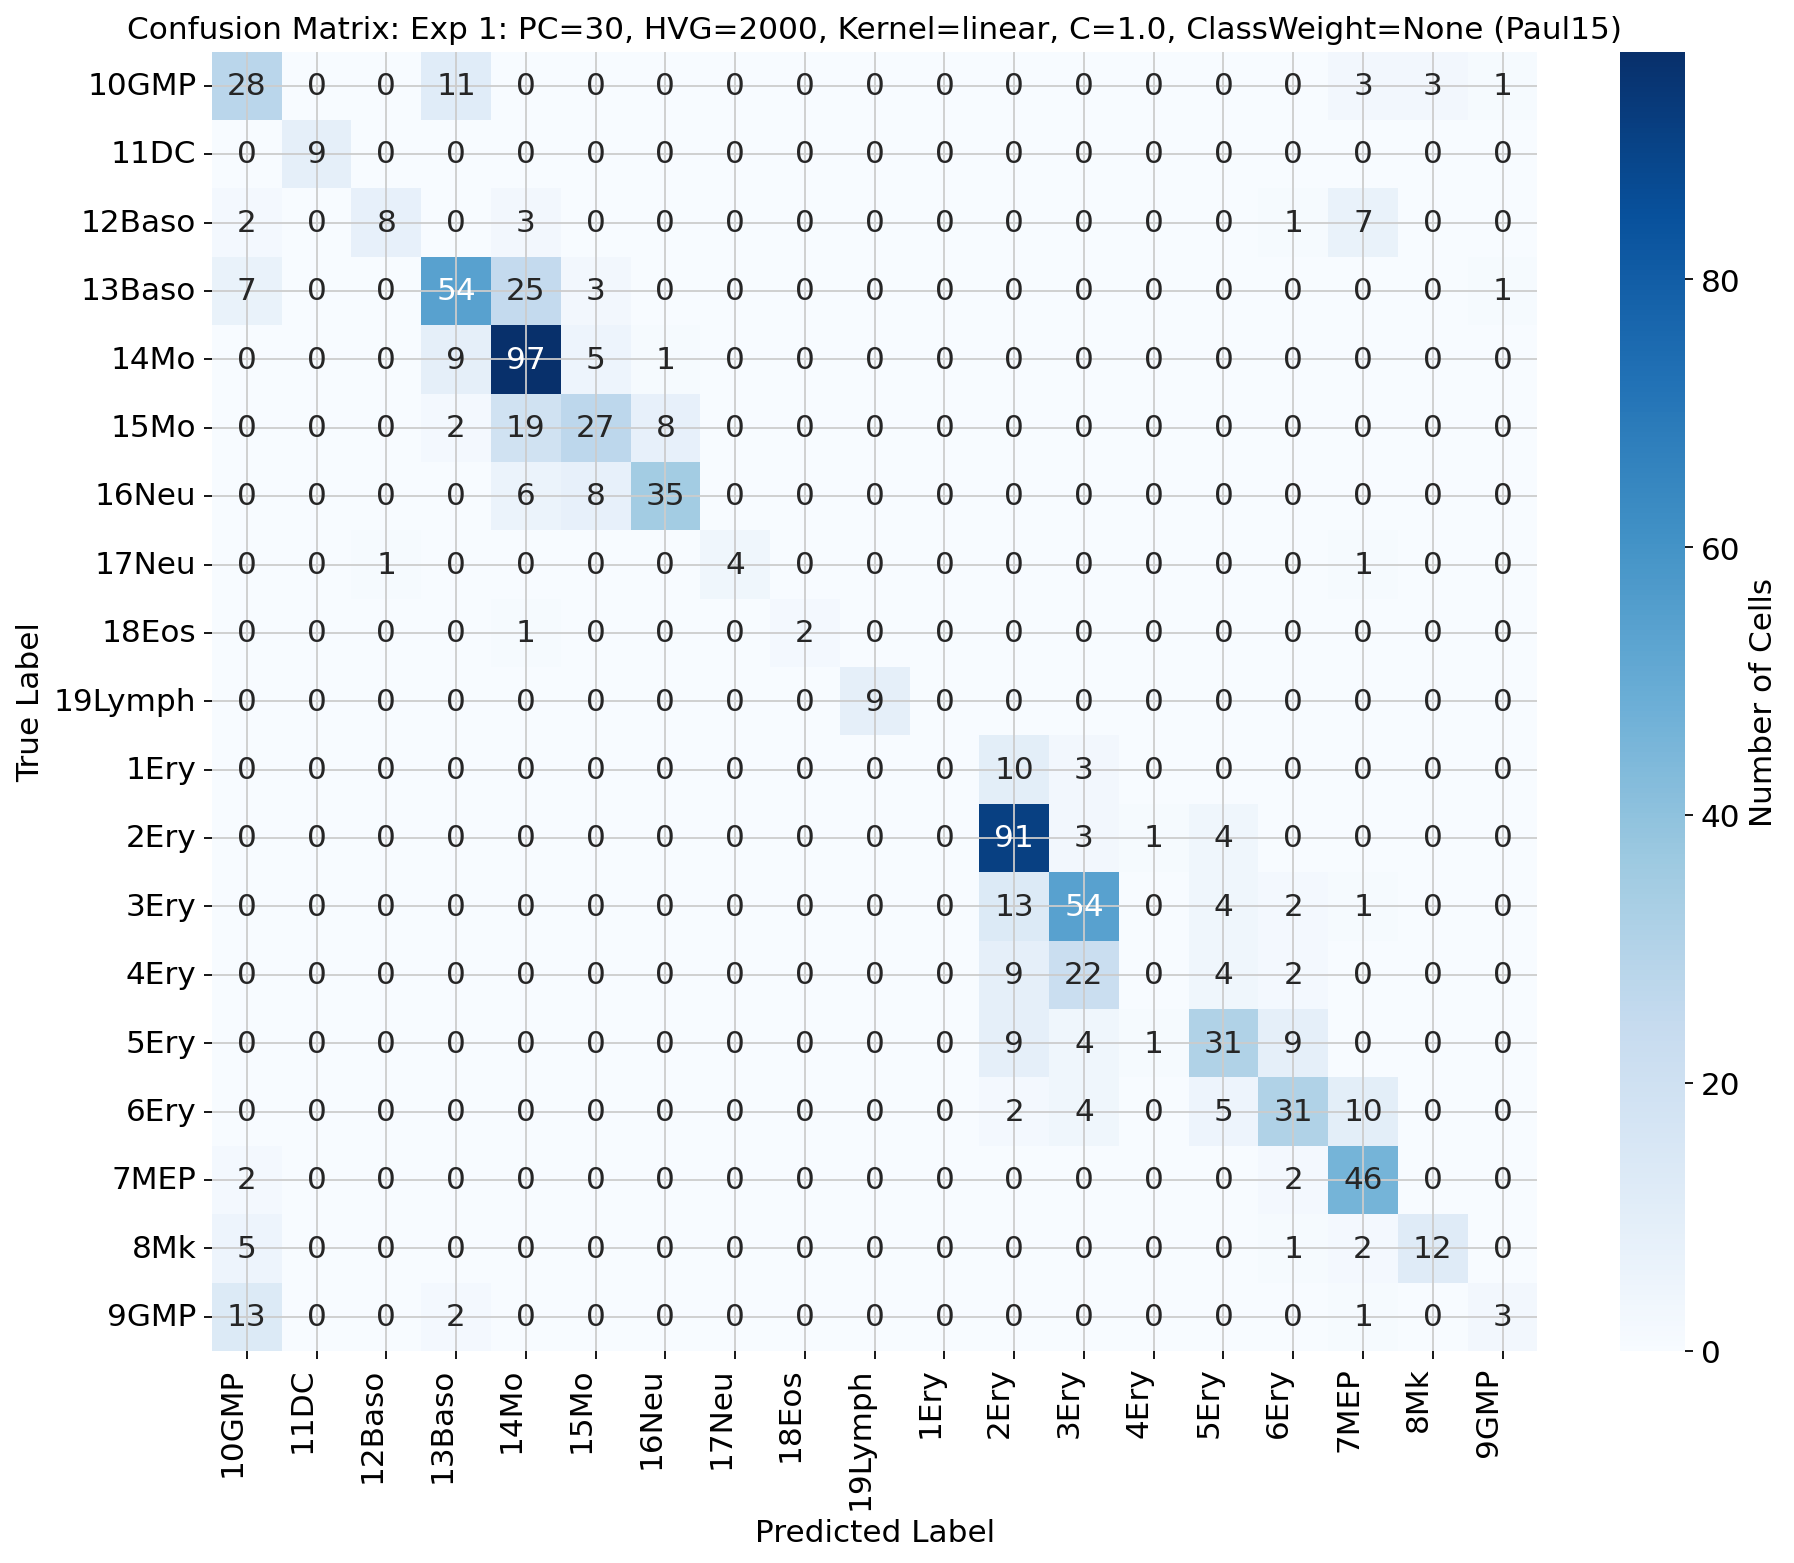


Starting Exp 2: PC=30, HVG=2000, Kernel=linear, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 2: PC=30, HVG=2000, Kernel=linear, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Apply

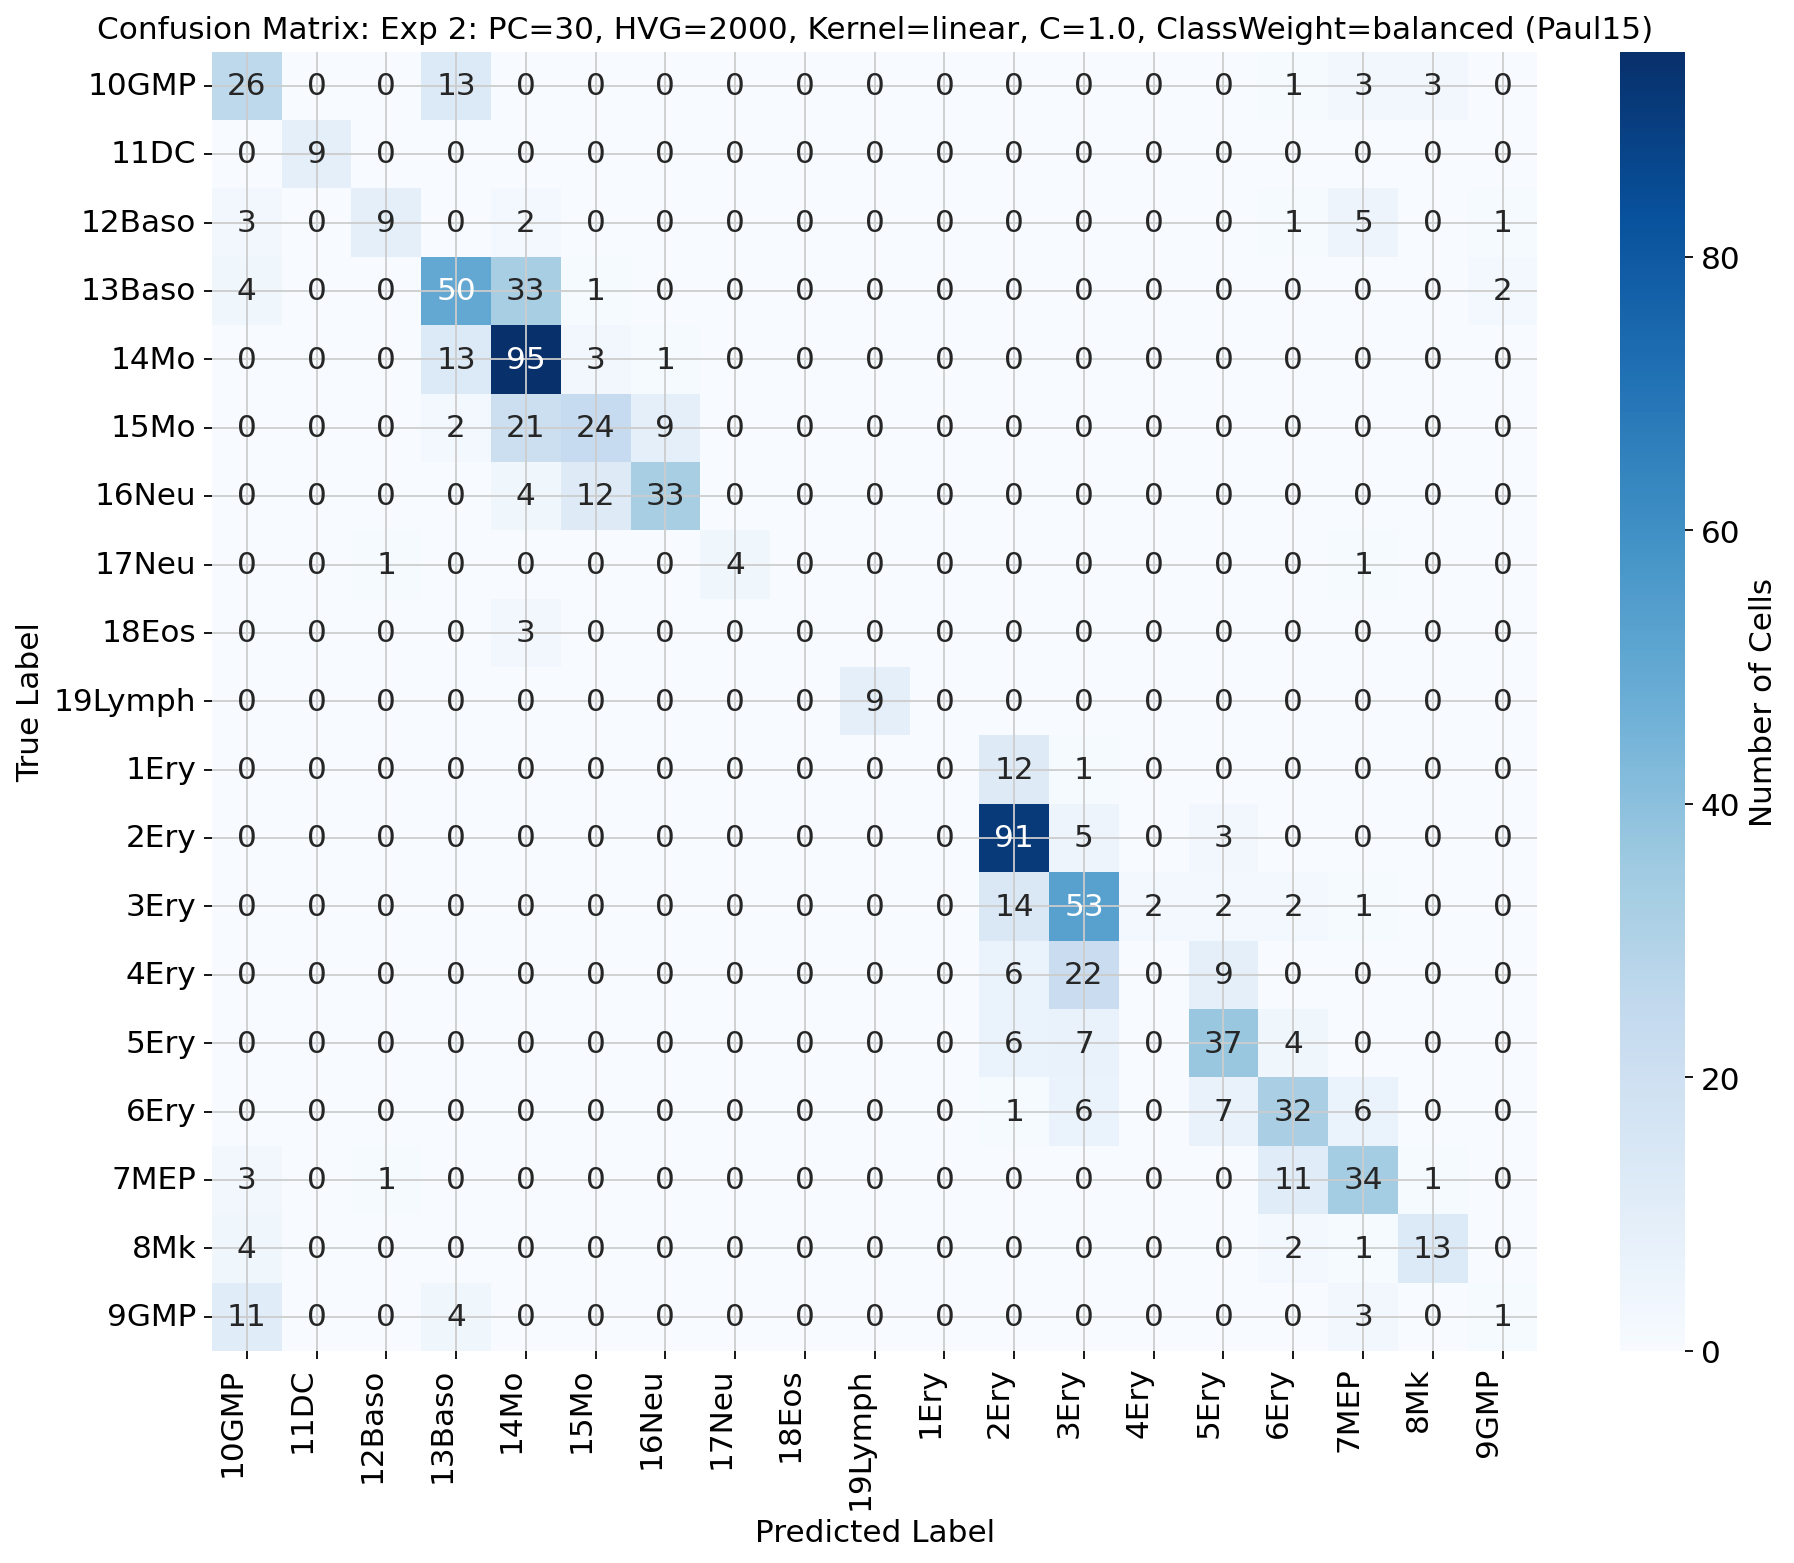


Starting Exp 3: PC=30, HVG=2000, Kernel=linear, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 3: PC=30, HVG=2000, Kernel=linear, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initi

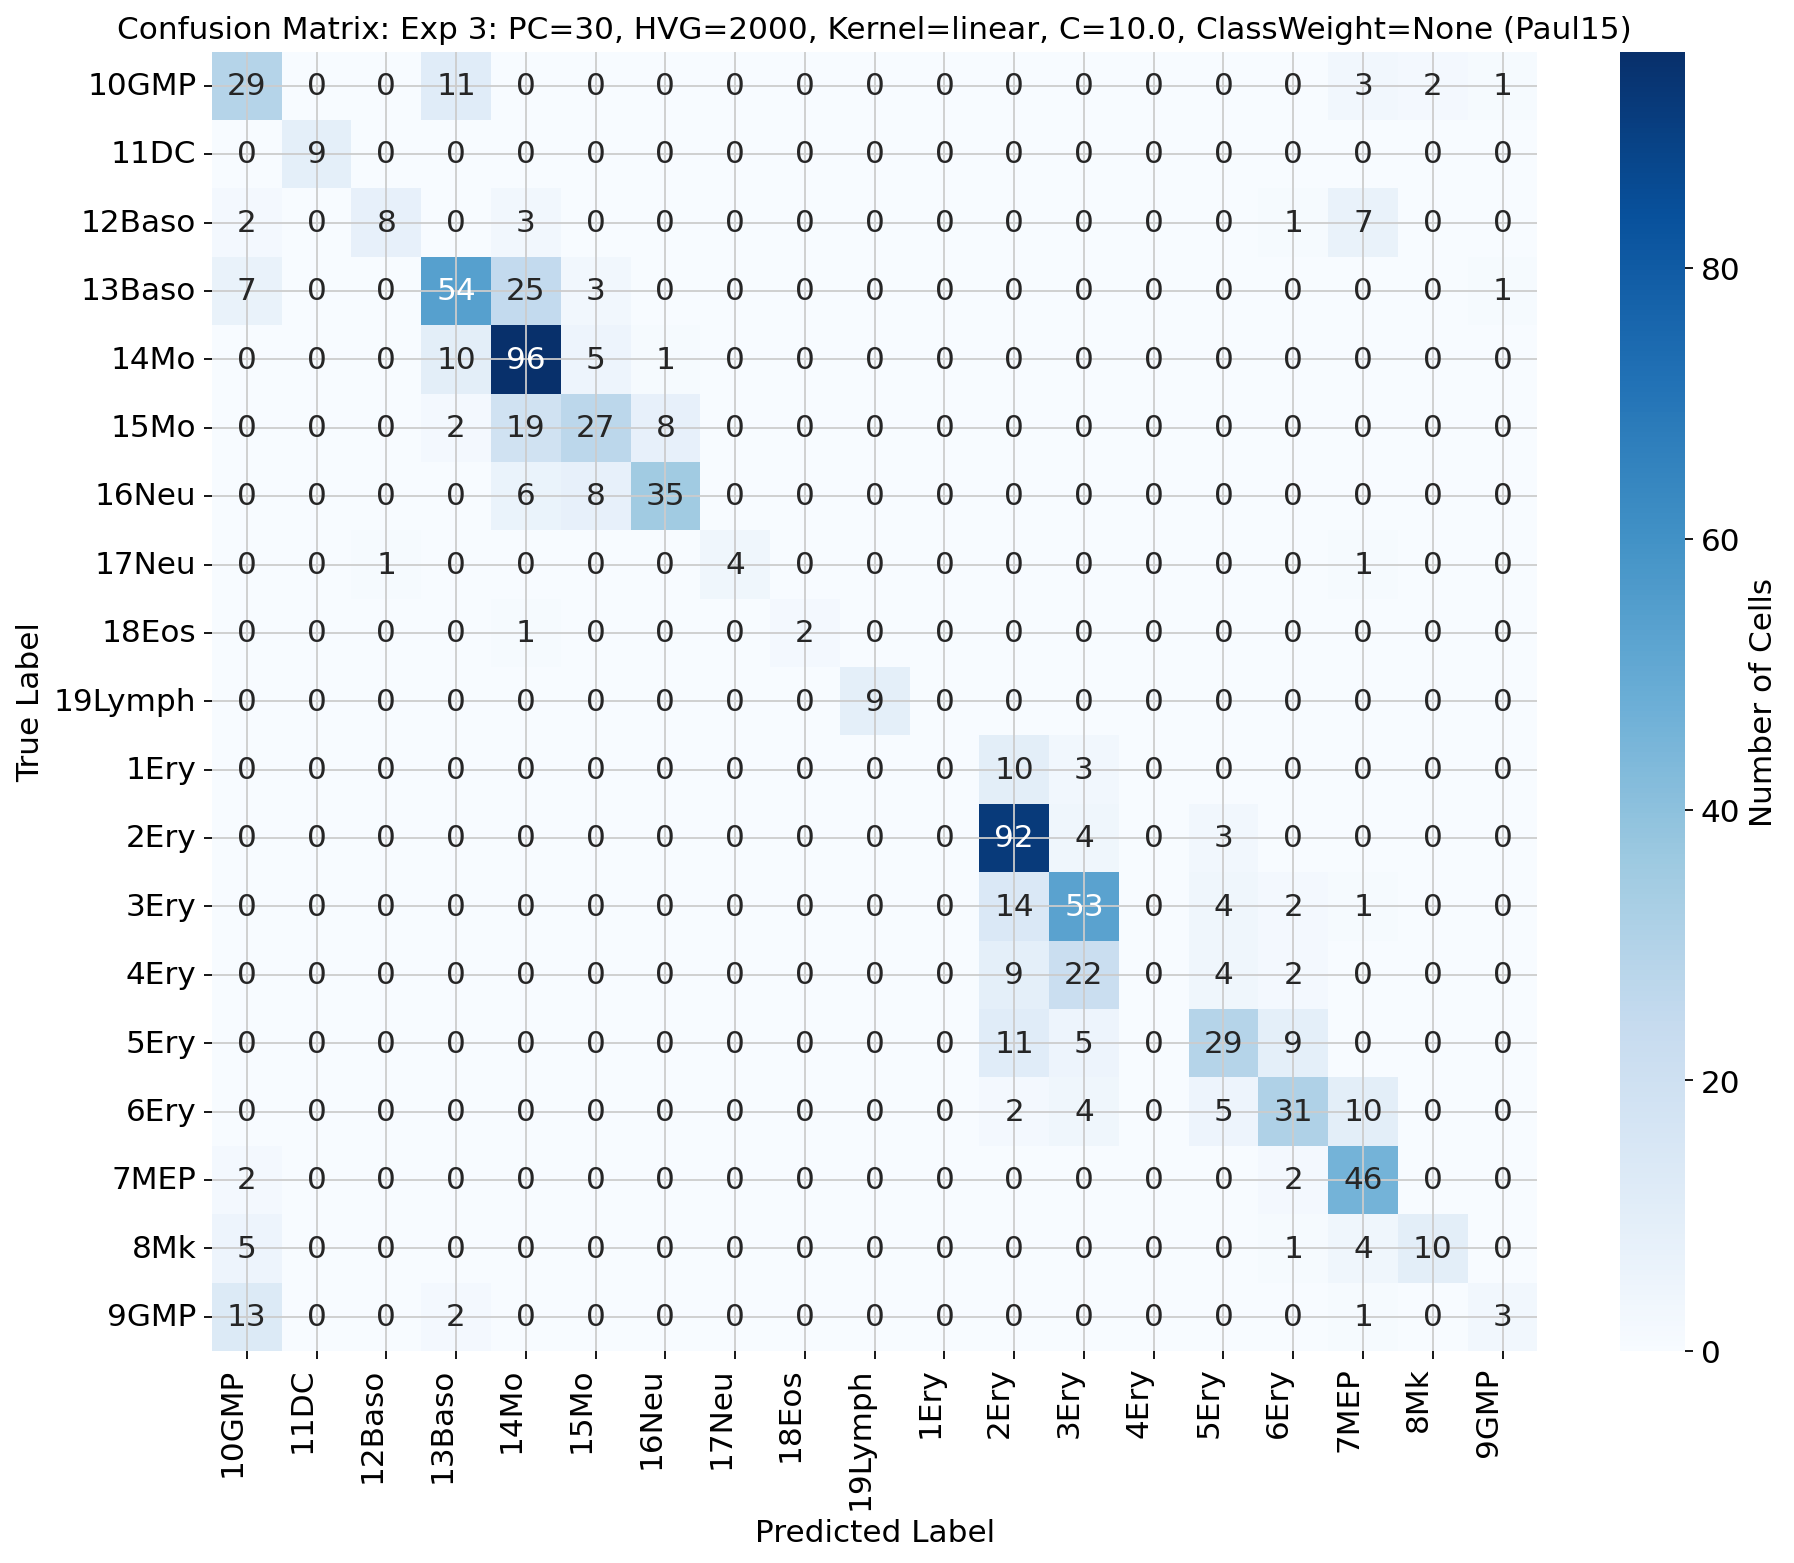


Starting Exp 4: PC=30, HVG=2000, Kernel=linear, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 4: PC=30, HVG=2000, Kernel=linear, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Ap

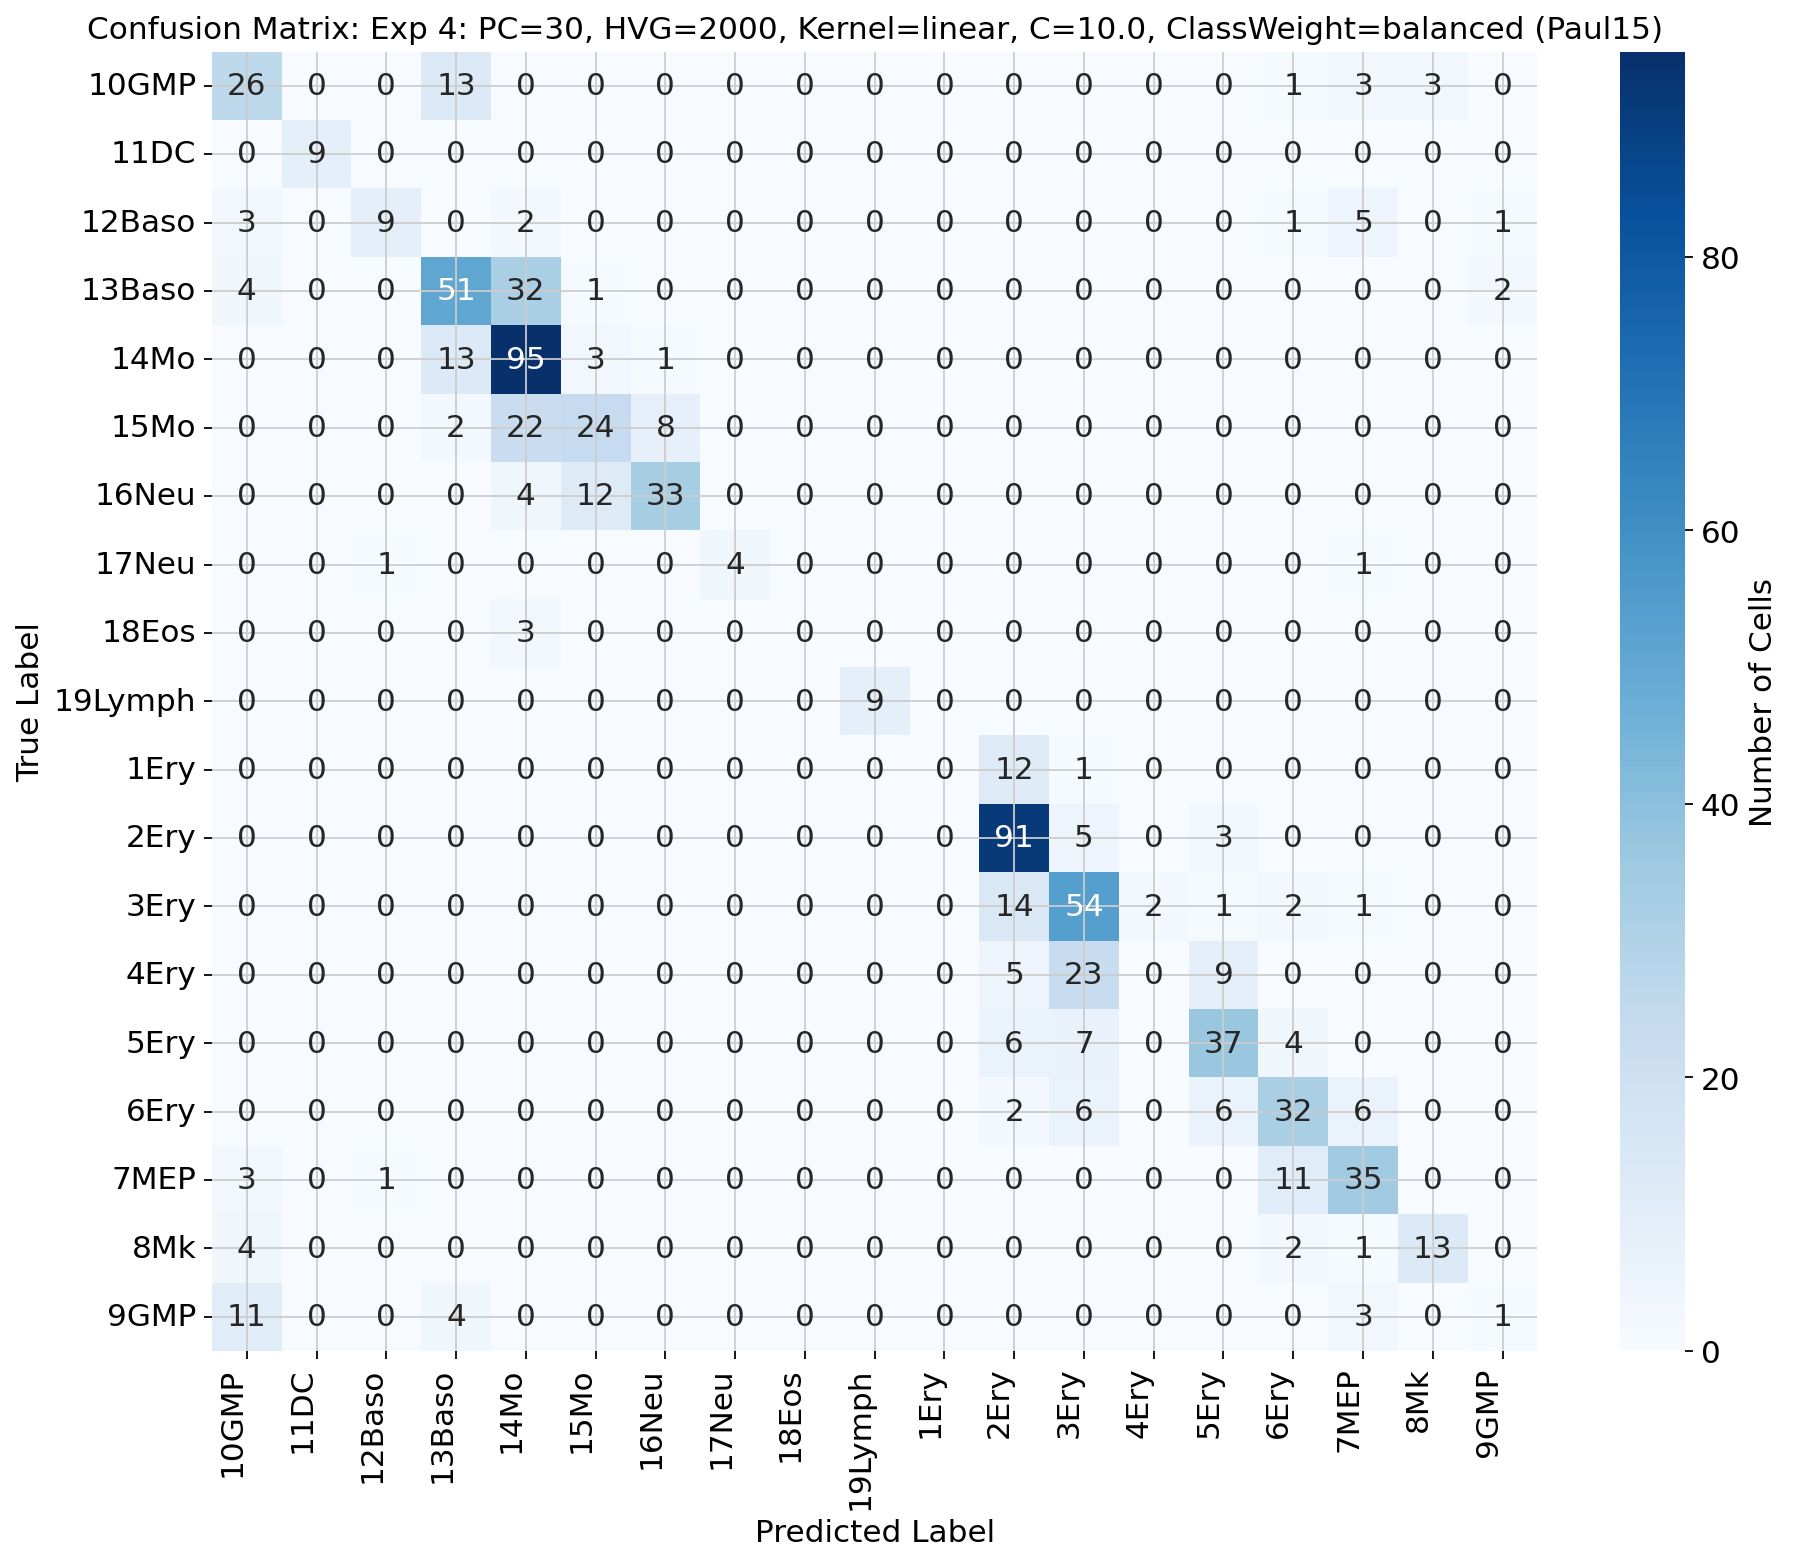


Starting Exp 5: PC=30, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 5: PC=30, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preproces

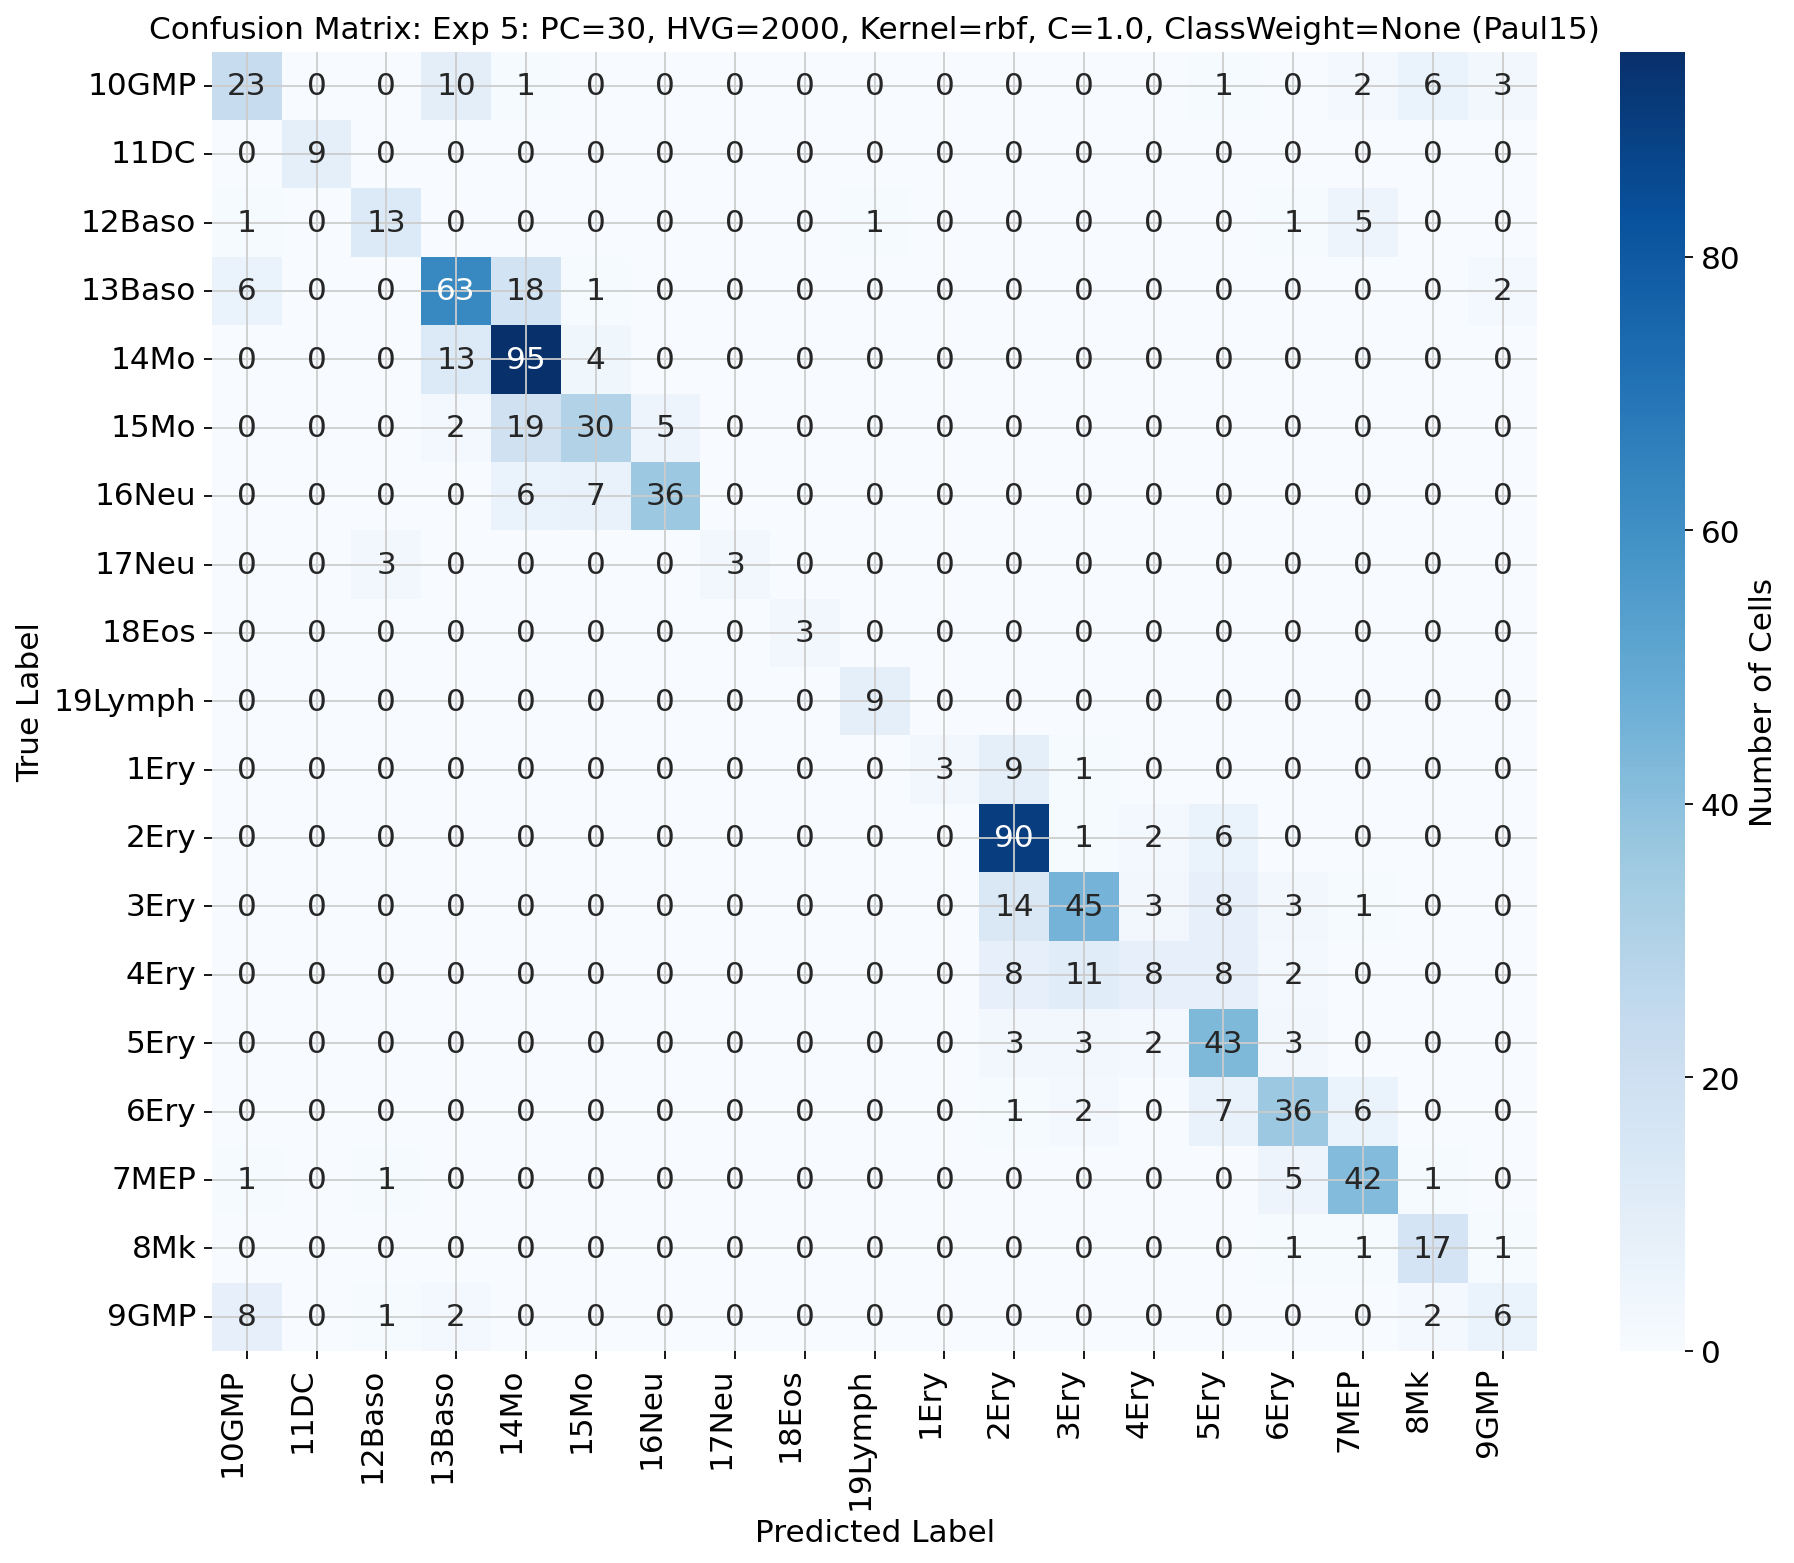


Starting Exp 6: PC=30, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 6: PC=30, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initi

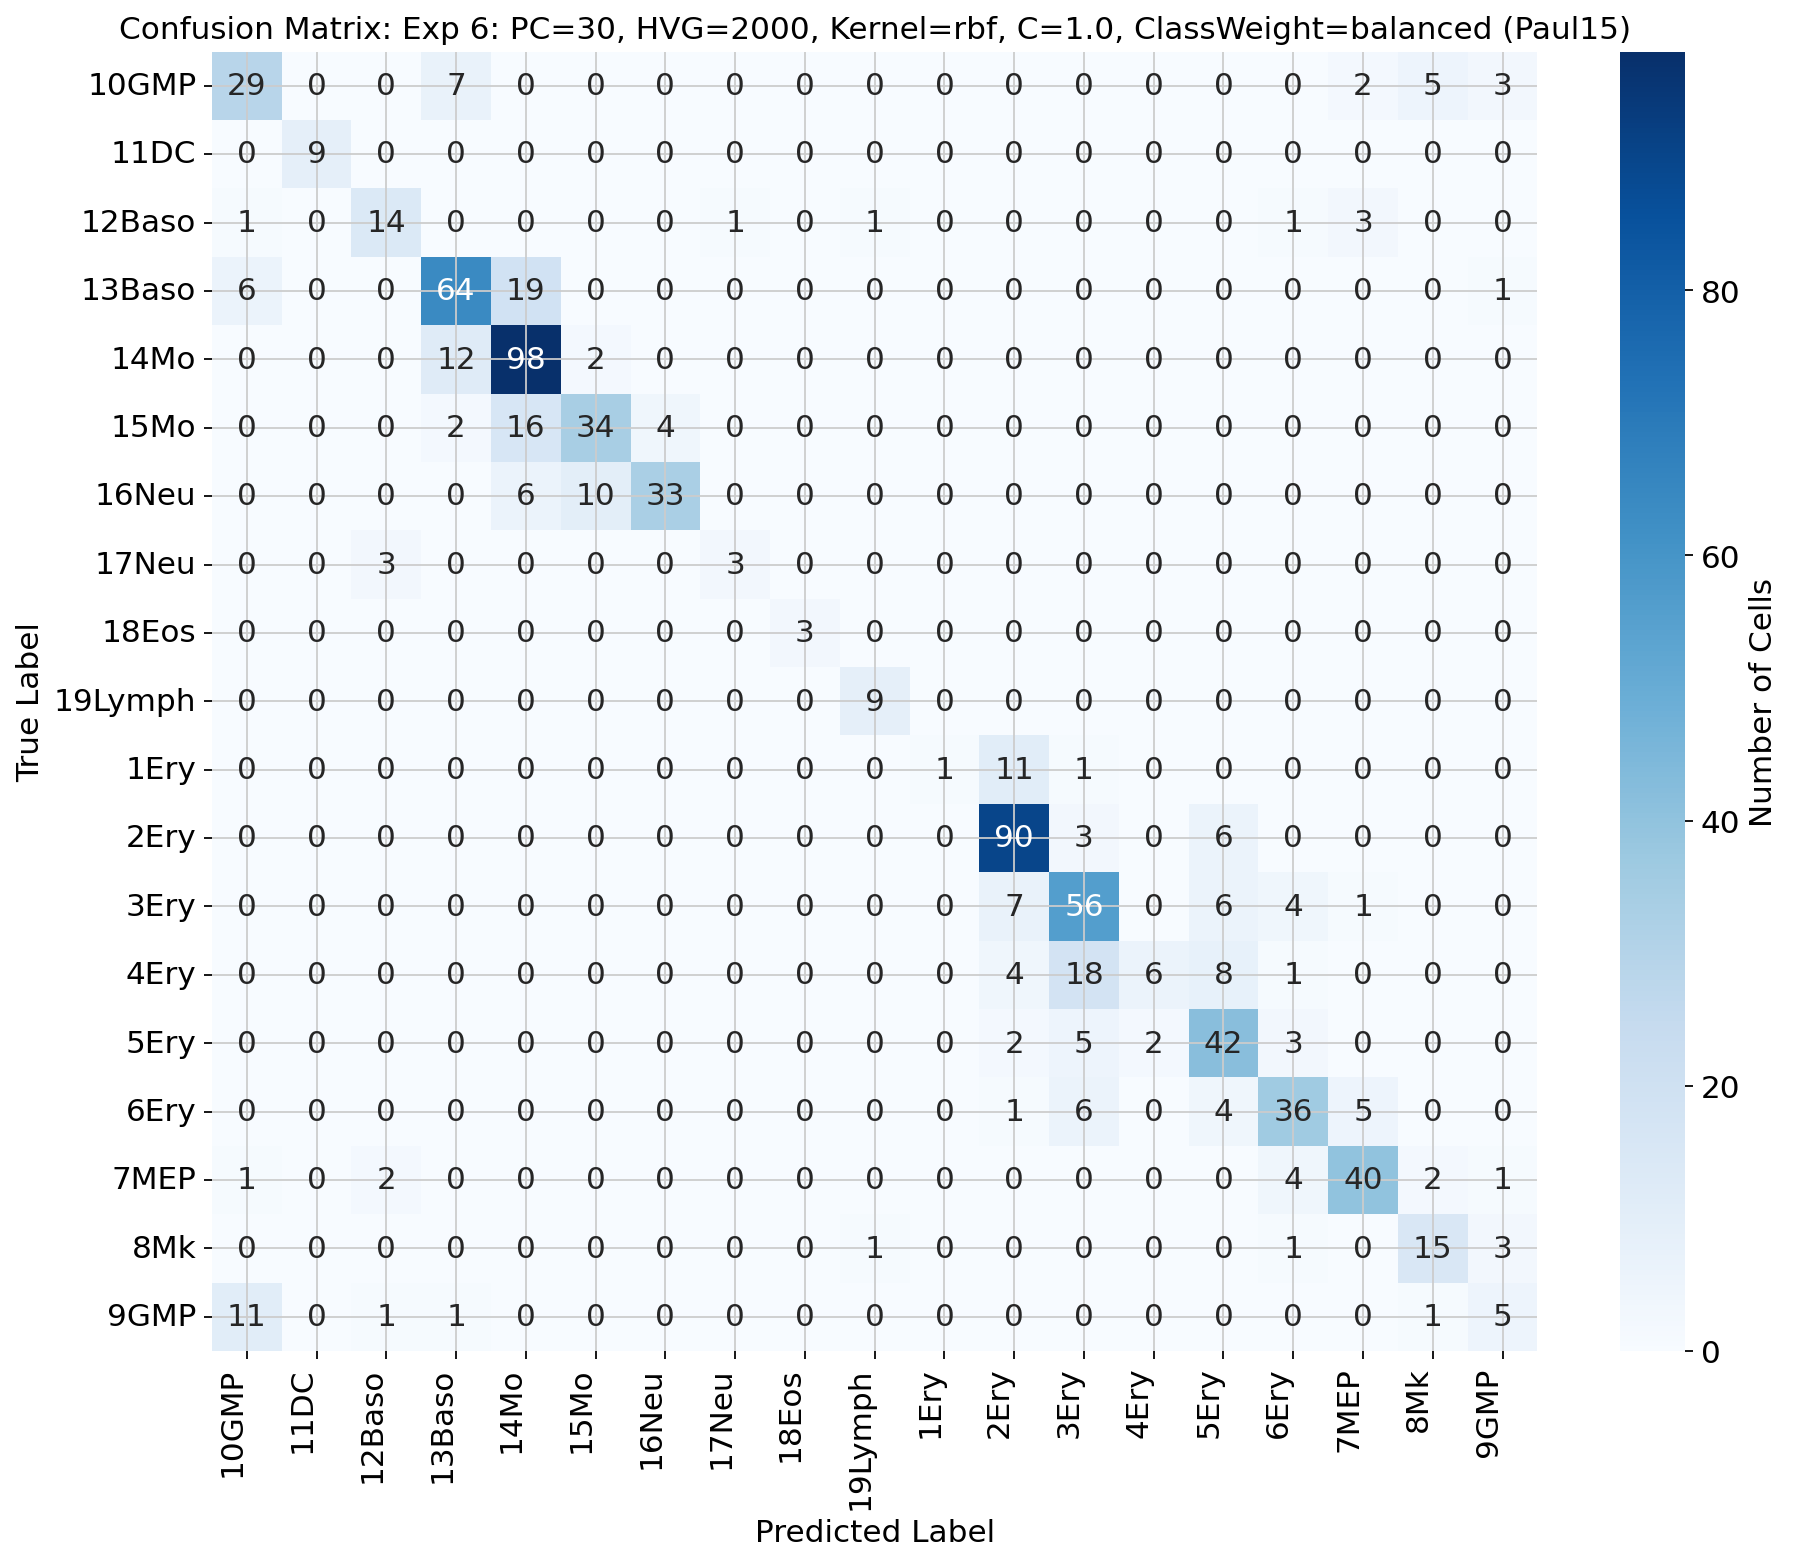


Starting Exp 7: PC=30, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 7: PC=30, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial prepro

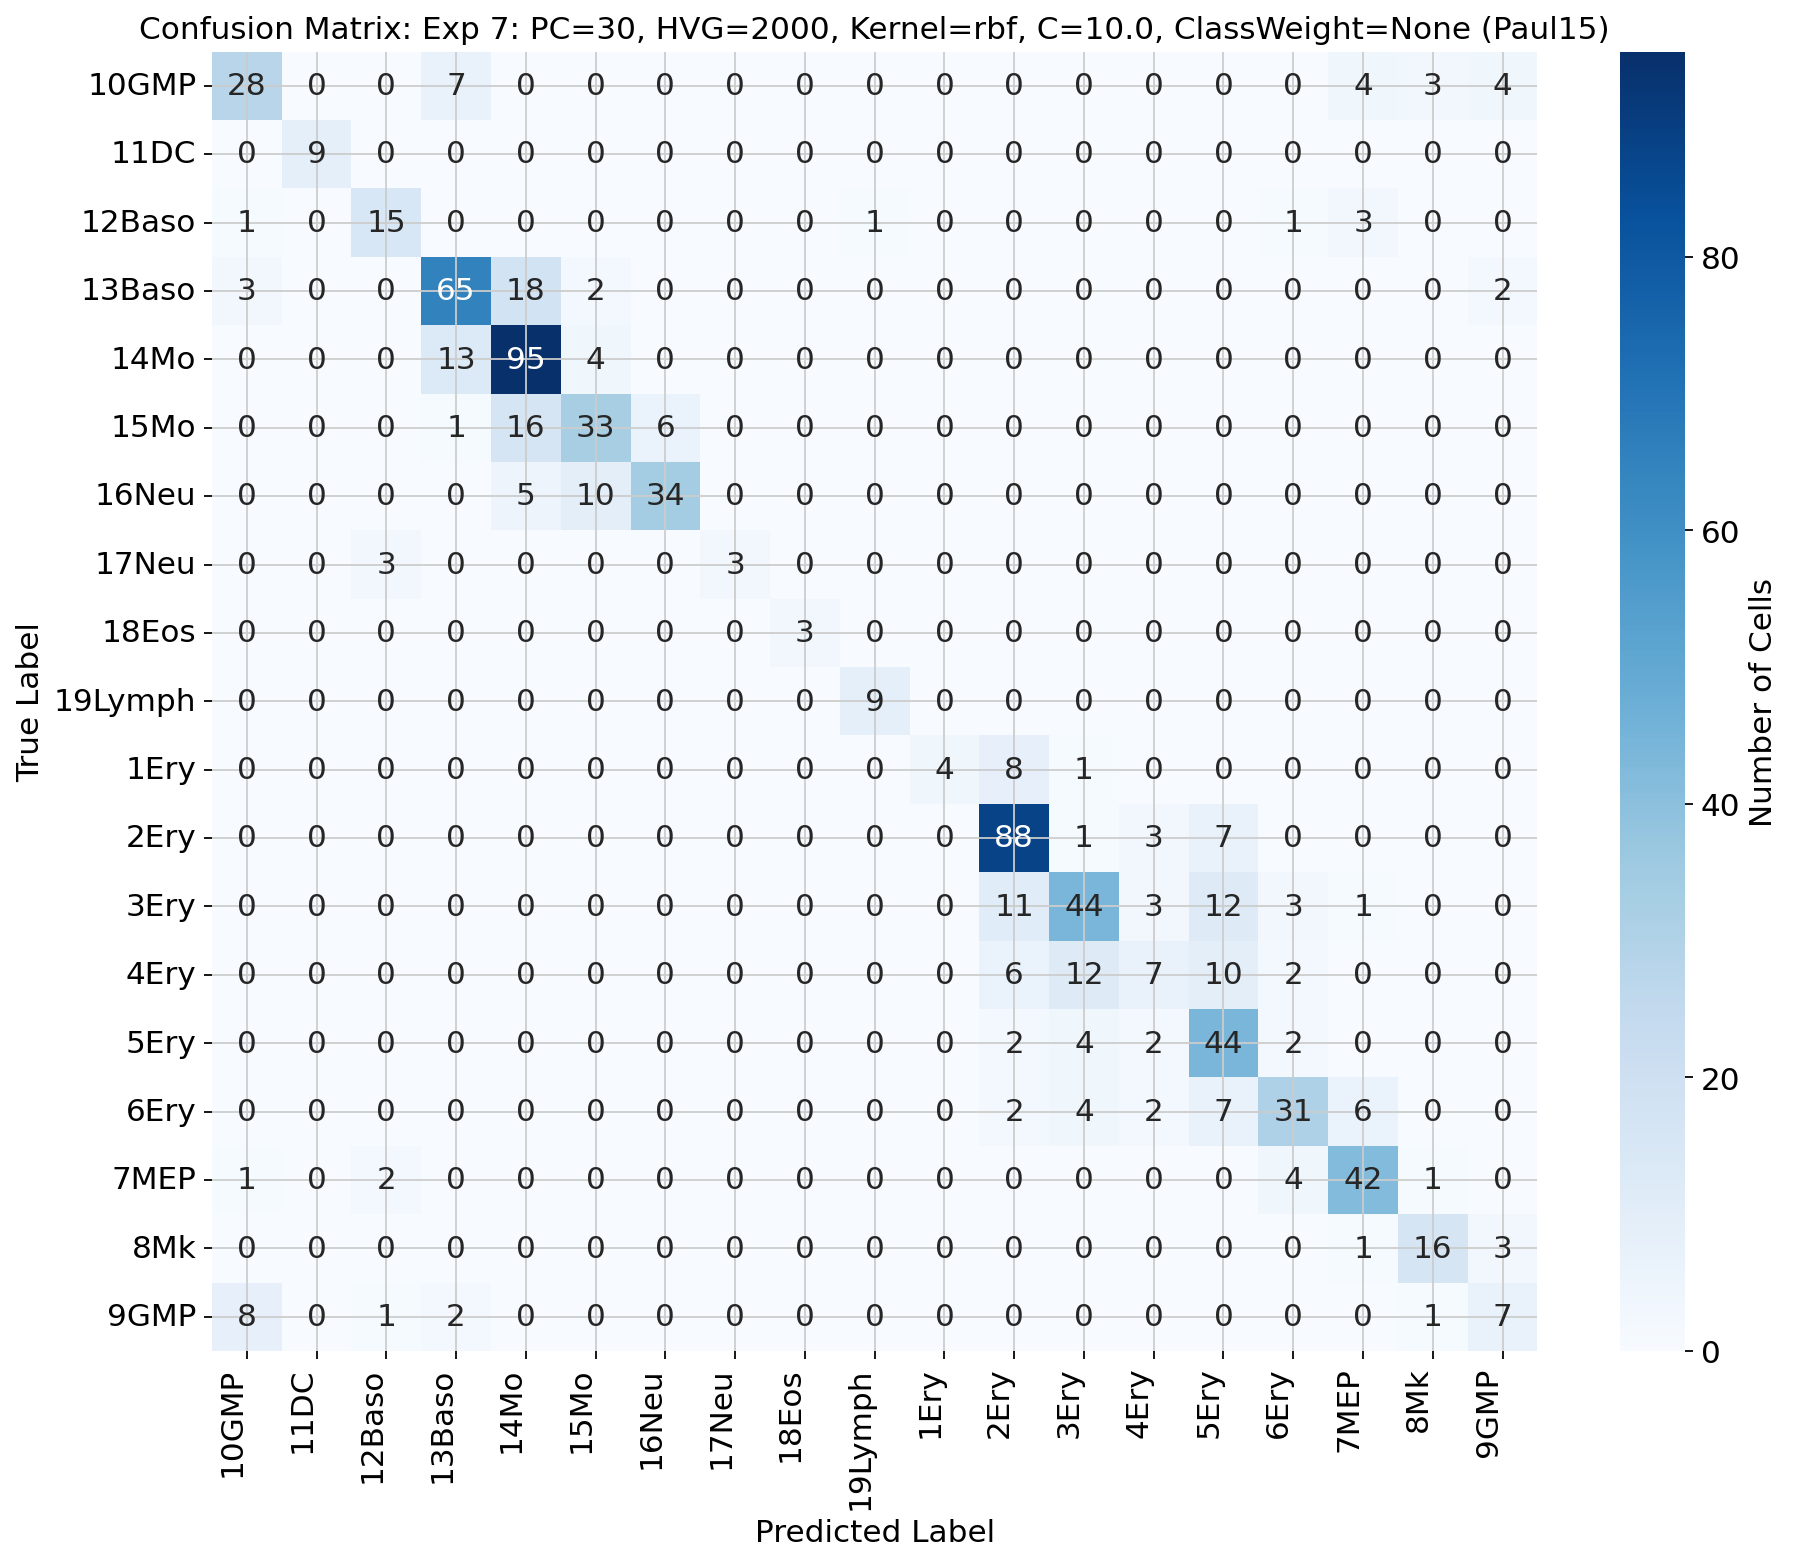


Starting Exp 8: PC=30, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 8: PC=30, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying in

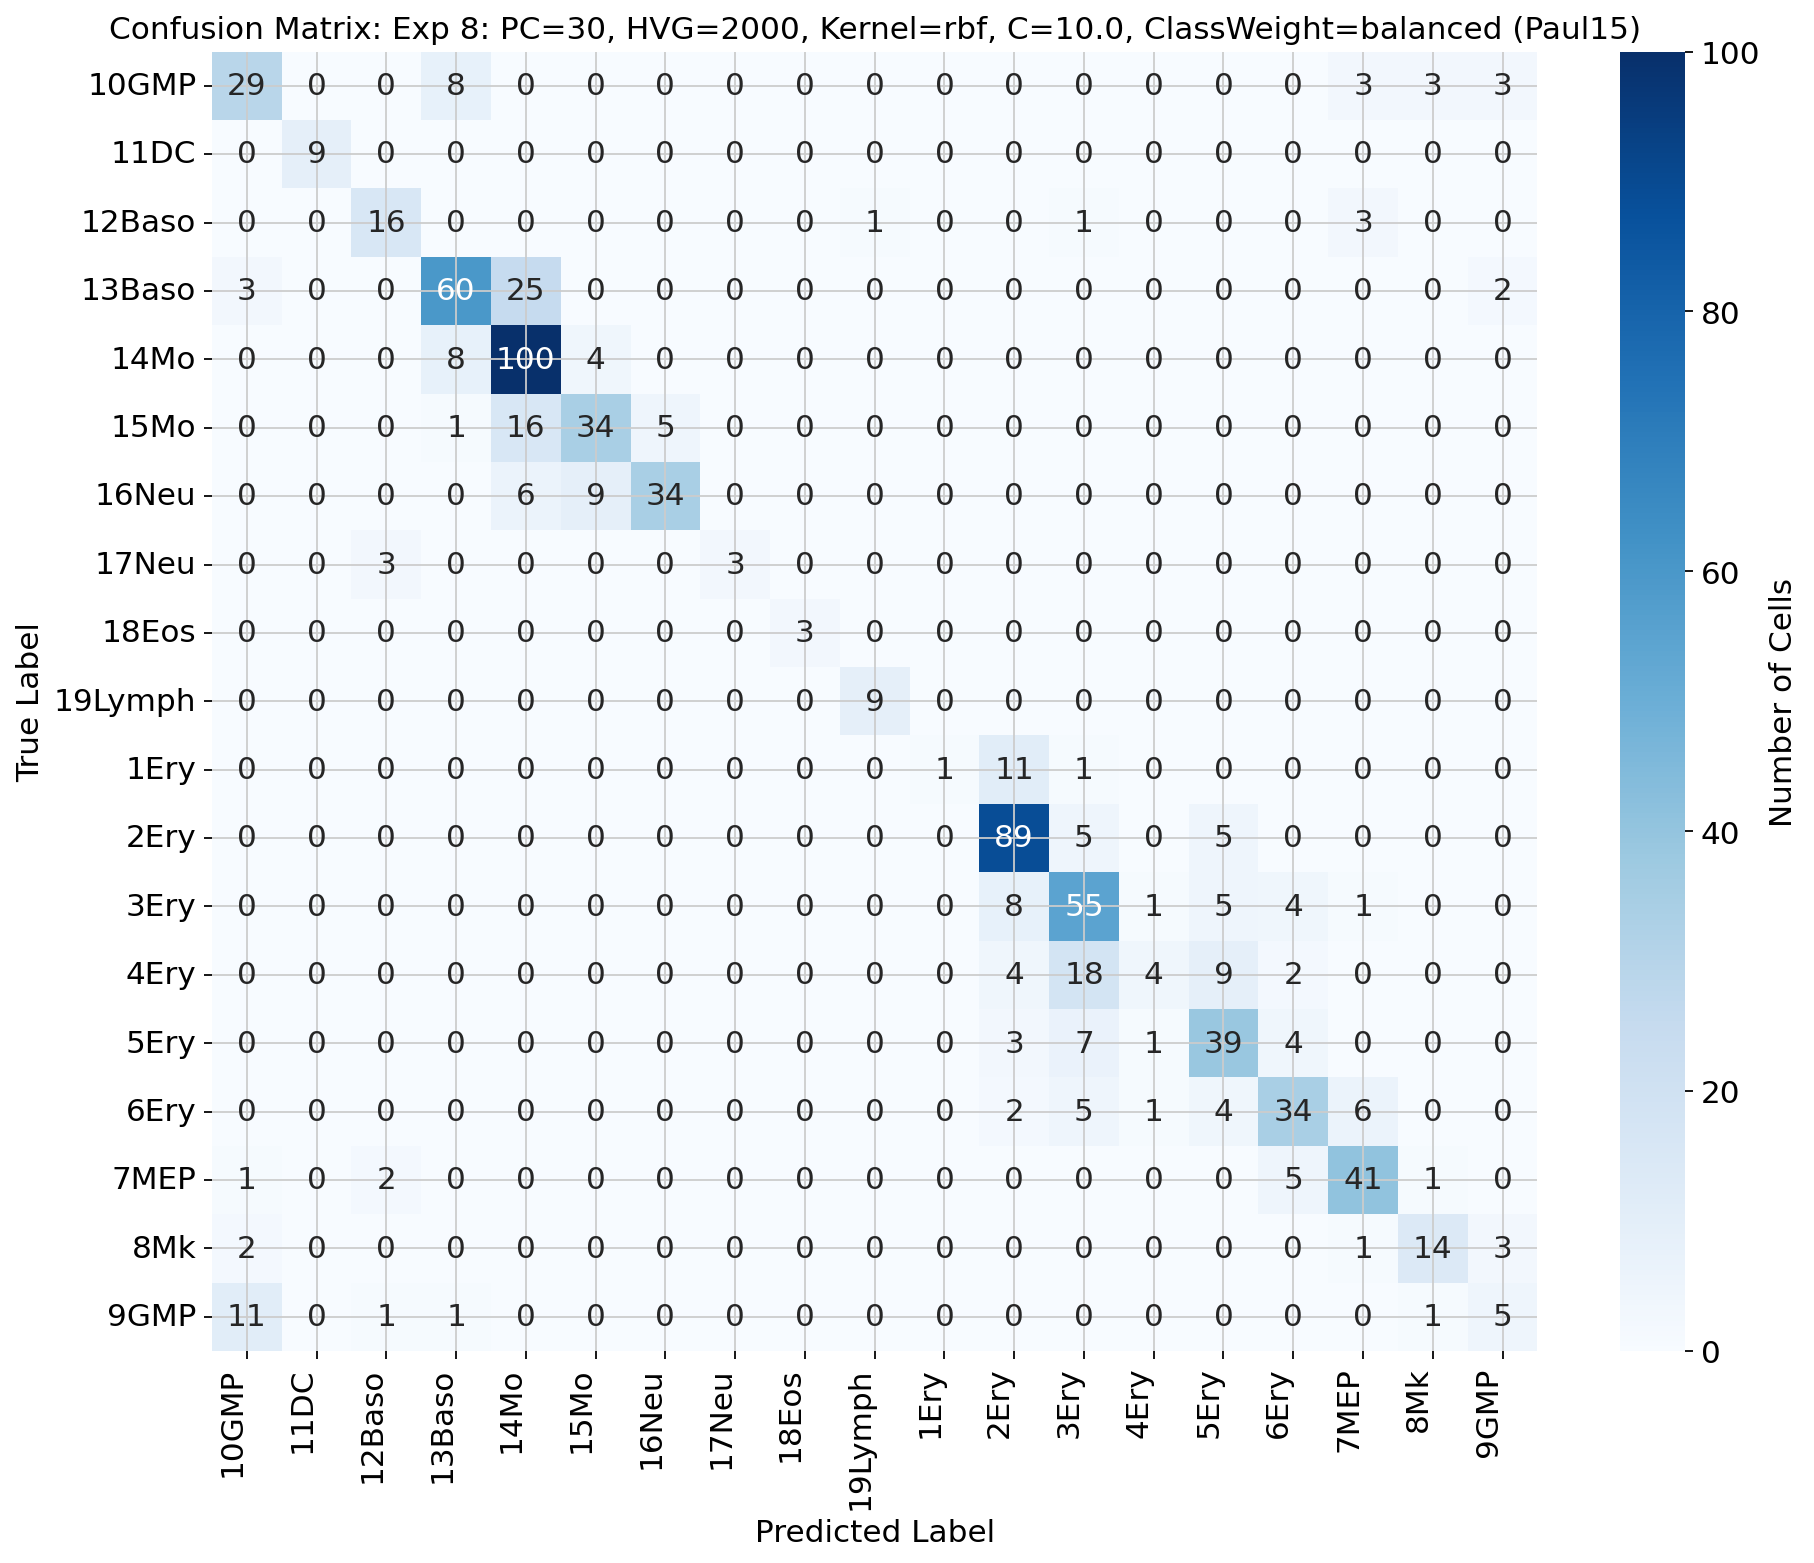


Starting Exp 9: PC=30, HVG=3000, Kernel=linear, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 9: PC=30, HVG=3000, Kernel=linear, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial 

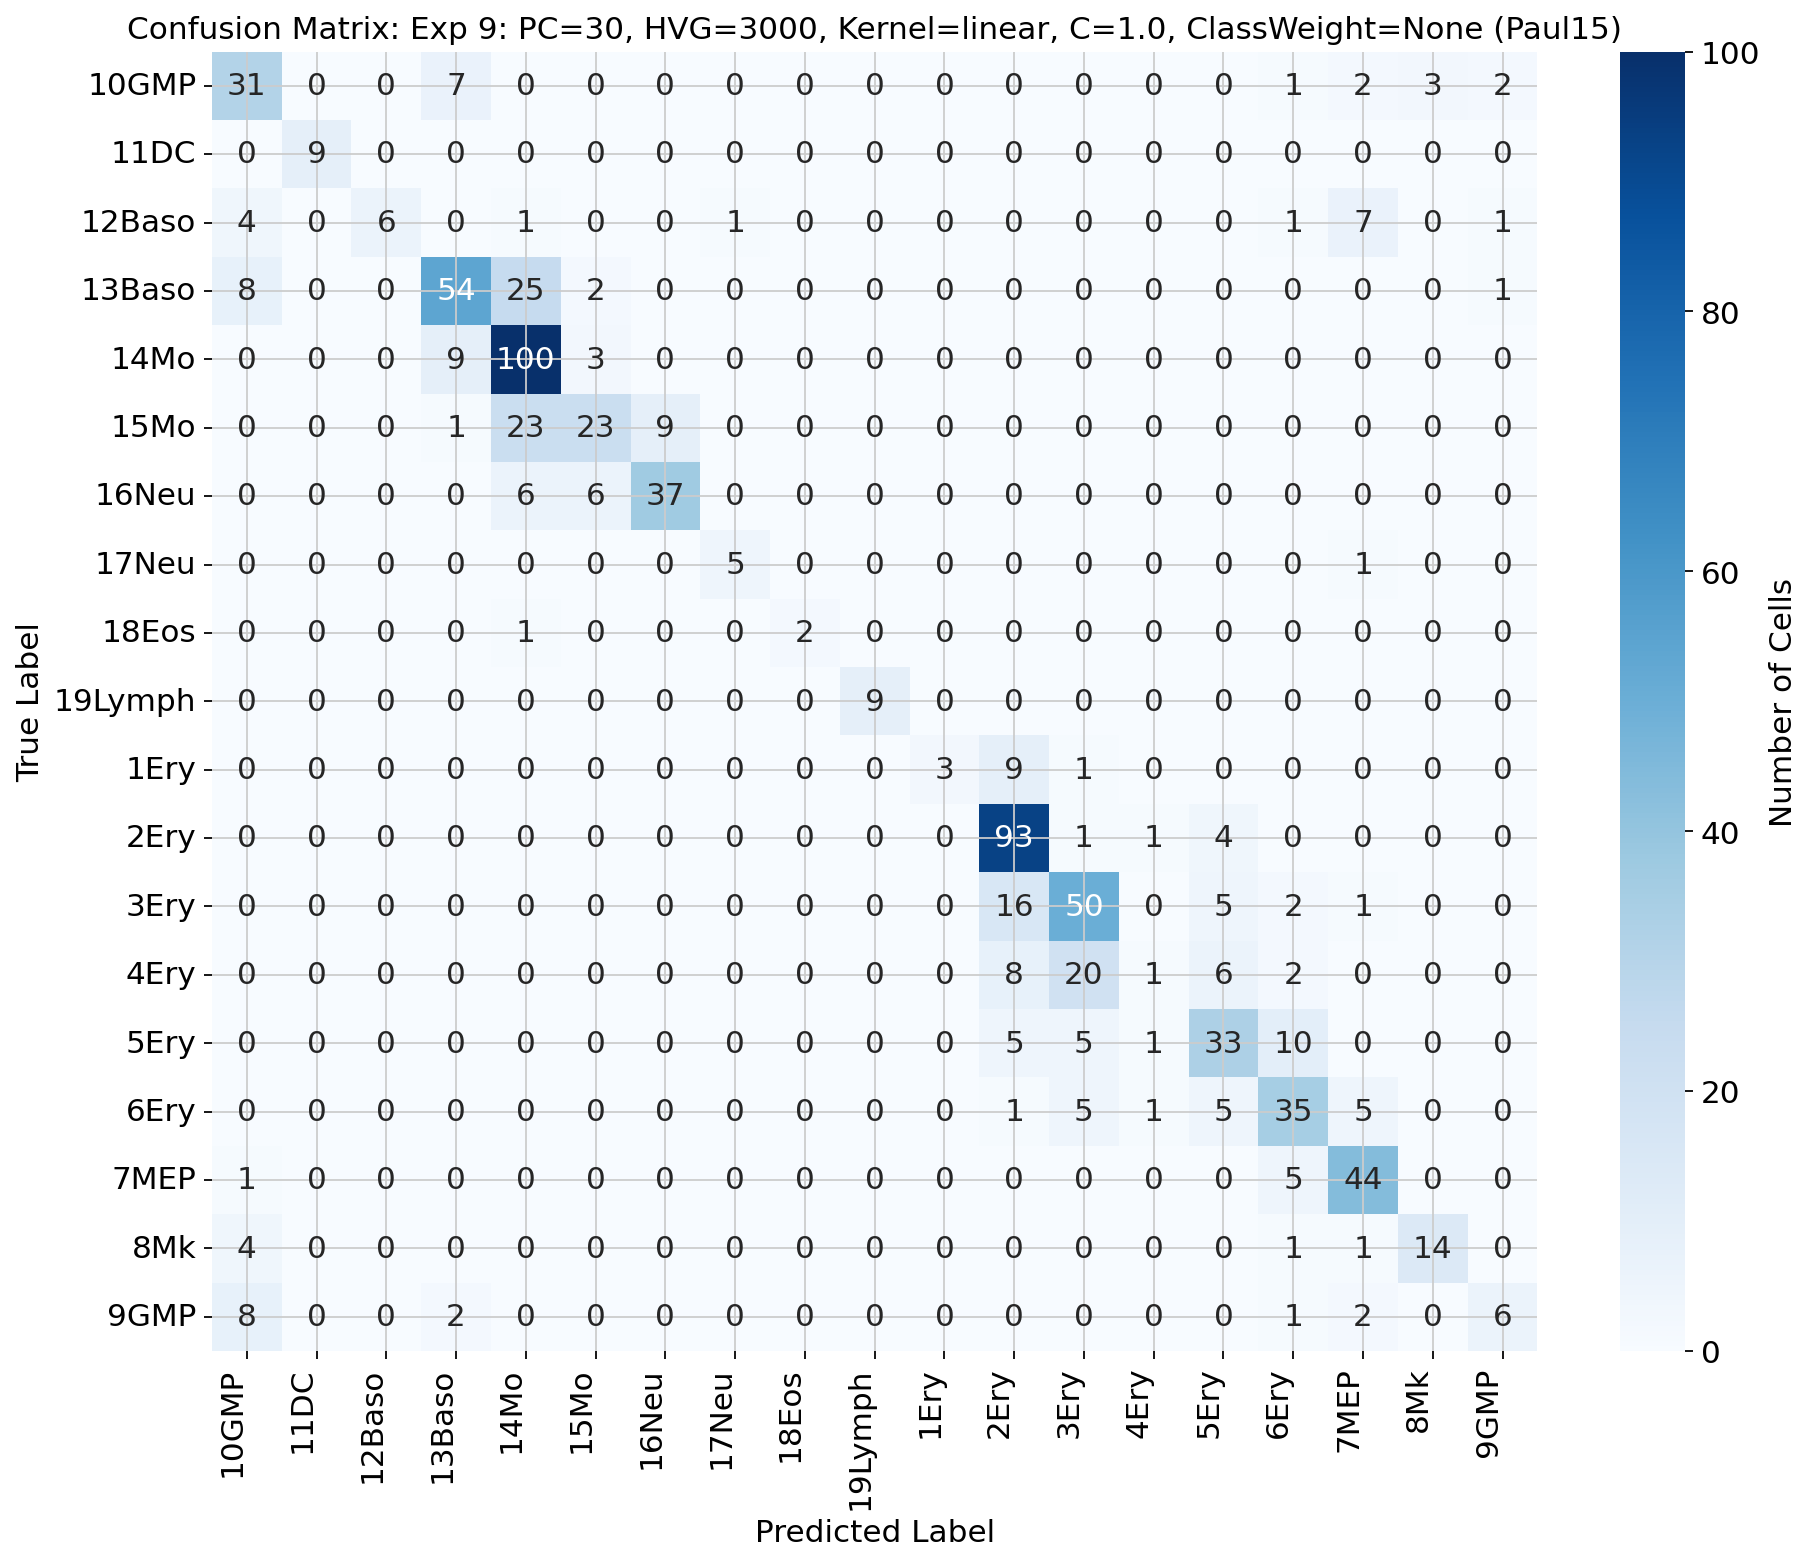


Starting Exp 10: PC=30, HVG=3000, Kernel=linear, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 10: PC=30, HVG=3000, Kernel=linear, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
App

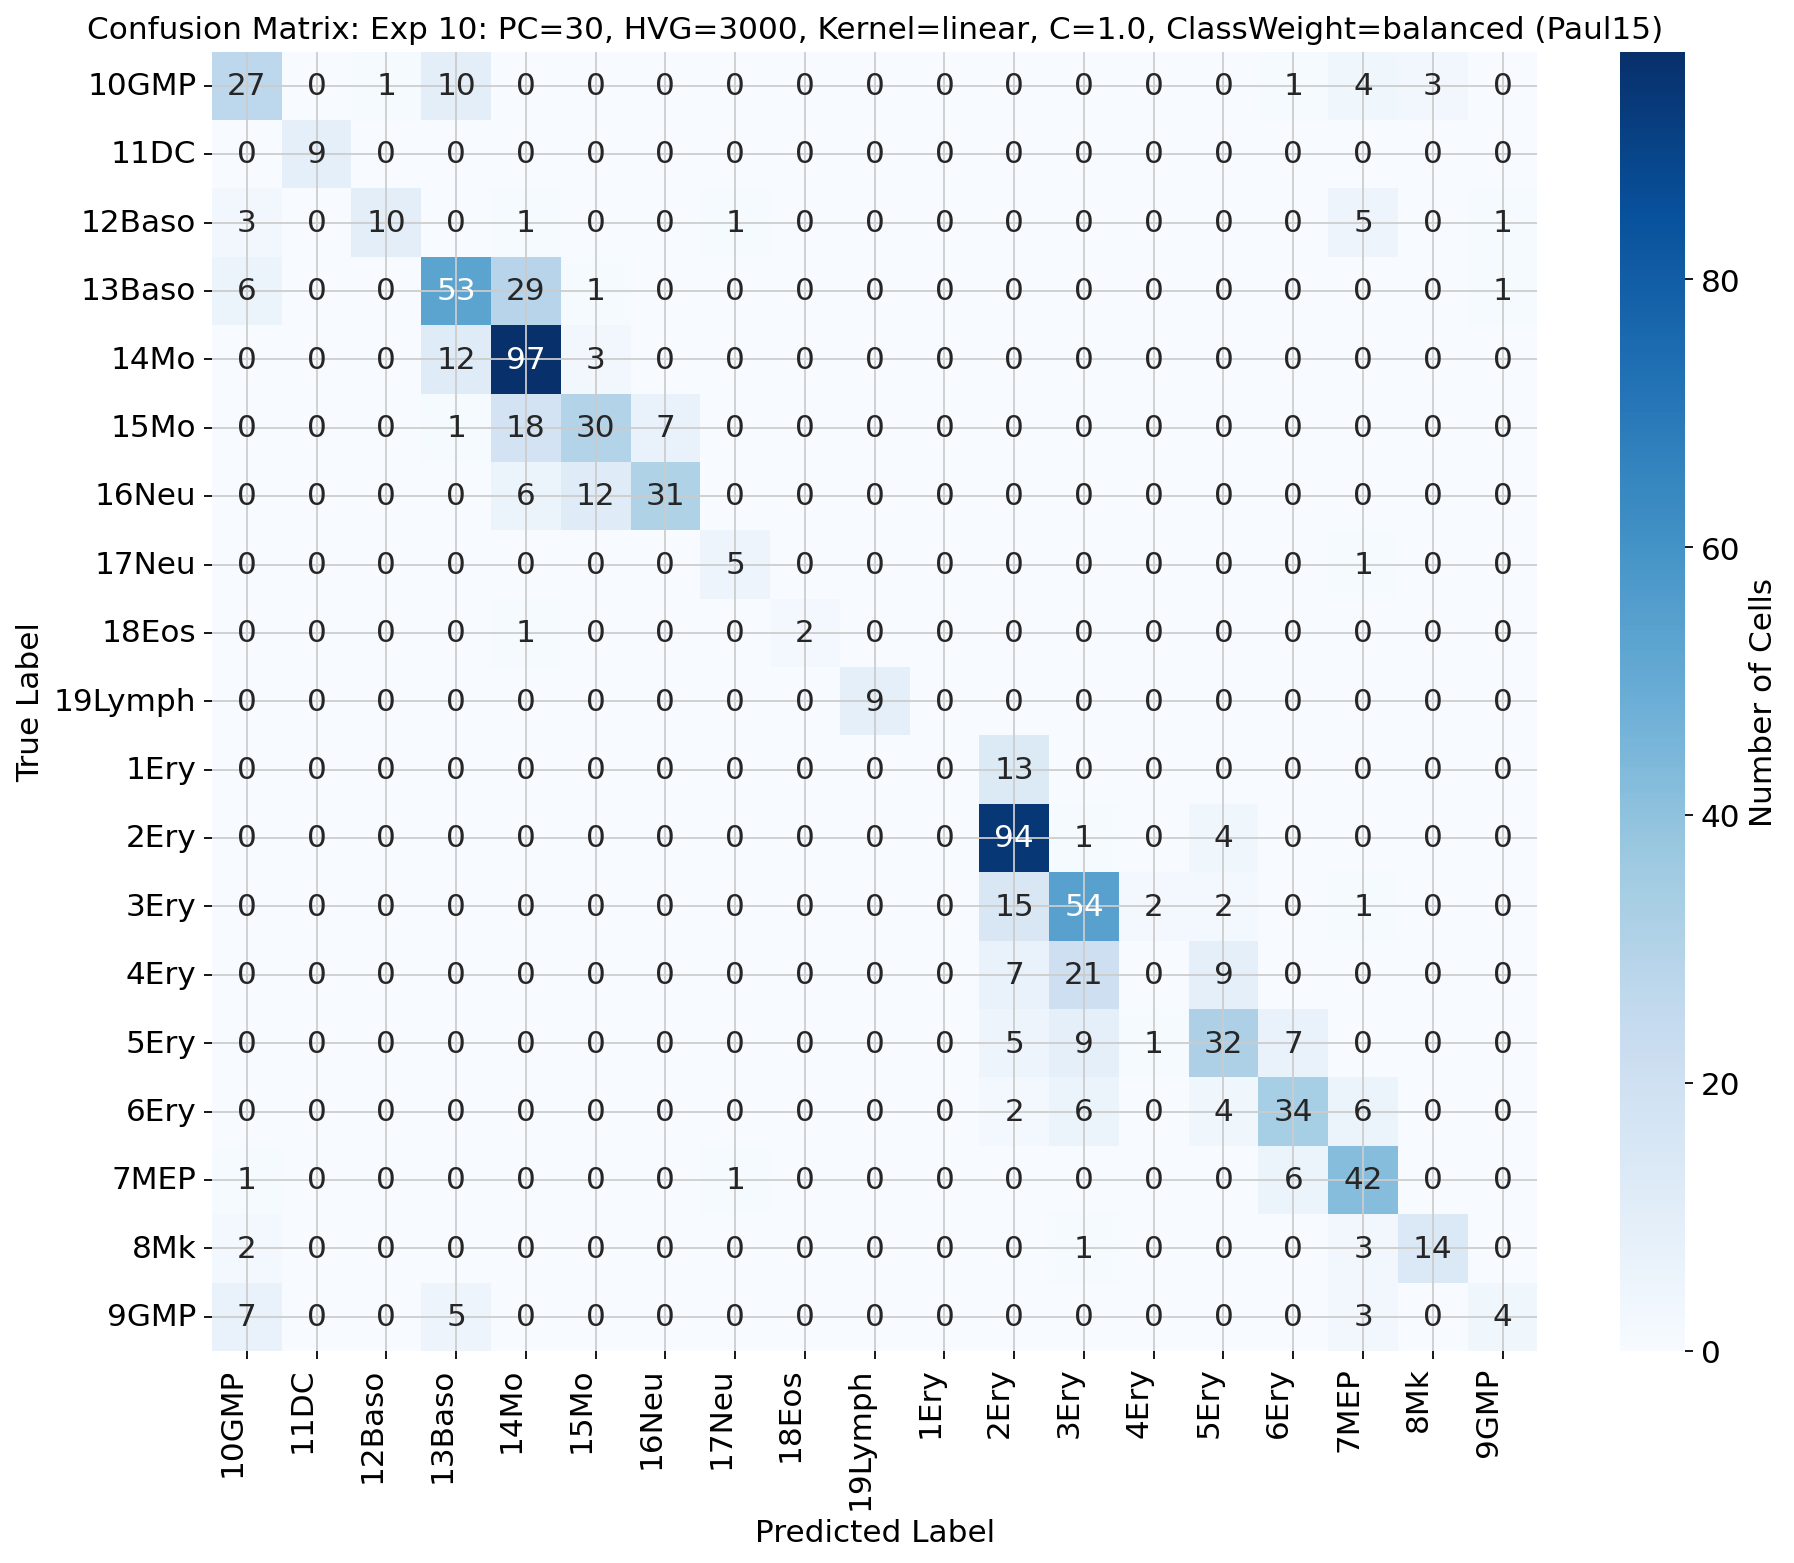


Starting Exp 11: PC=30, HVG=3000, Kernel=linear, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 11: PC=30, HVG=3000, Kernel=linear, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying ini

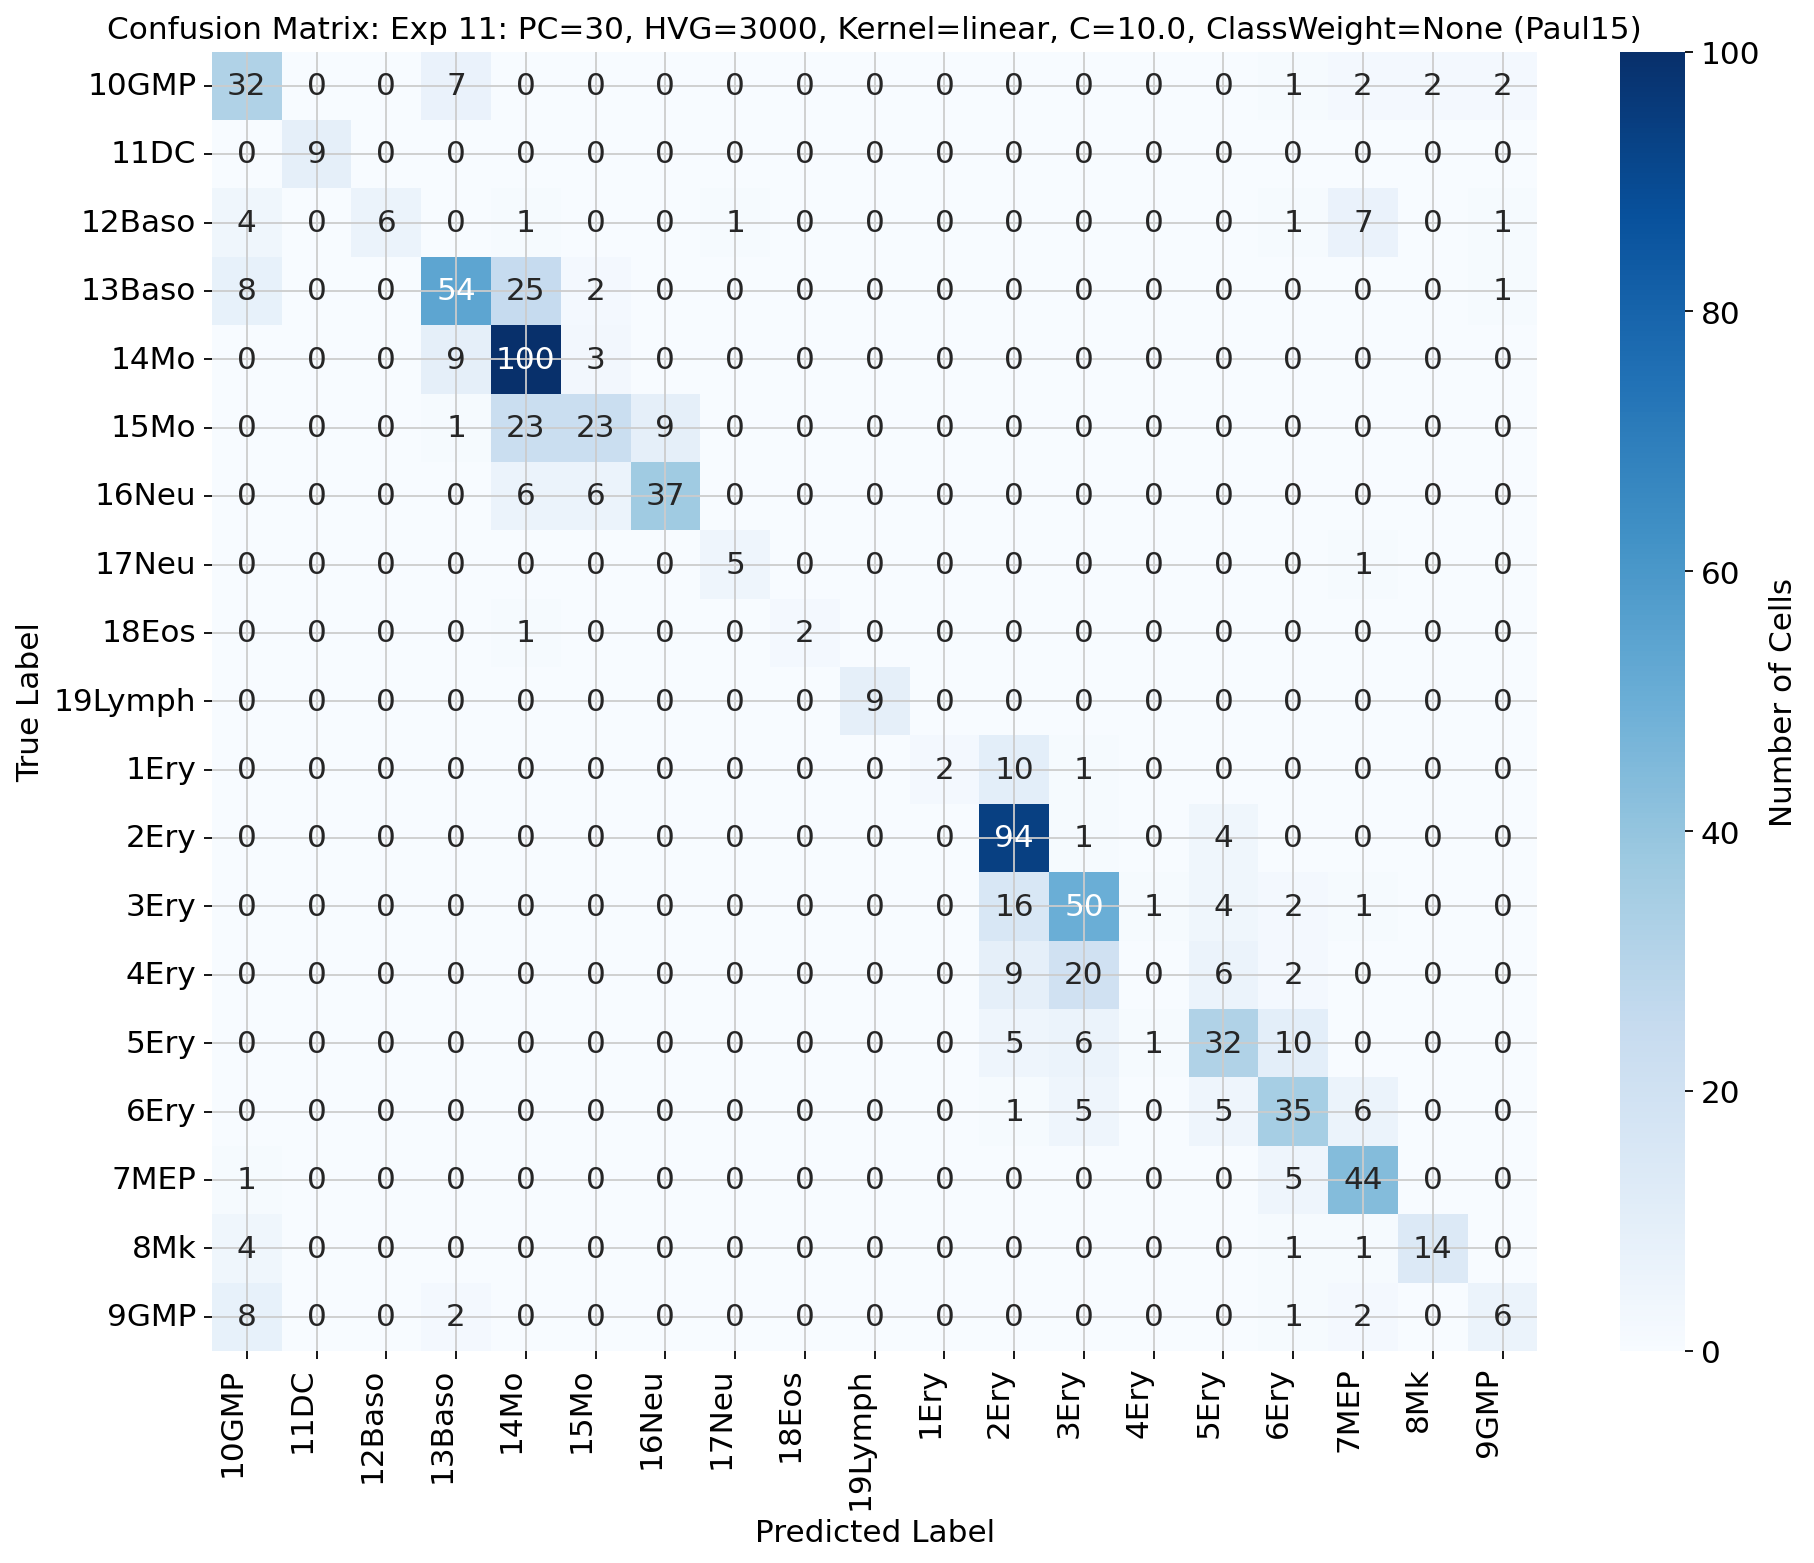


Starting Exp 12: PC=30, HVG=3000, Kernel=linear, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 12: PC=30, HVG=3000, Kernel=linear, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...


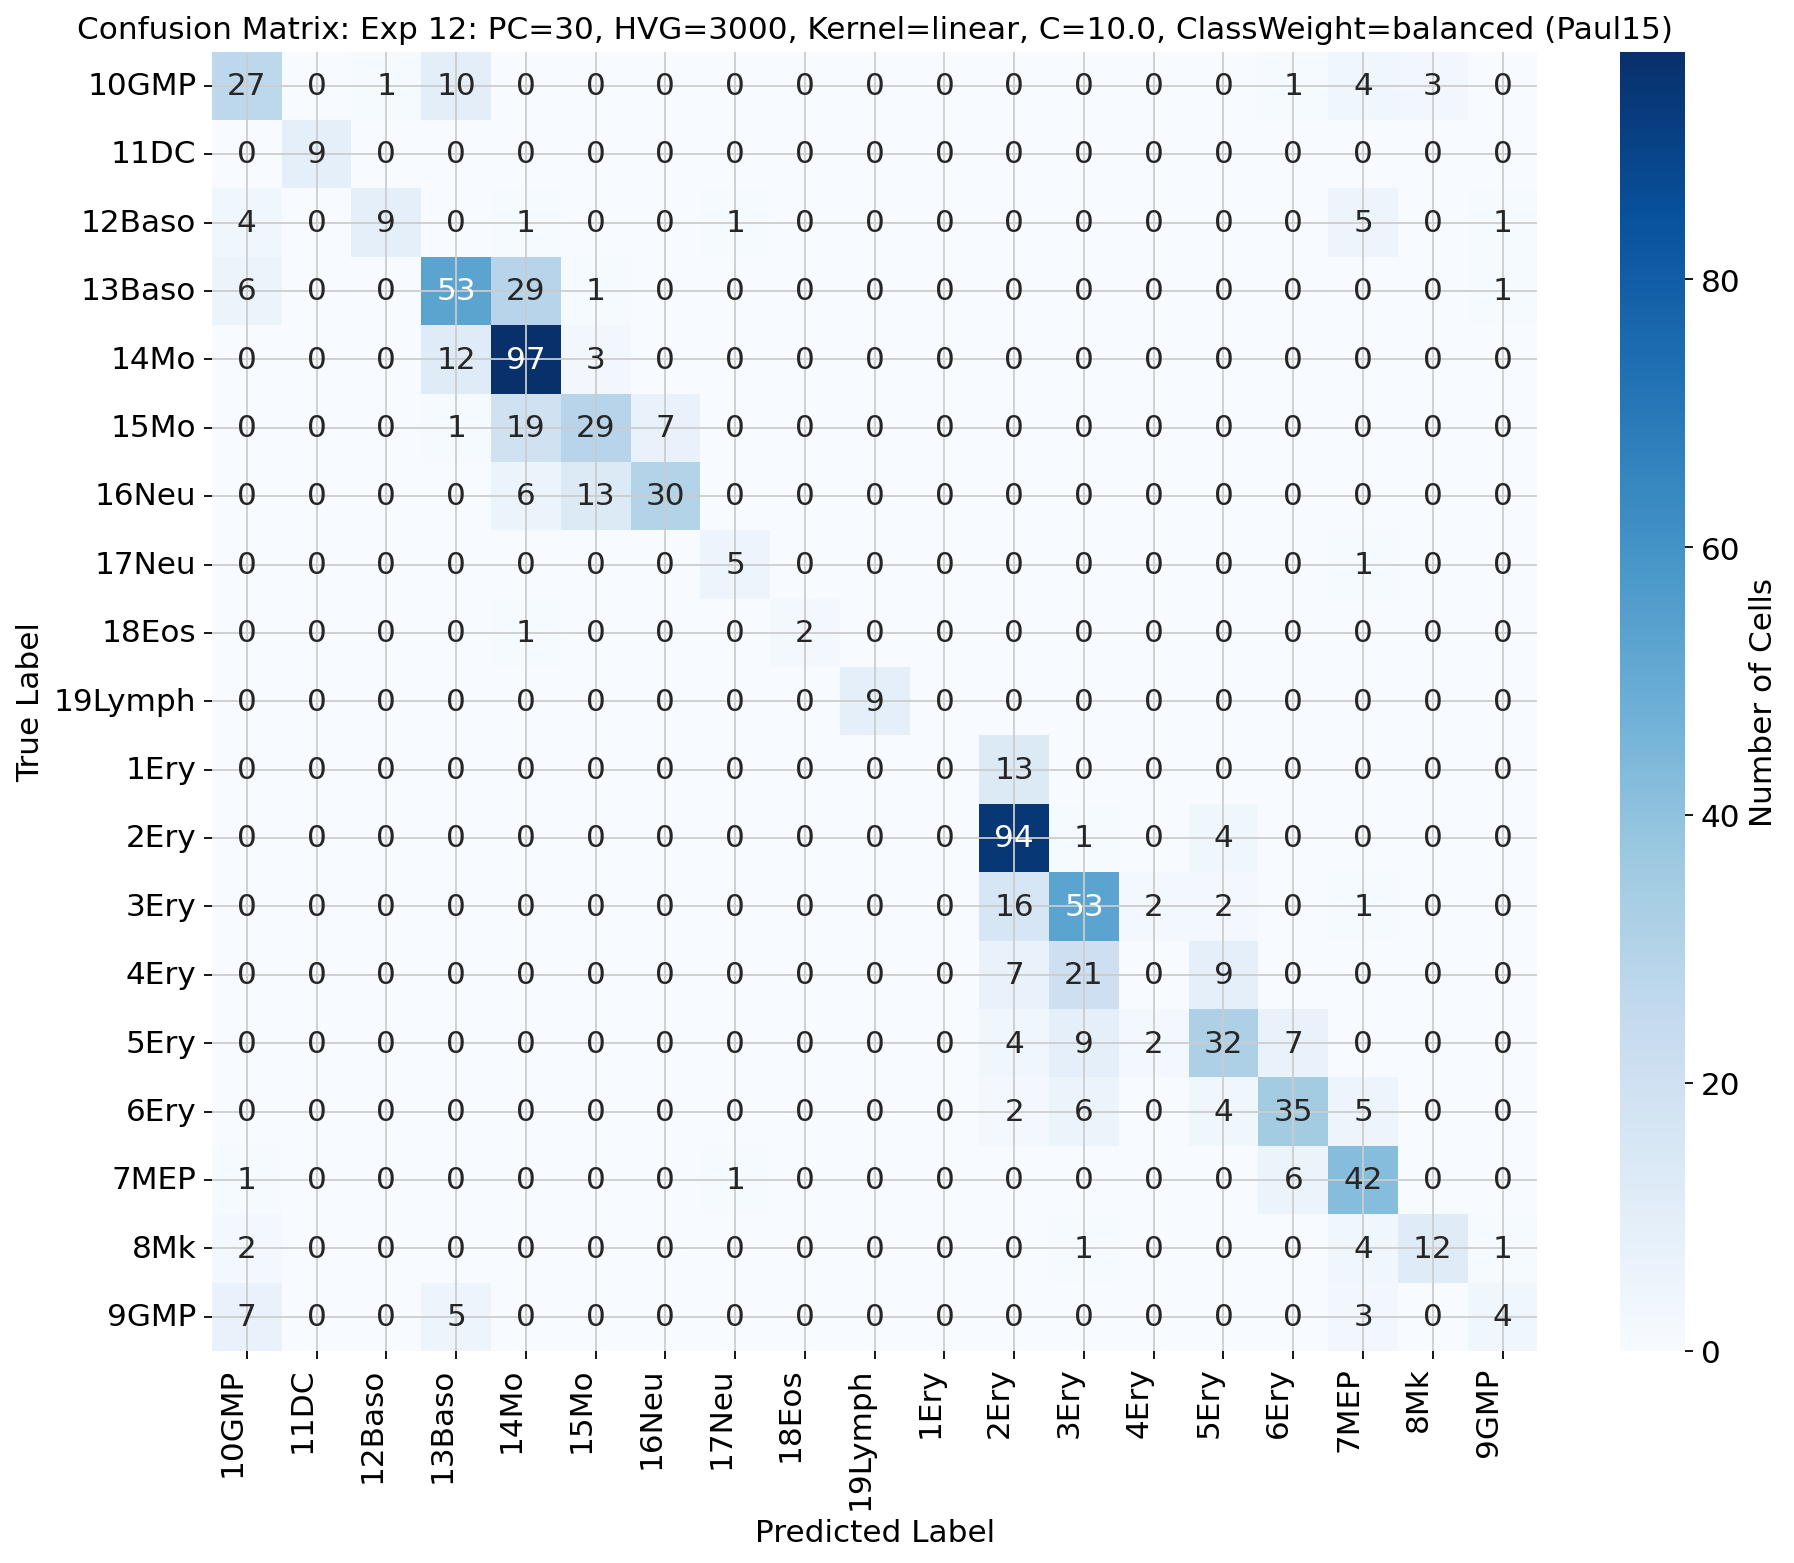


Starting Exp 13: PC=30, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 13: PC=30, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preproc

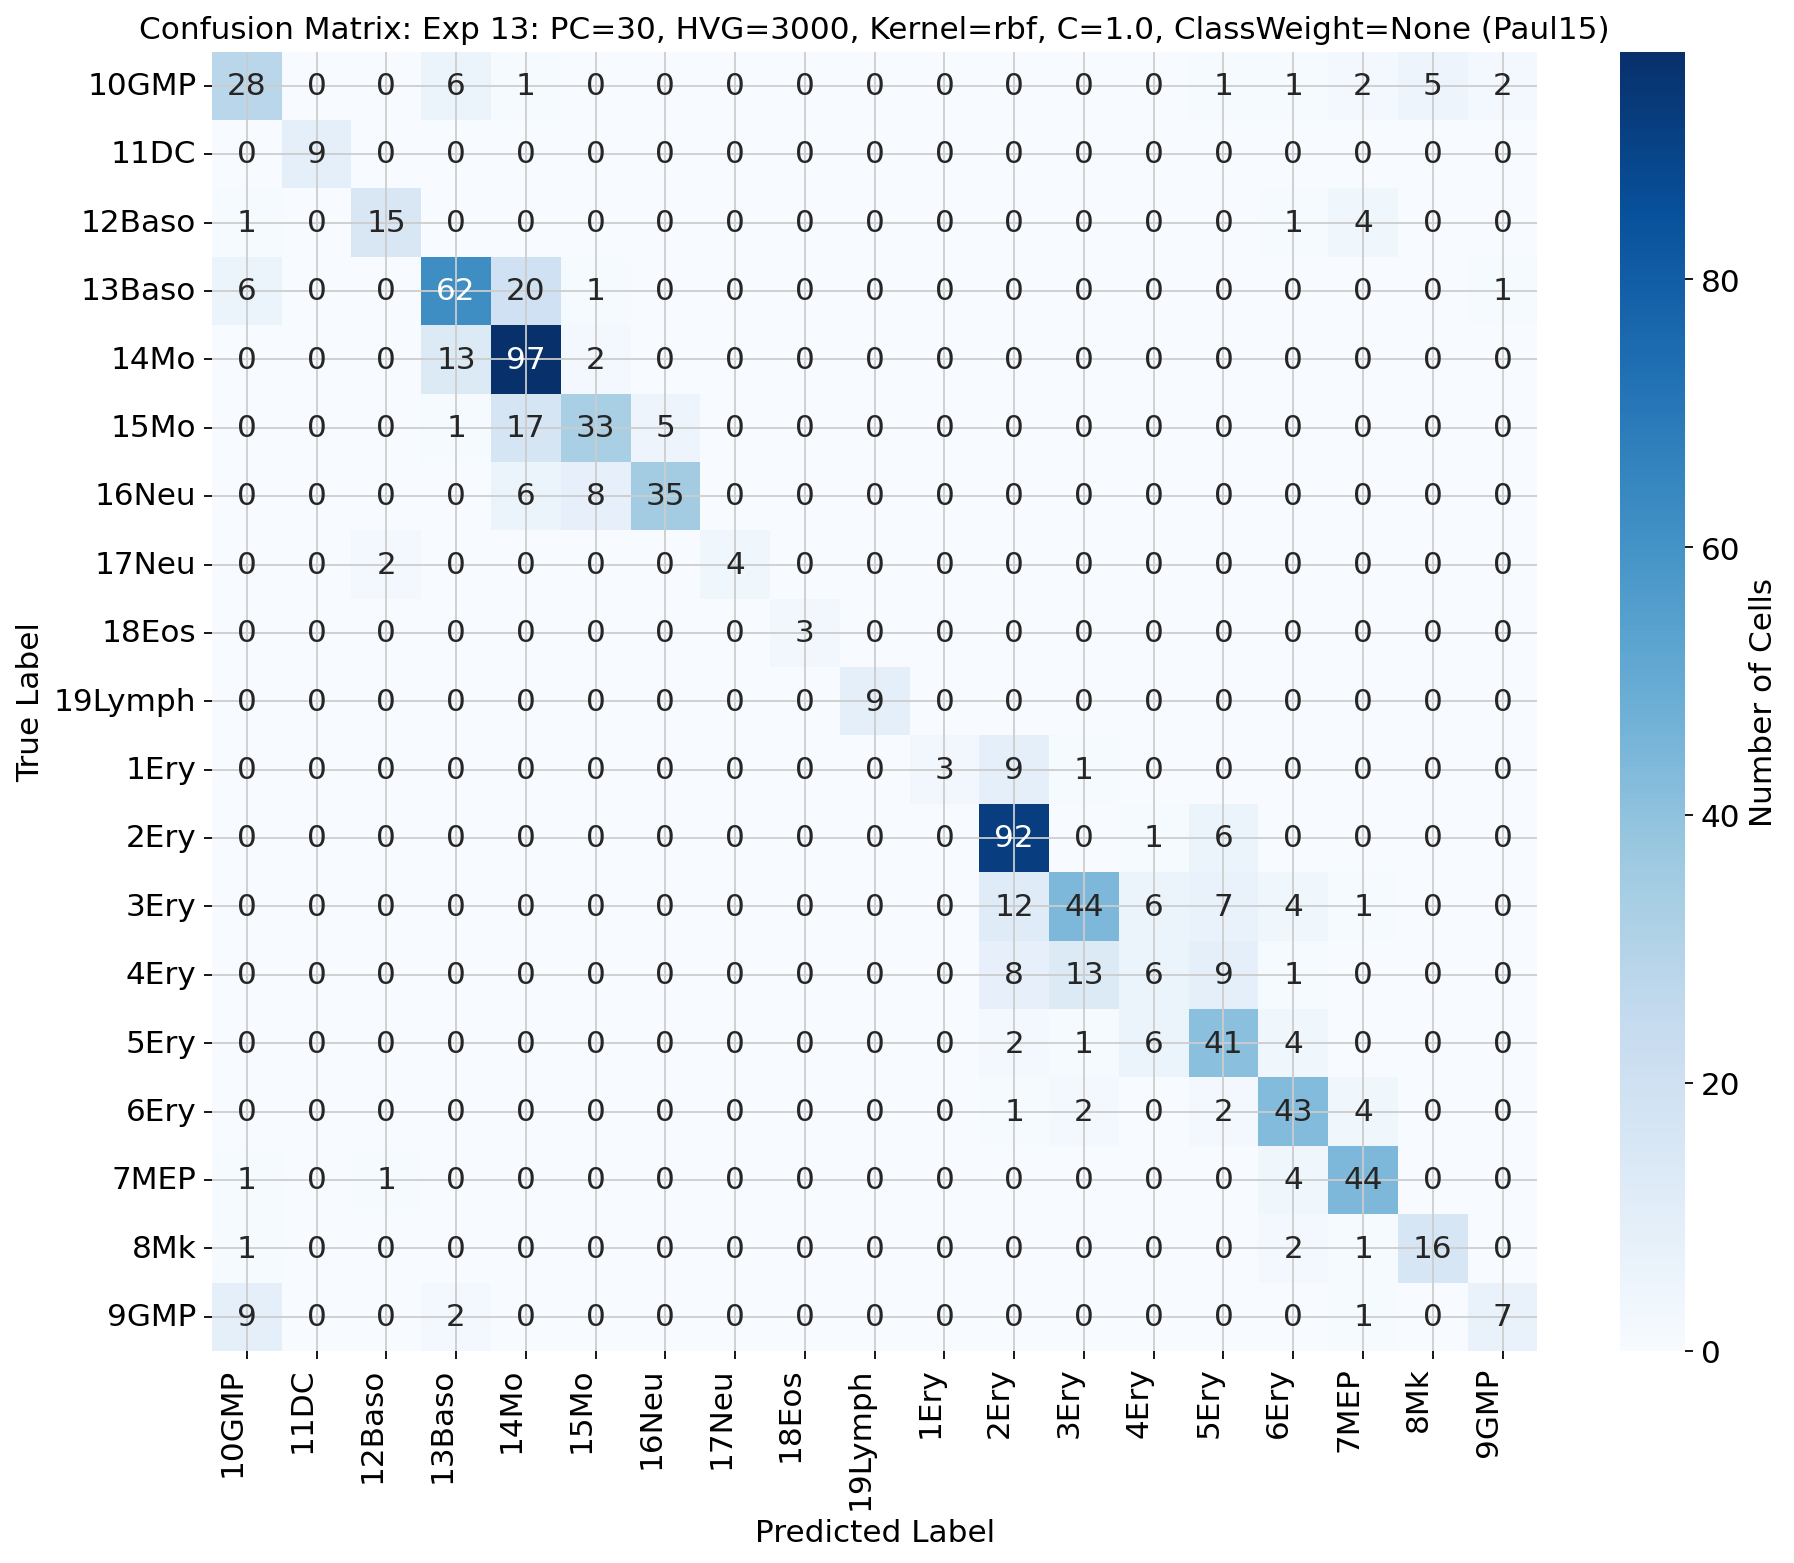


Starting Exp 14: PC=30, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 14: PC=30, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying ini

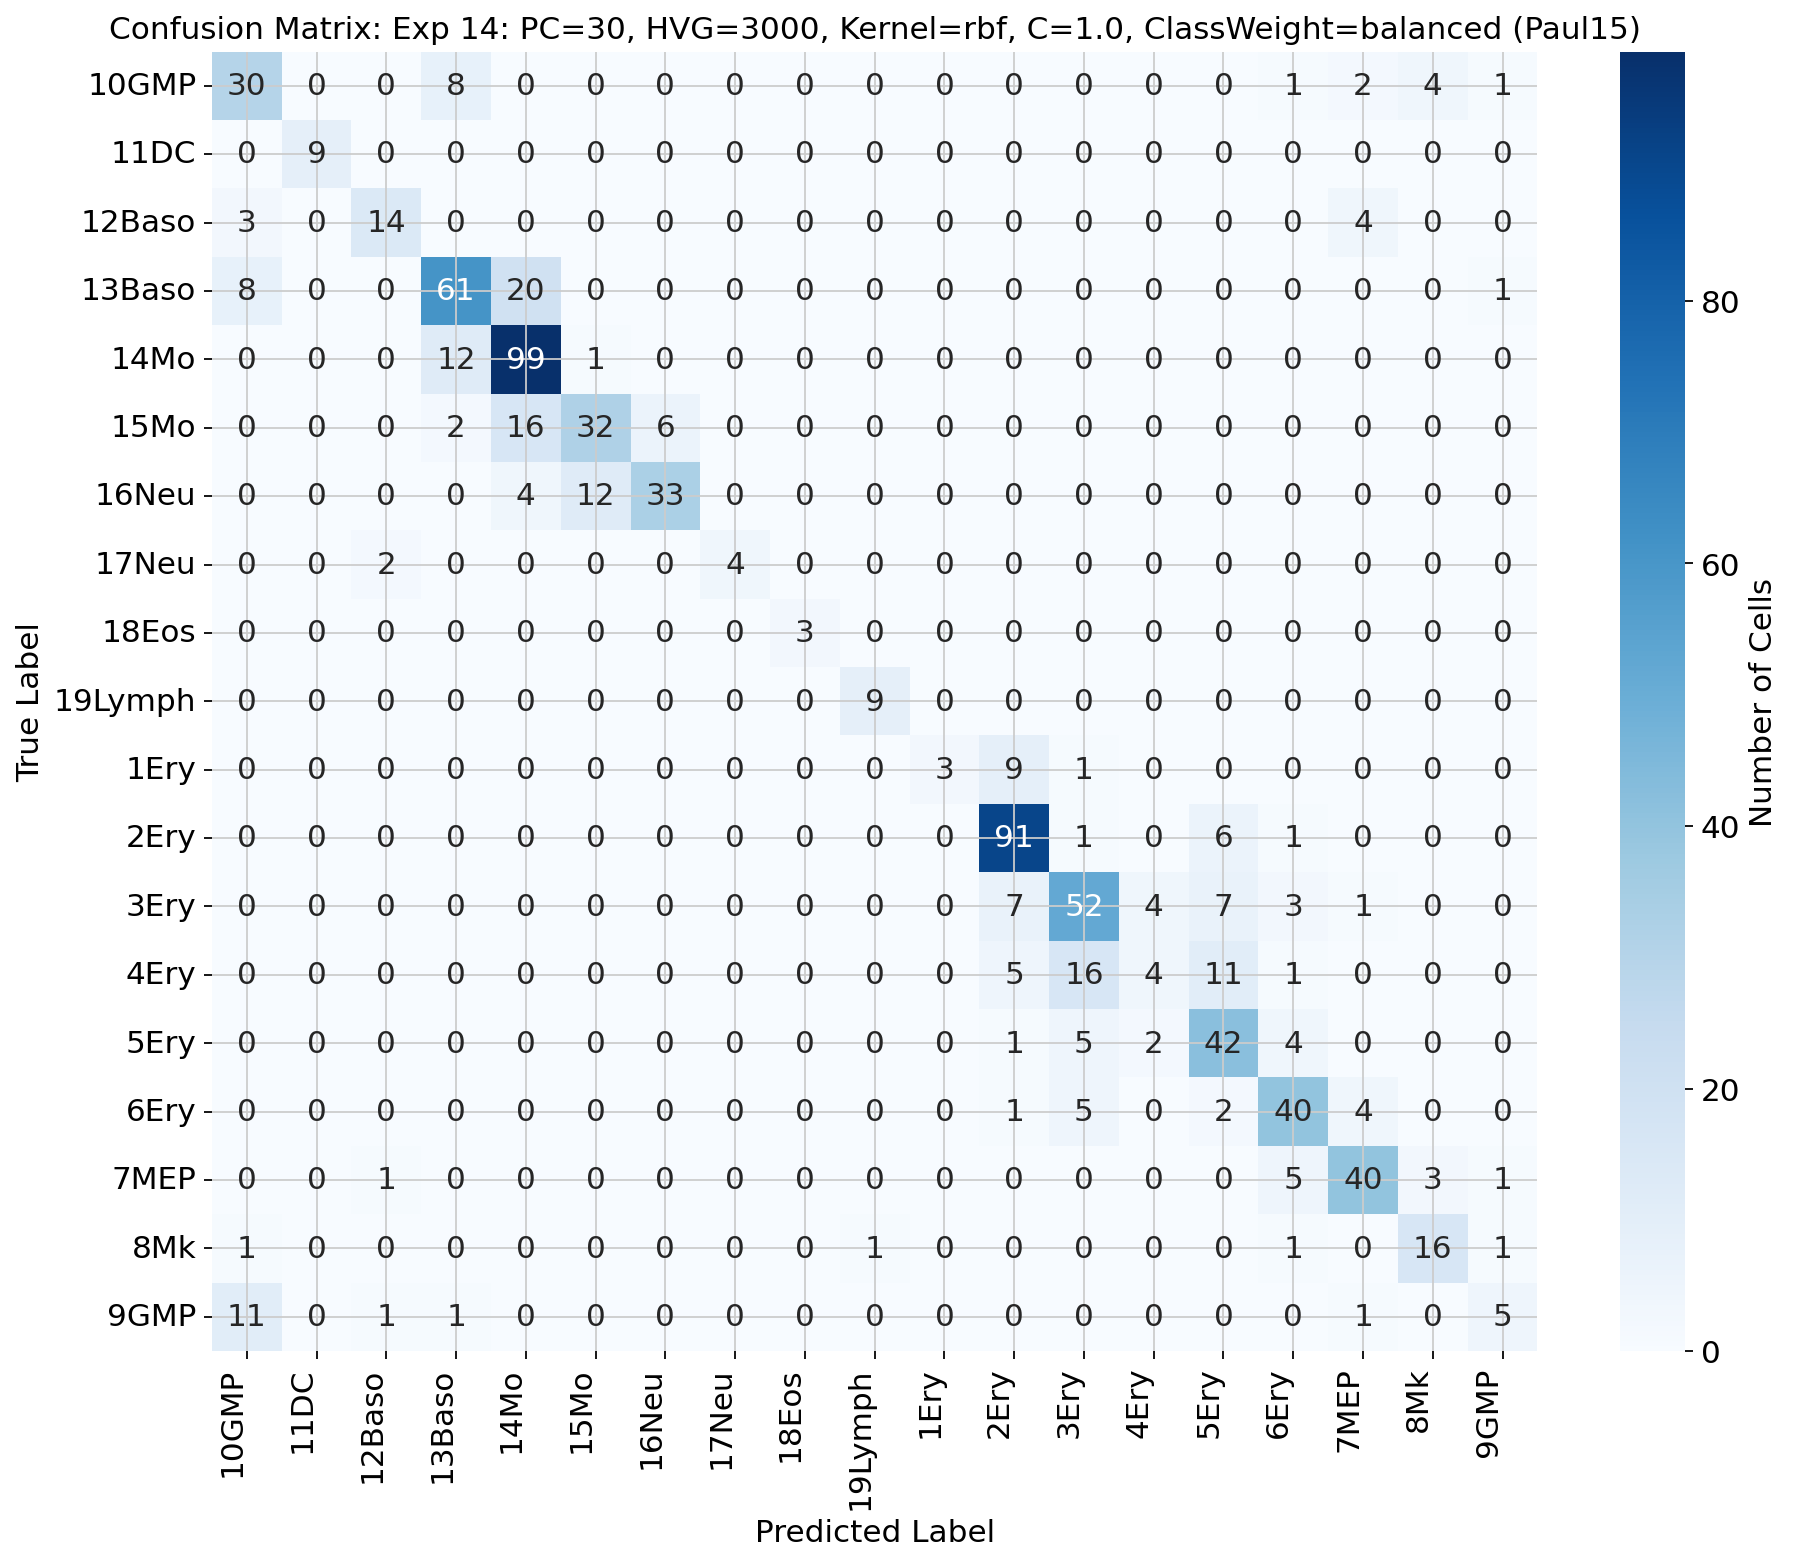


Starting Exp 15: PC=30, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 15: PC=30, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial prep

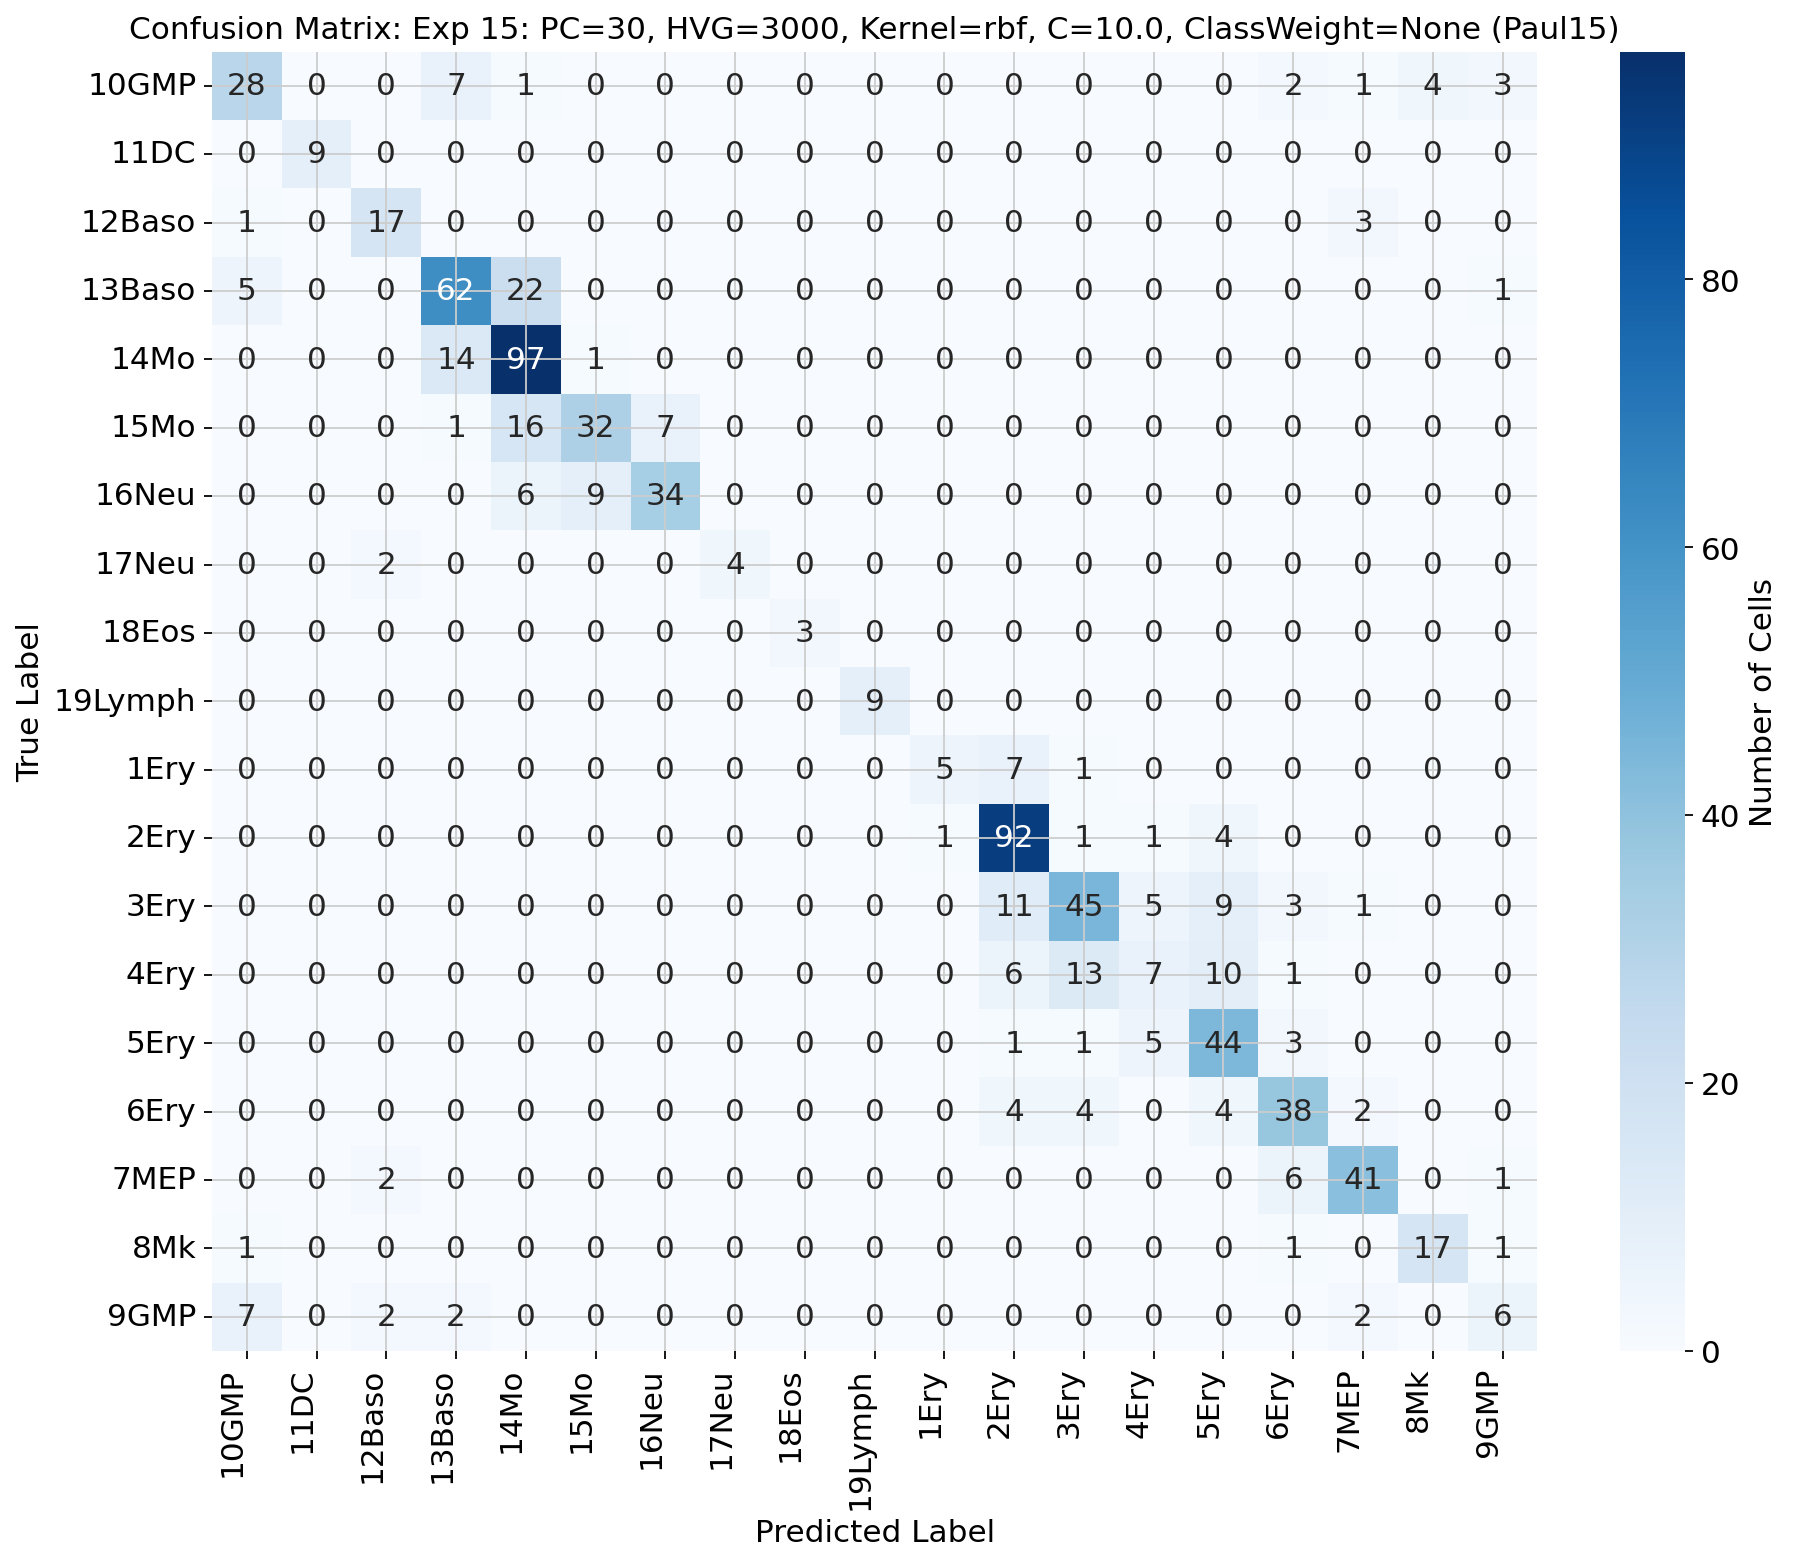


Starting Exp 16: PC=30, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 16: PC=30, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying 

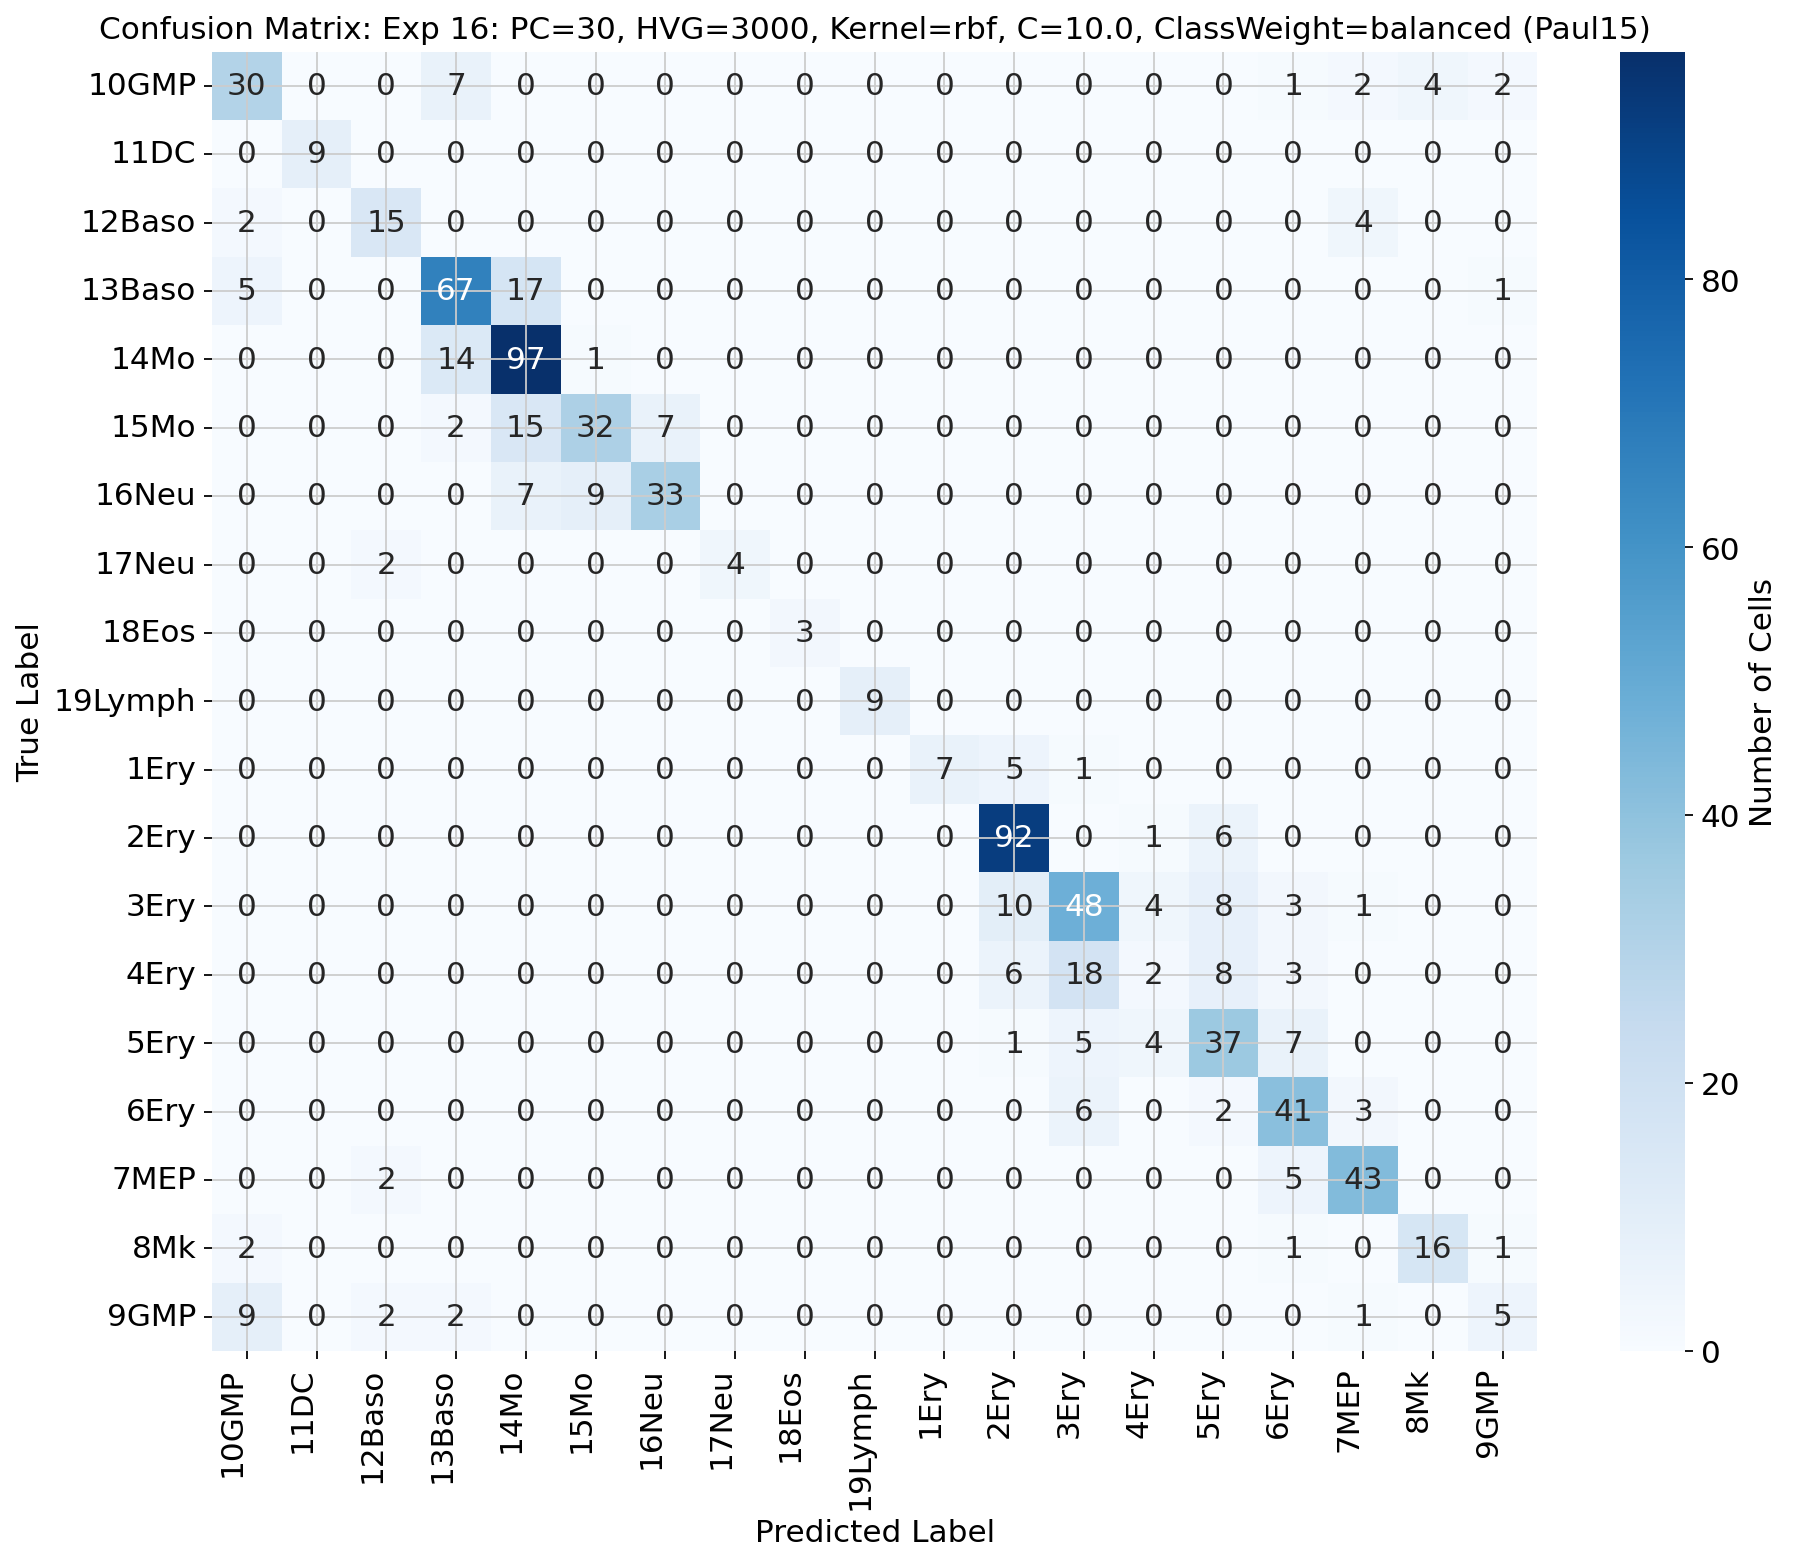


Starting Exp 17: PC=50, HVG=2000, Kernel=linear, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 17: PC=50, HVG=2000, Kernel=linear, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initia

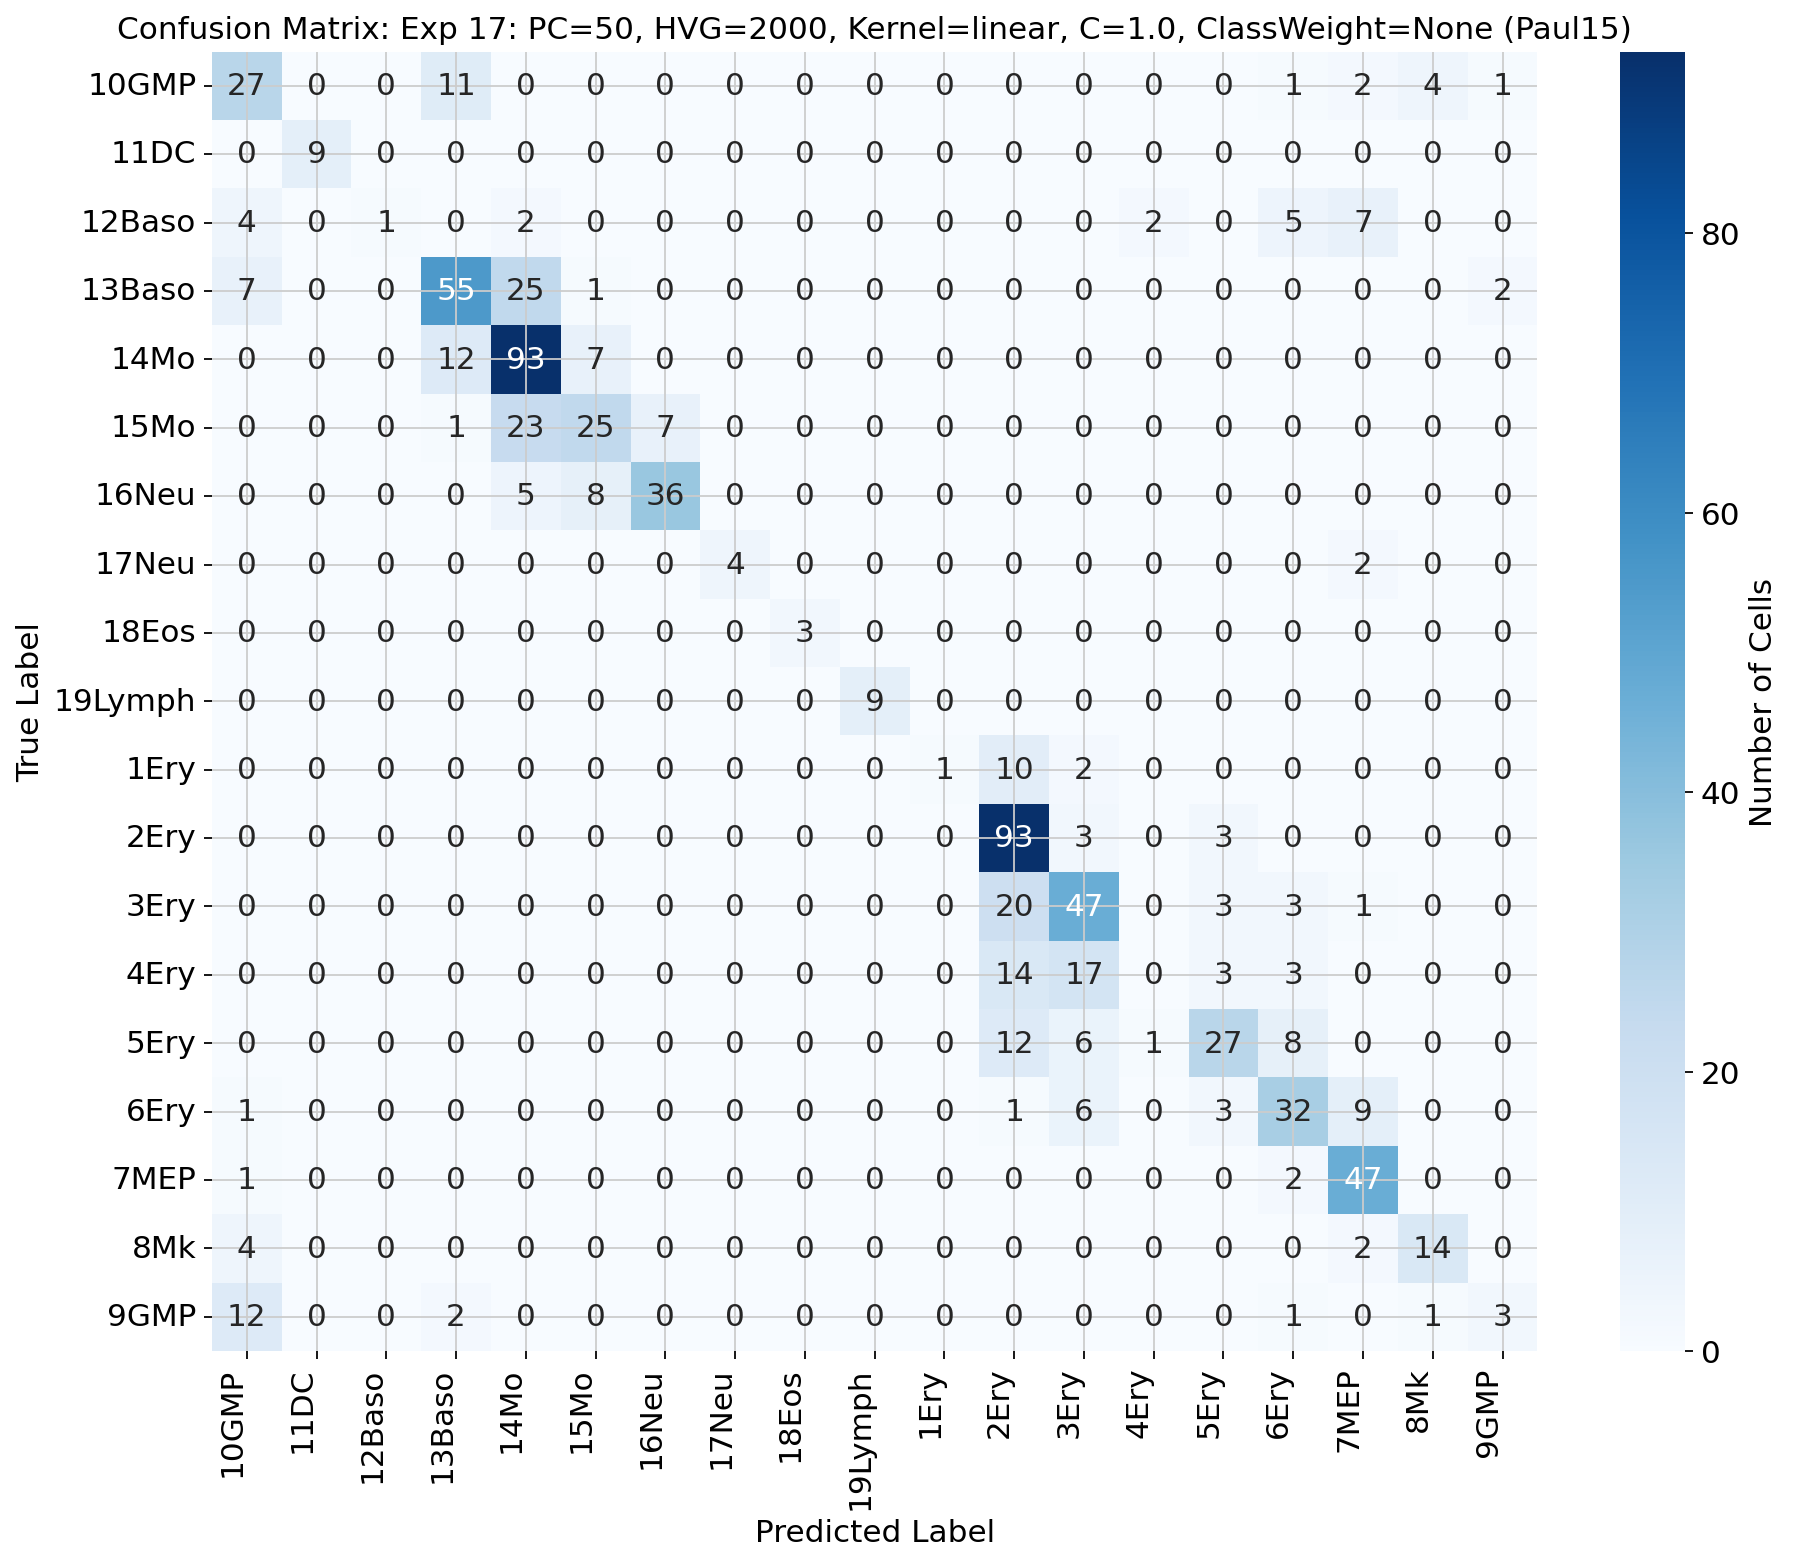


Starting Exp 18: PC=50, HVG=2000, Kernel=linear, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 18: PC=50, HVG=2000, Kernel=linear, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
App

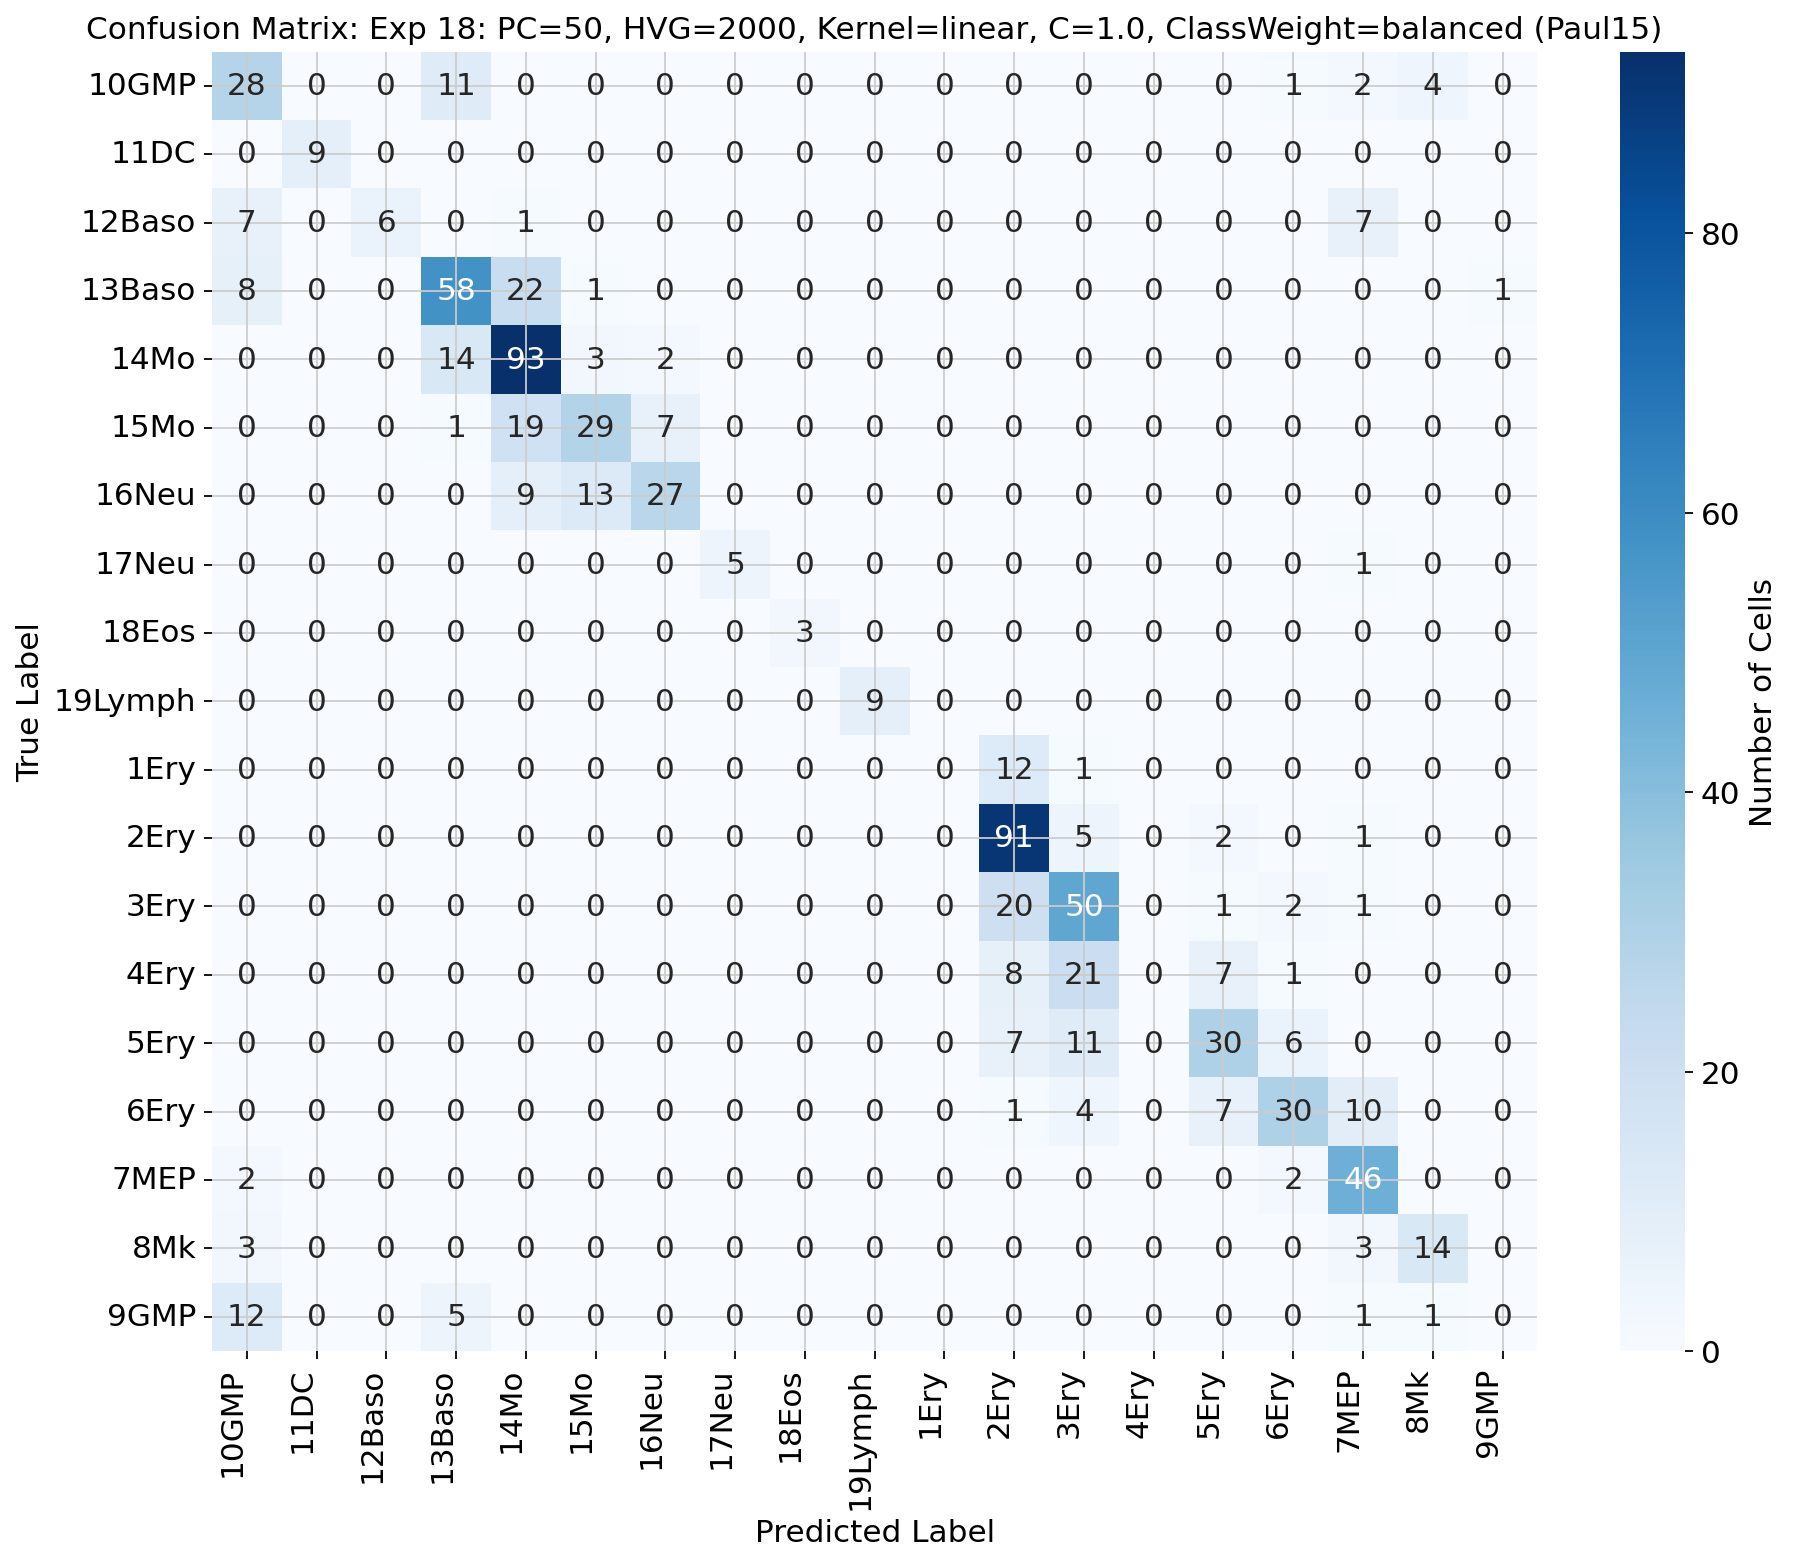


Starting Exp 19: PC=50, HVG=2000, Kernel=linear, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 19: PC=50, HVG=2000, Kernel=linear, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying ini

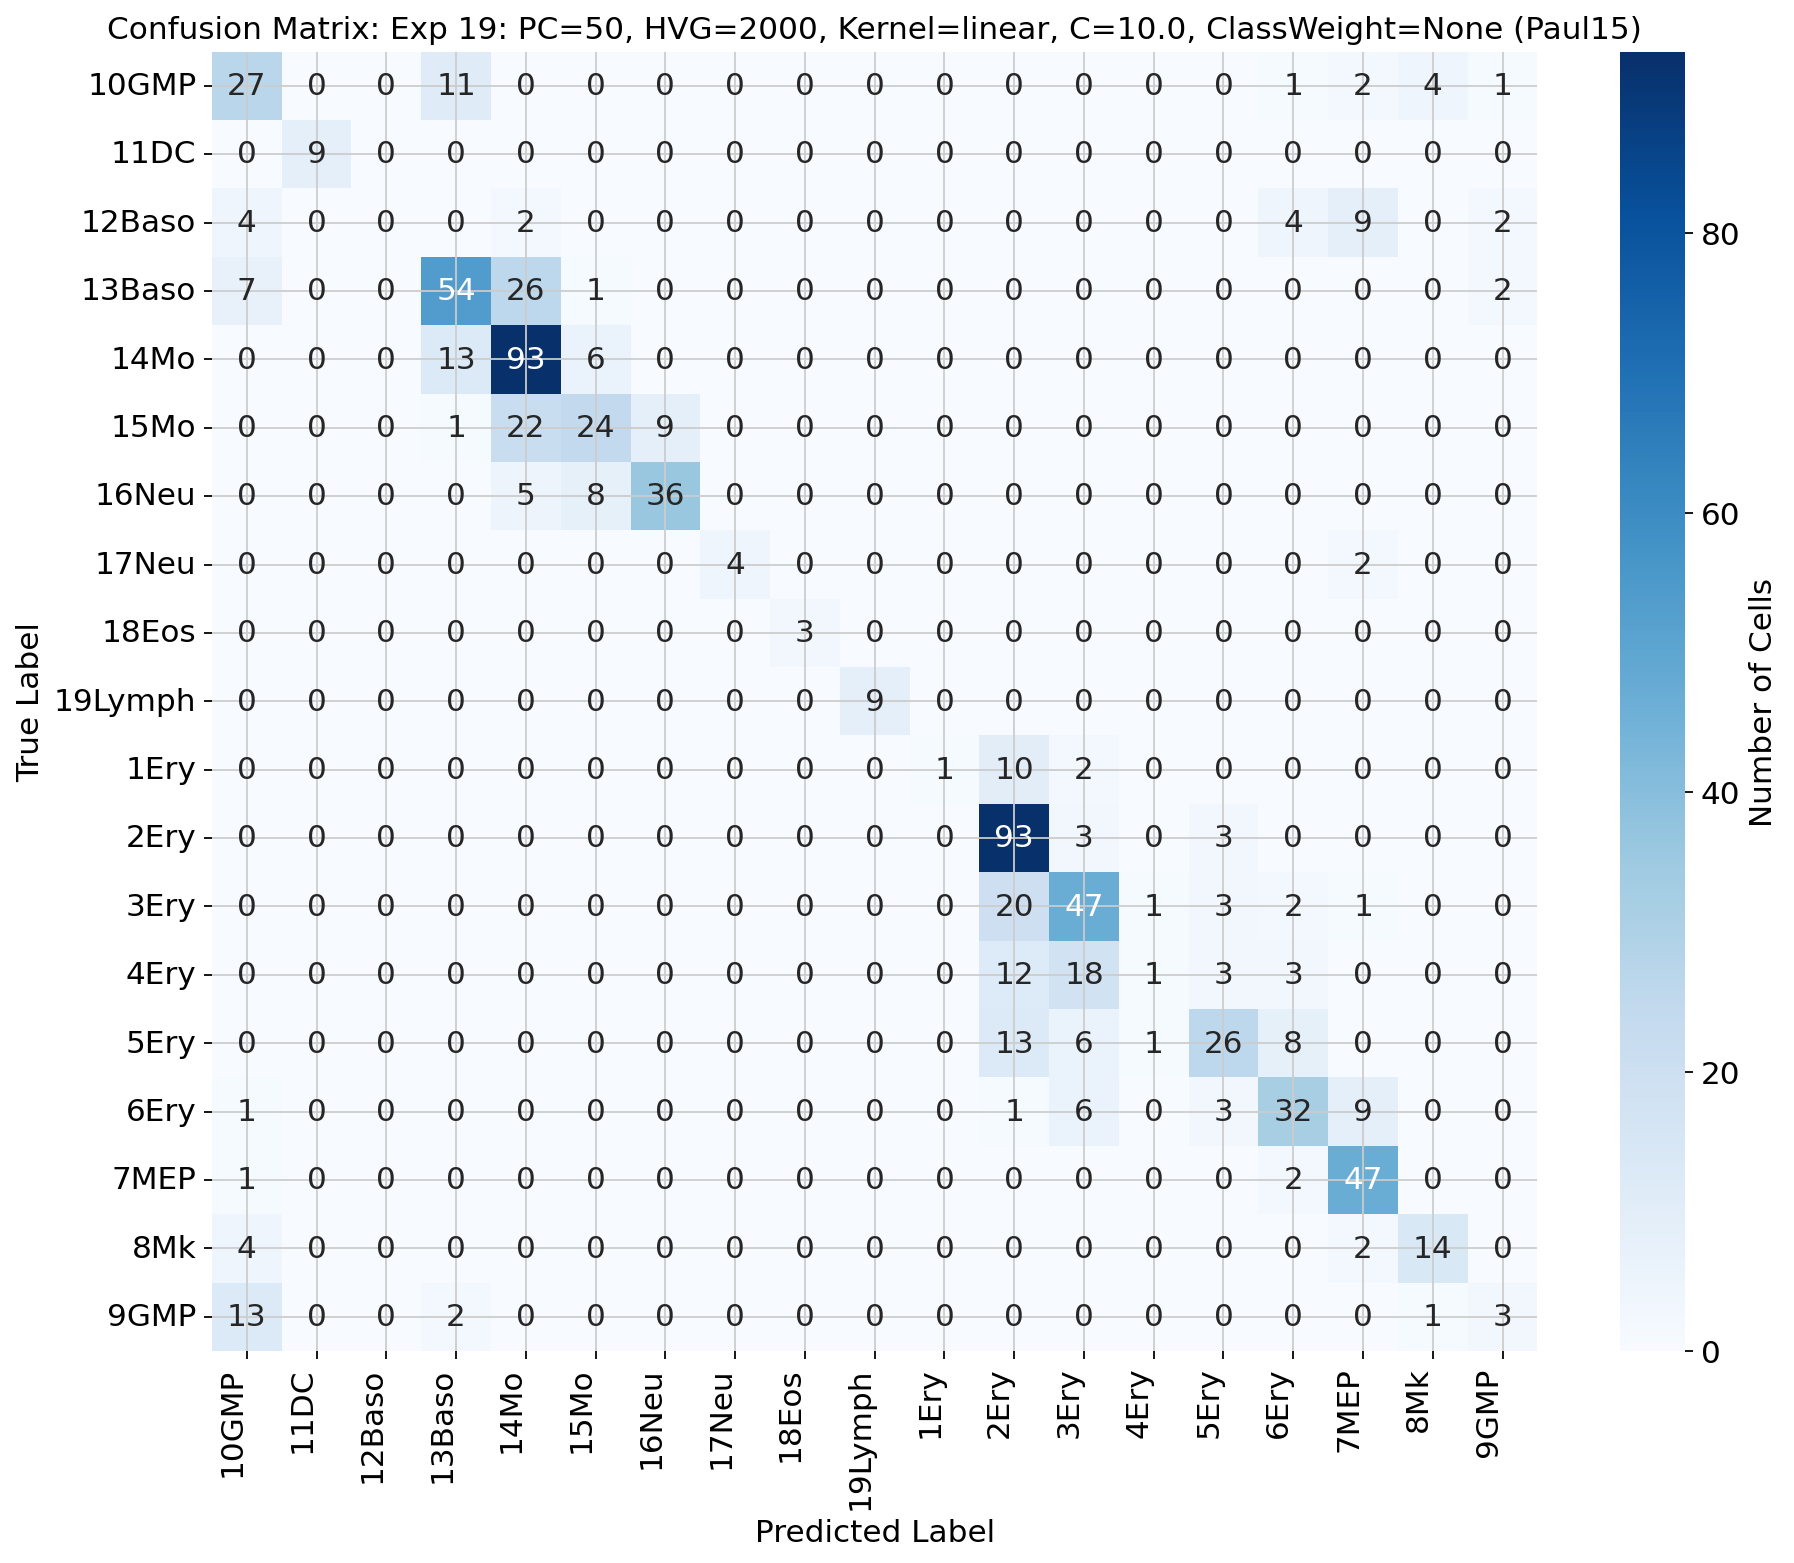


Starting Exp 20: PC=50, HVG=2000, Kernel=linear, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 20: PC=50, HVG=2000, Kernel=linear, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...


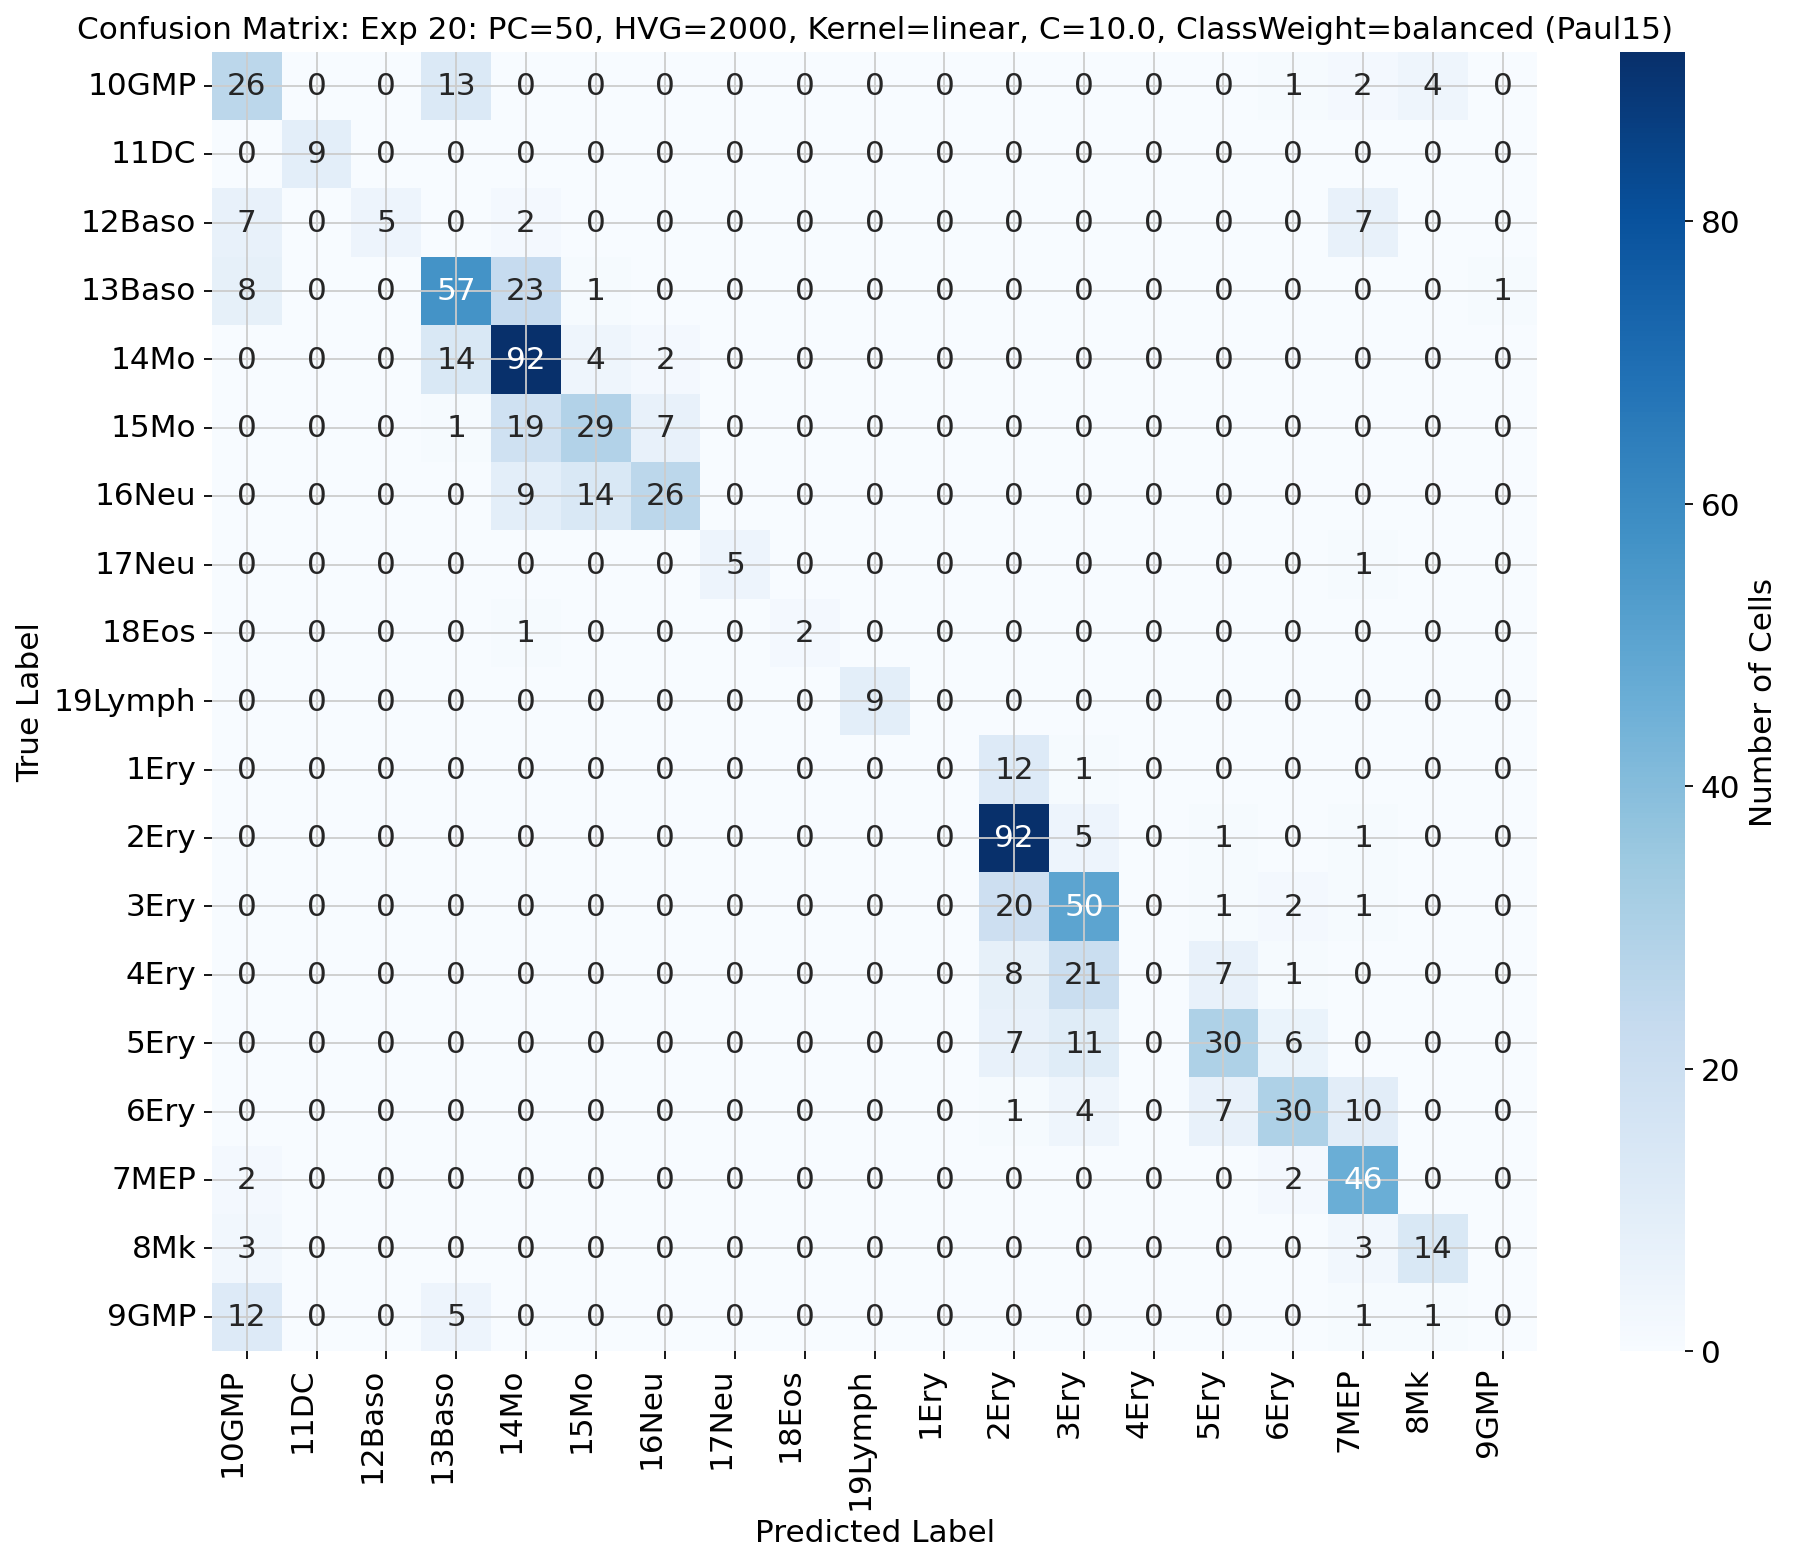


Starting Exp 21: PC=50, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 21: PC=50, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preproc

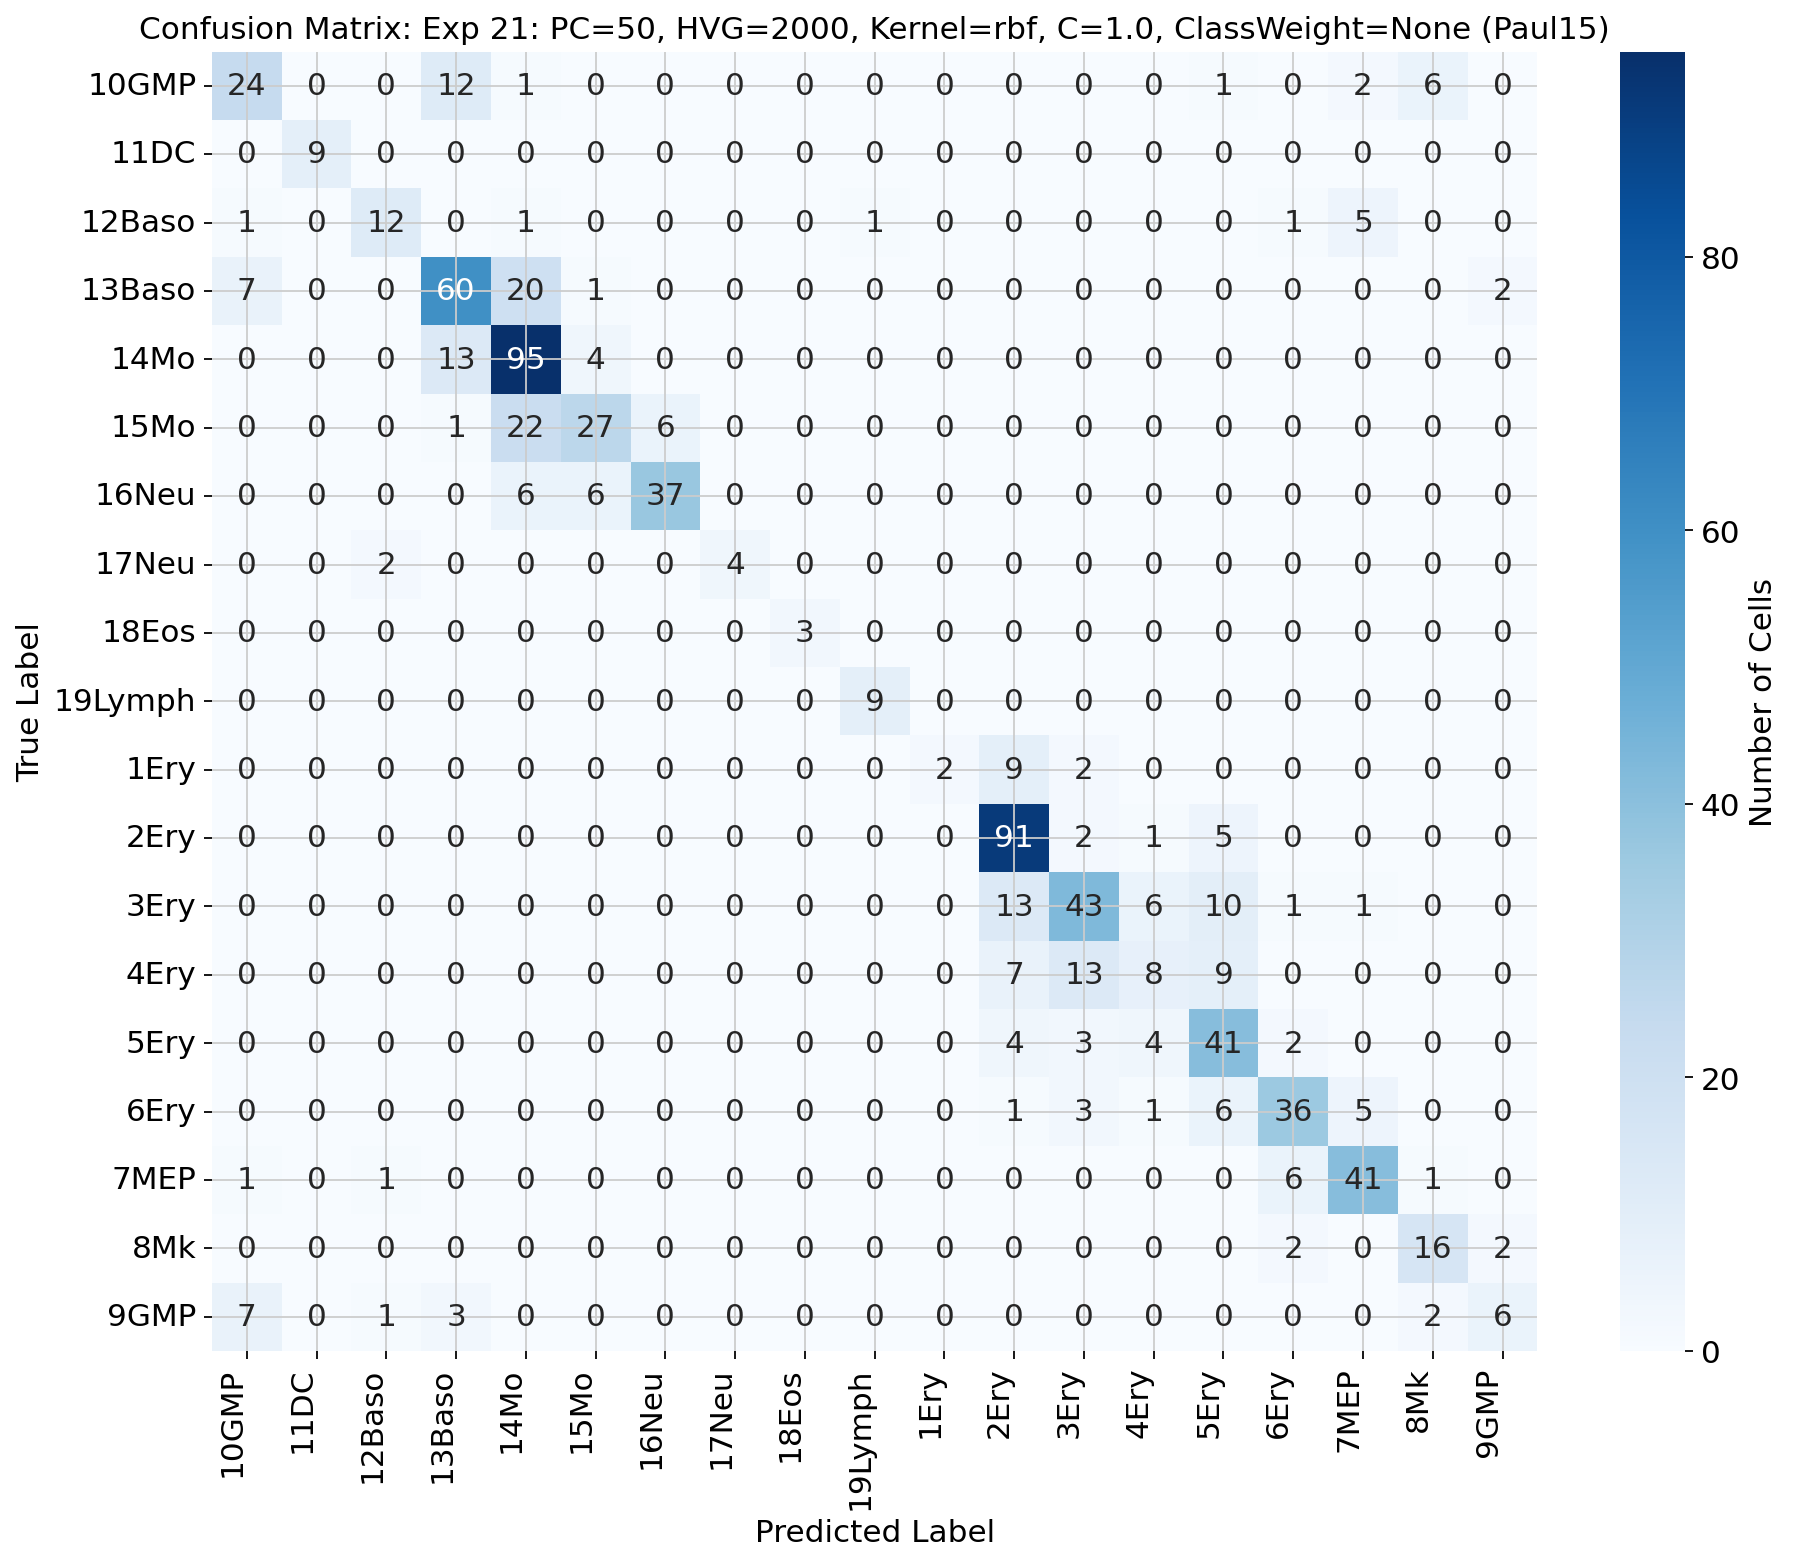


Starting Exp 22: PC=50, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 22: PC=50, HVG=2000, Kernel=rbf, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying ini

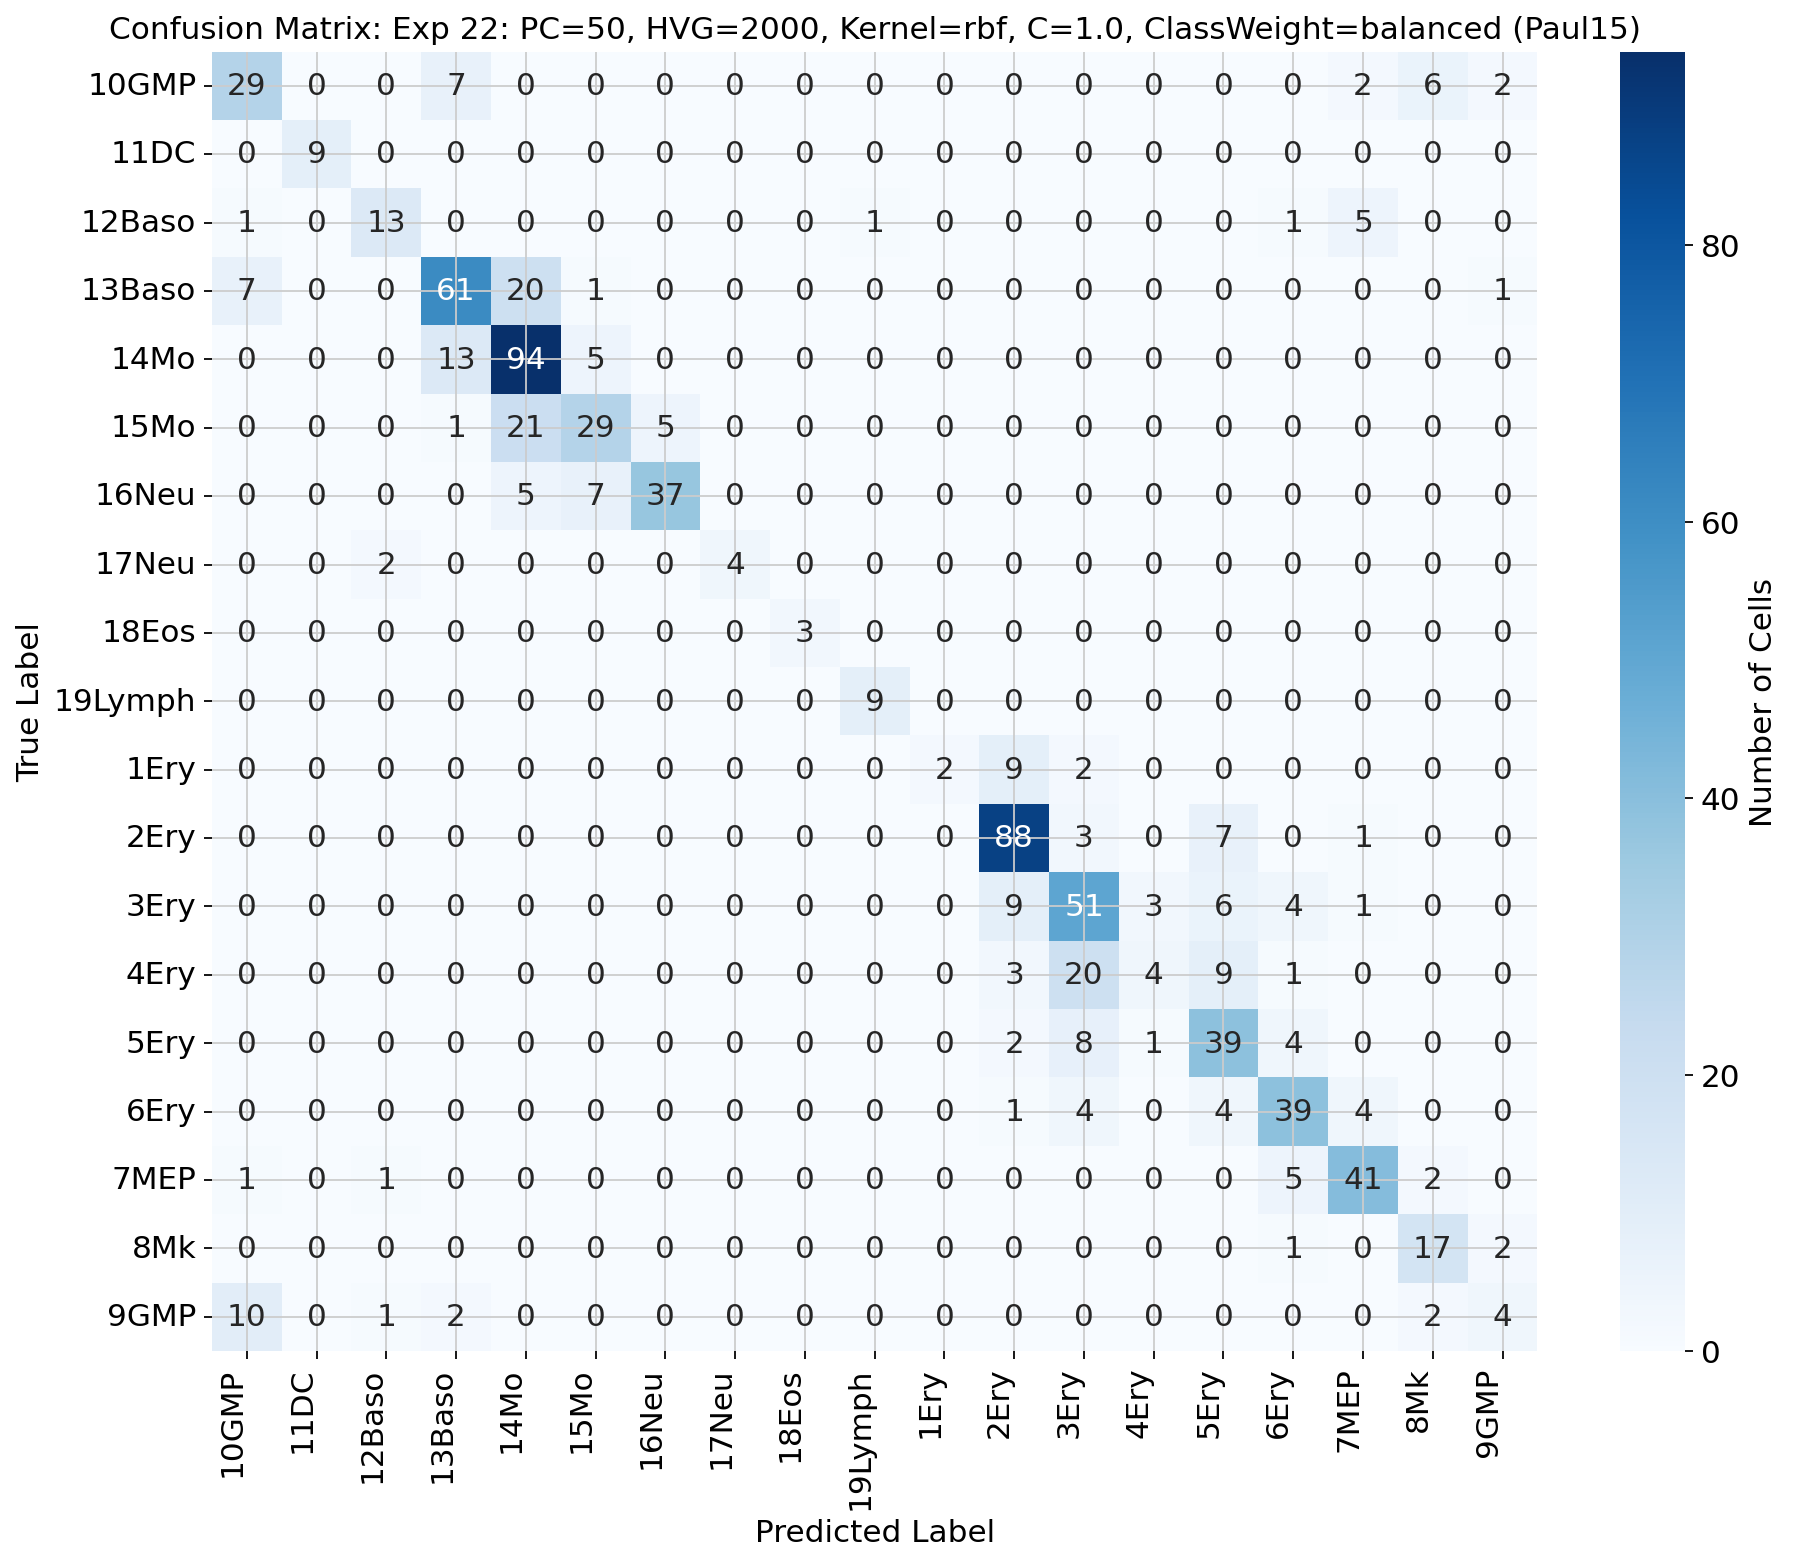


Starting Exp 23: PC=50, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 23: PC=50, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial prep

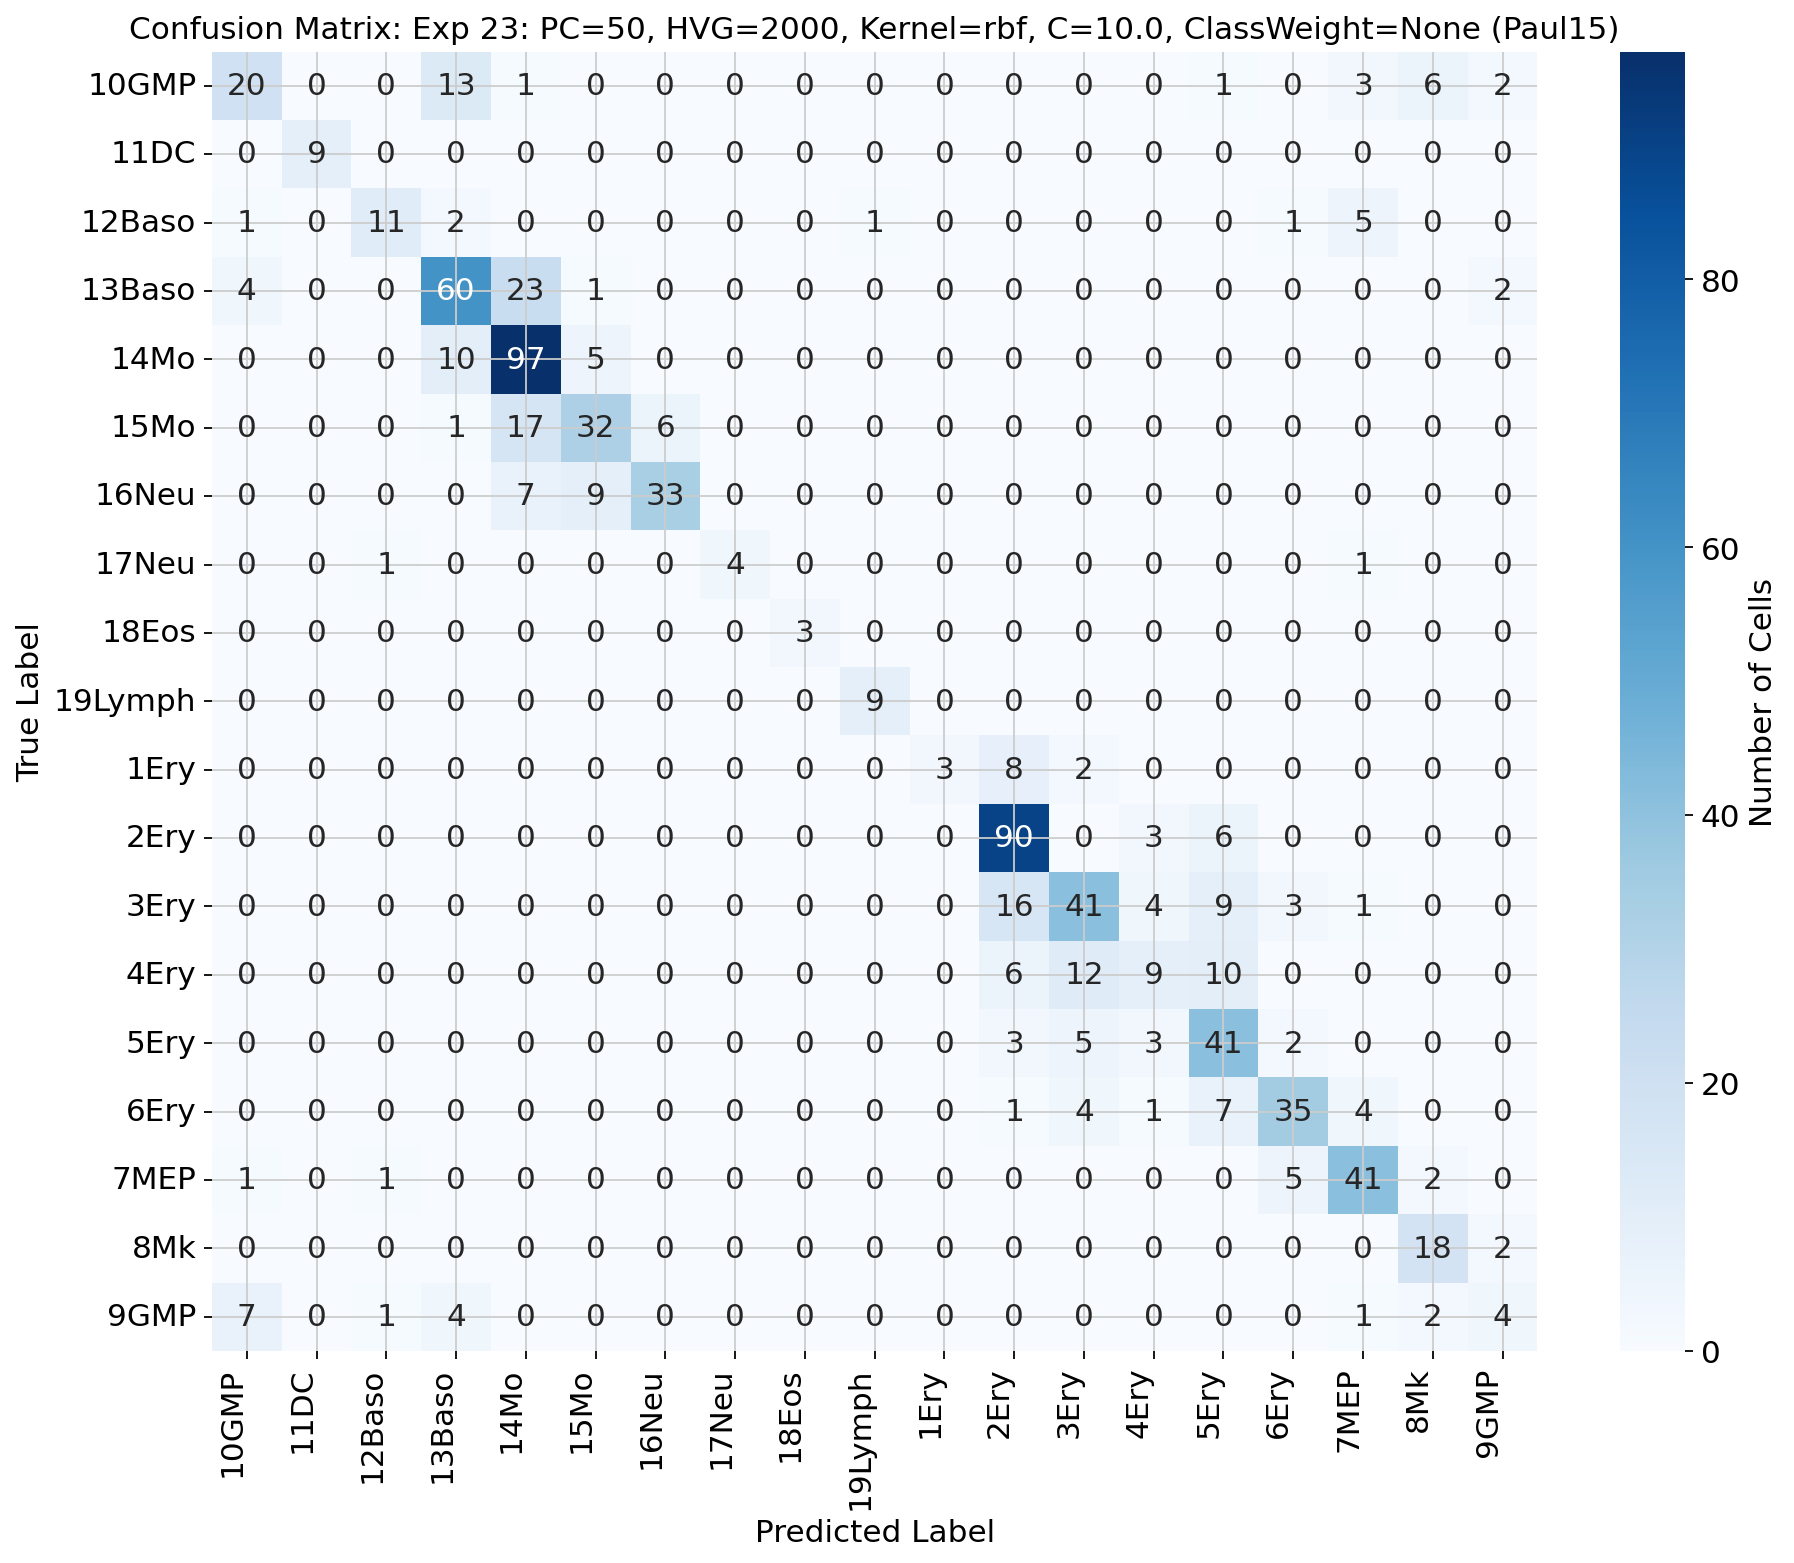


Starting Exp 24: PC=50, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 24: PC=50, HVG=2000, Kernel=rbf, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 2000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying 

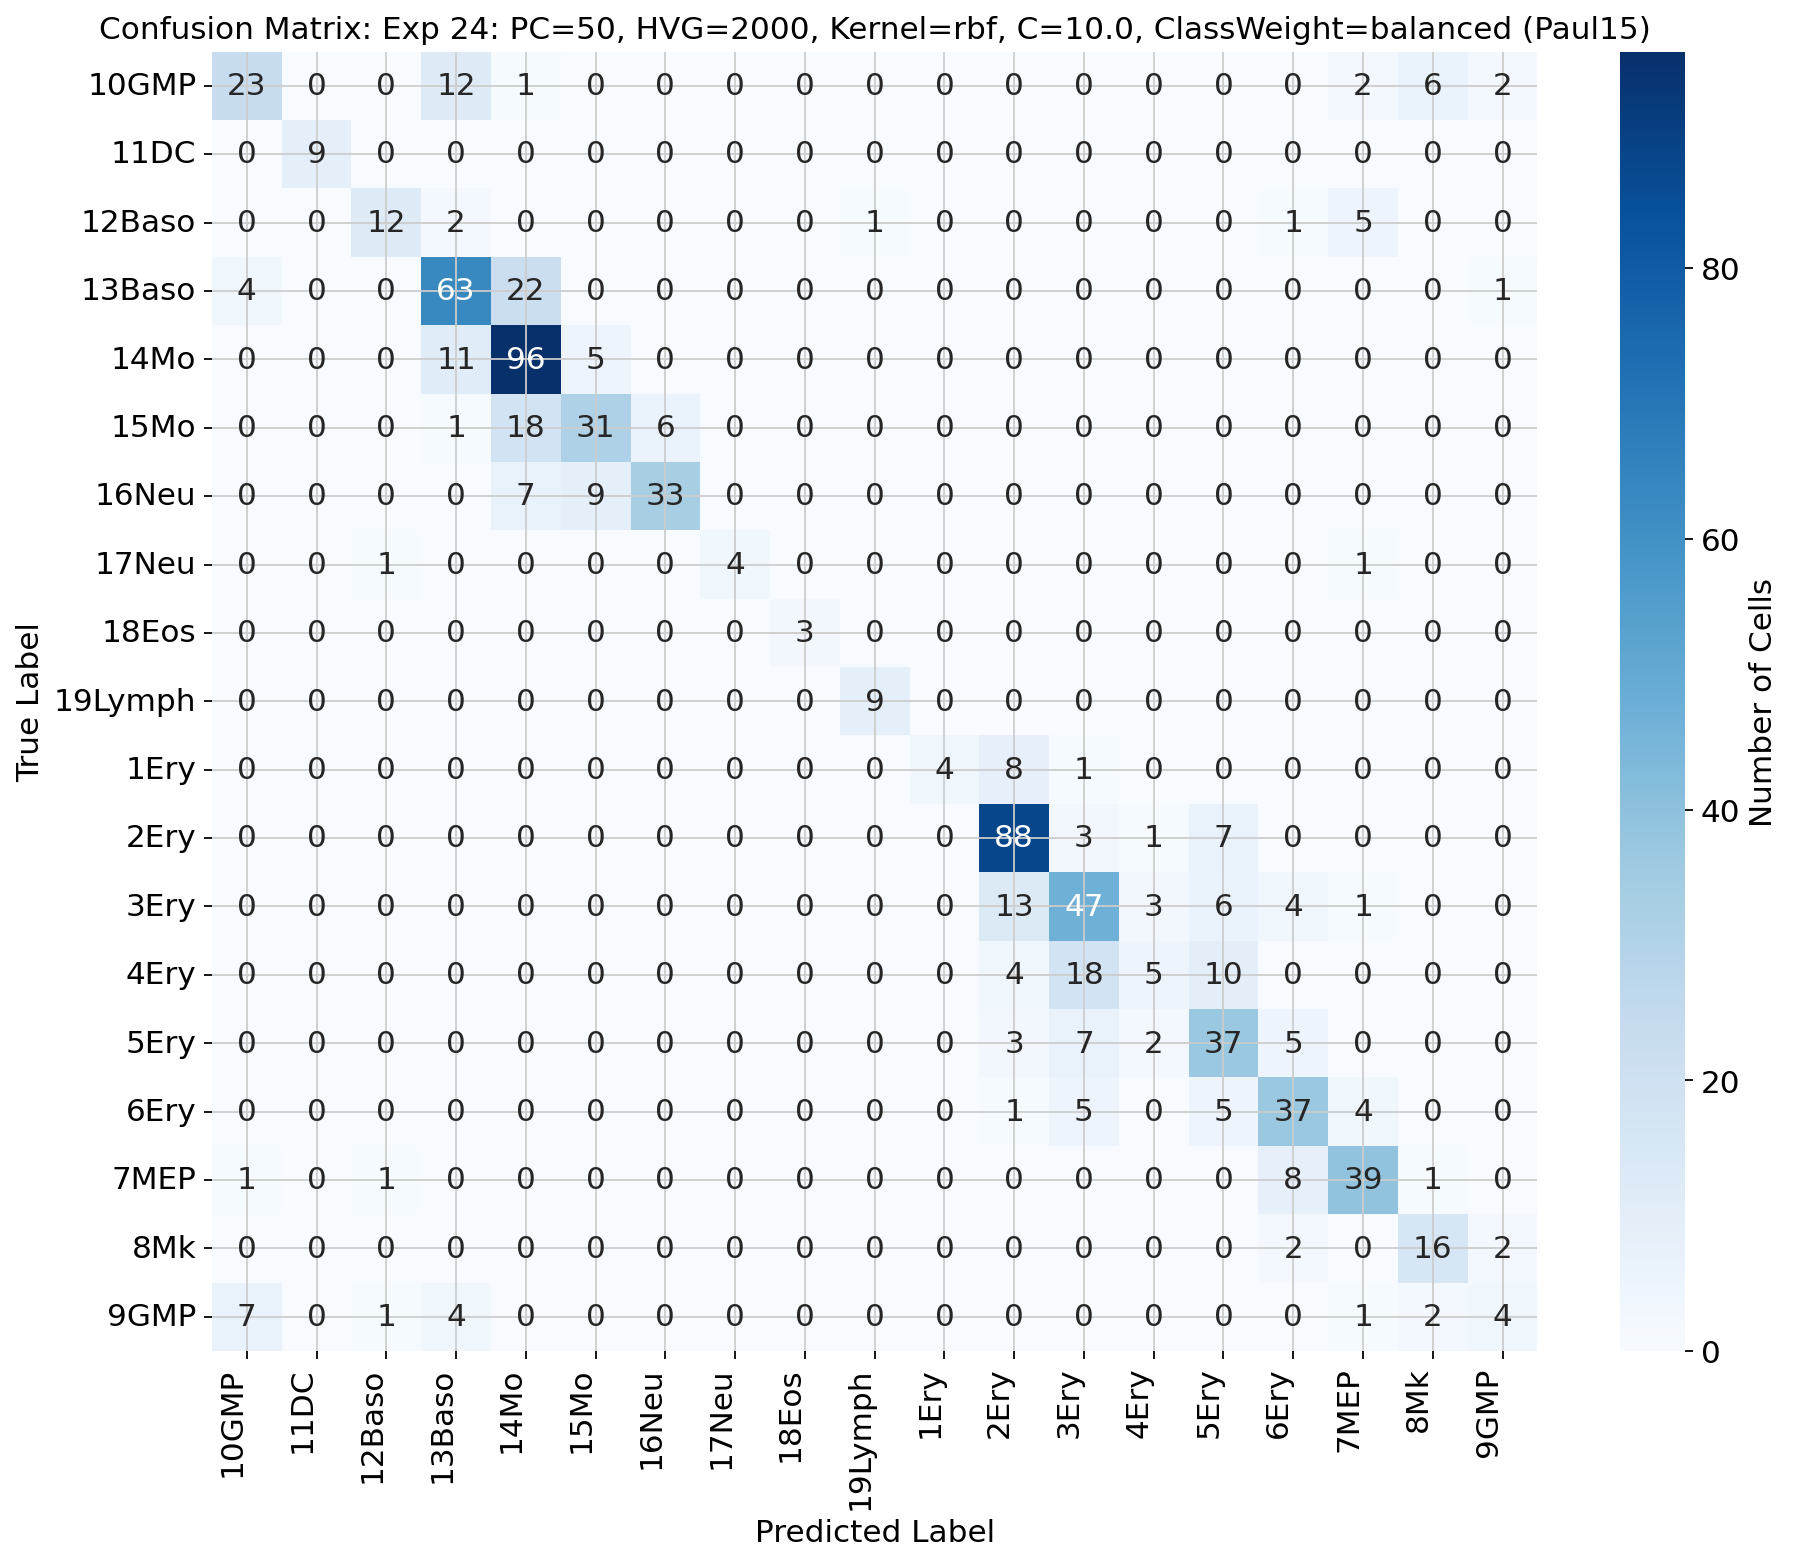


Starting Exp 25: PC=50, HVG=3000, Kernel=linear, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 25: PC=50, HVG=3000, Kernel=linear, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initia

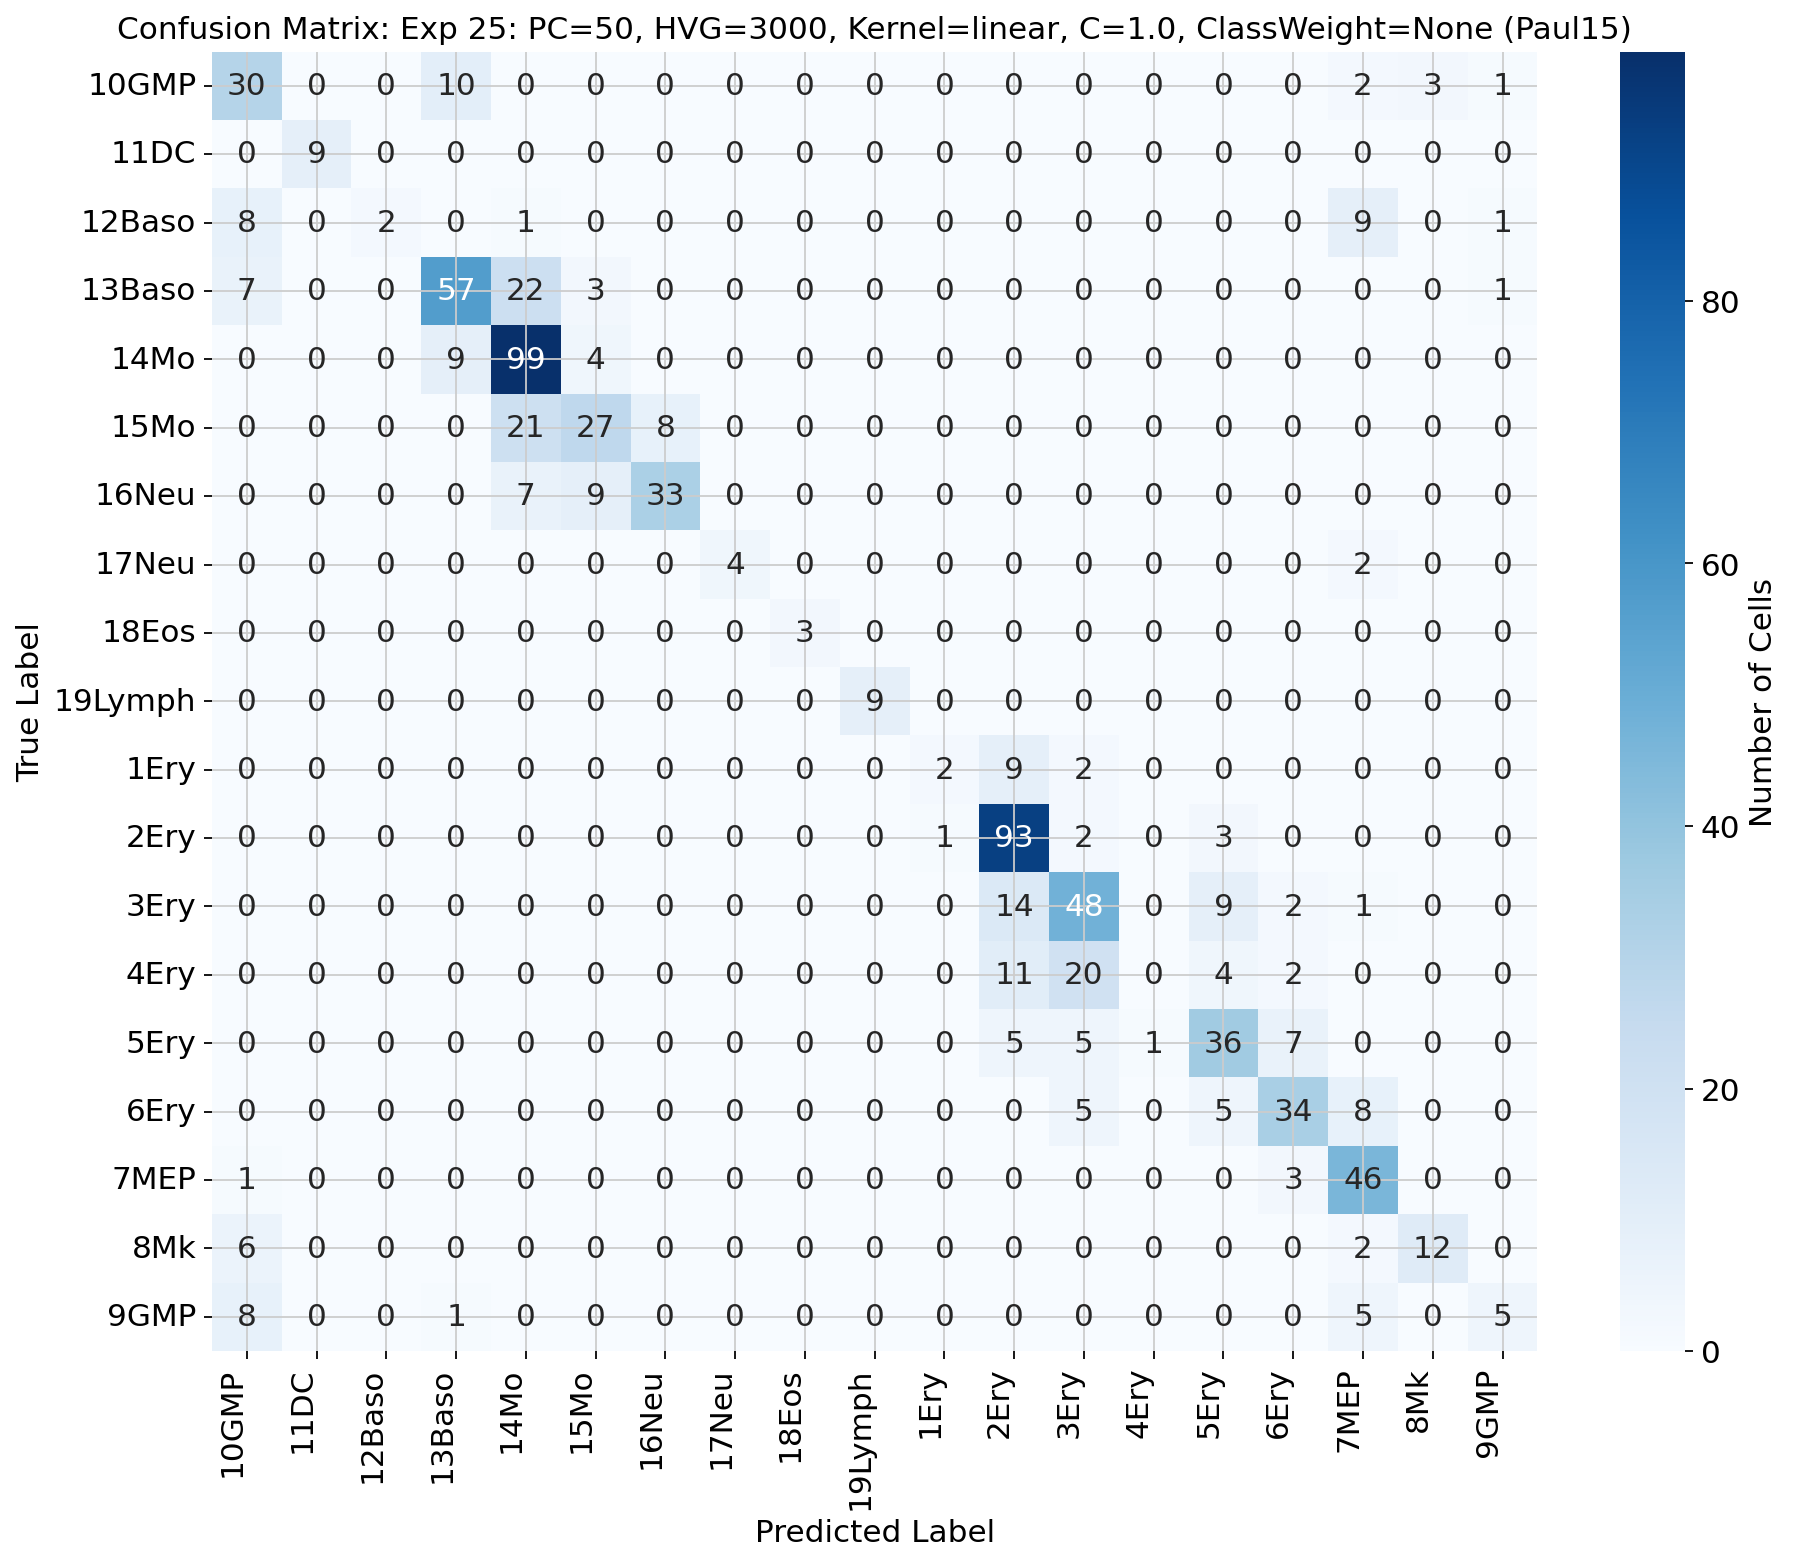


Starting Exp 26: PC=50, HVG=3000, Kernel=linear, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 26: PC=50, HVG=3000, Kernel=linear, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
App

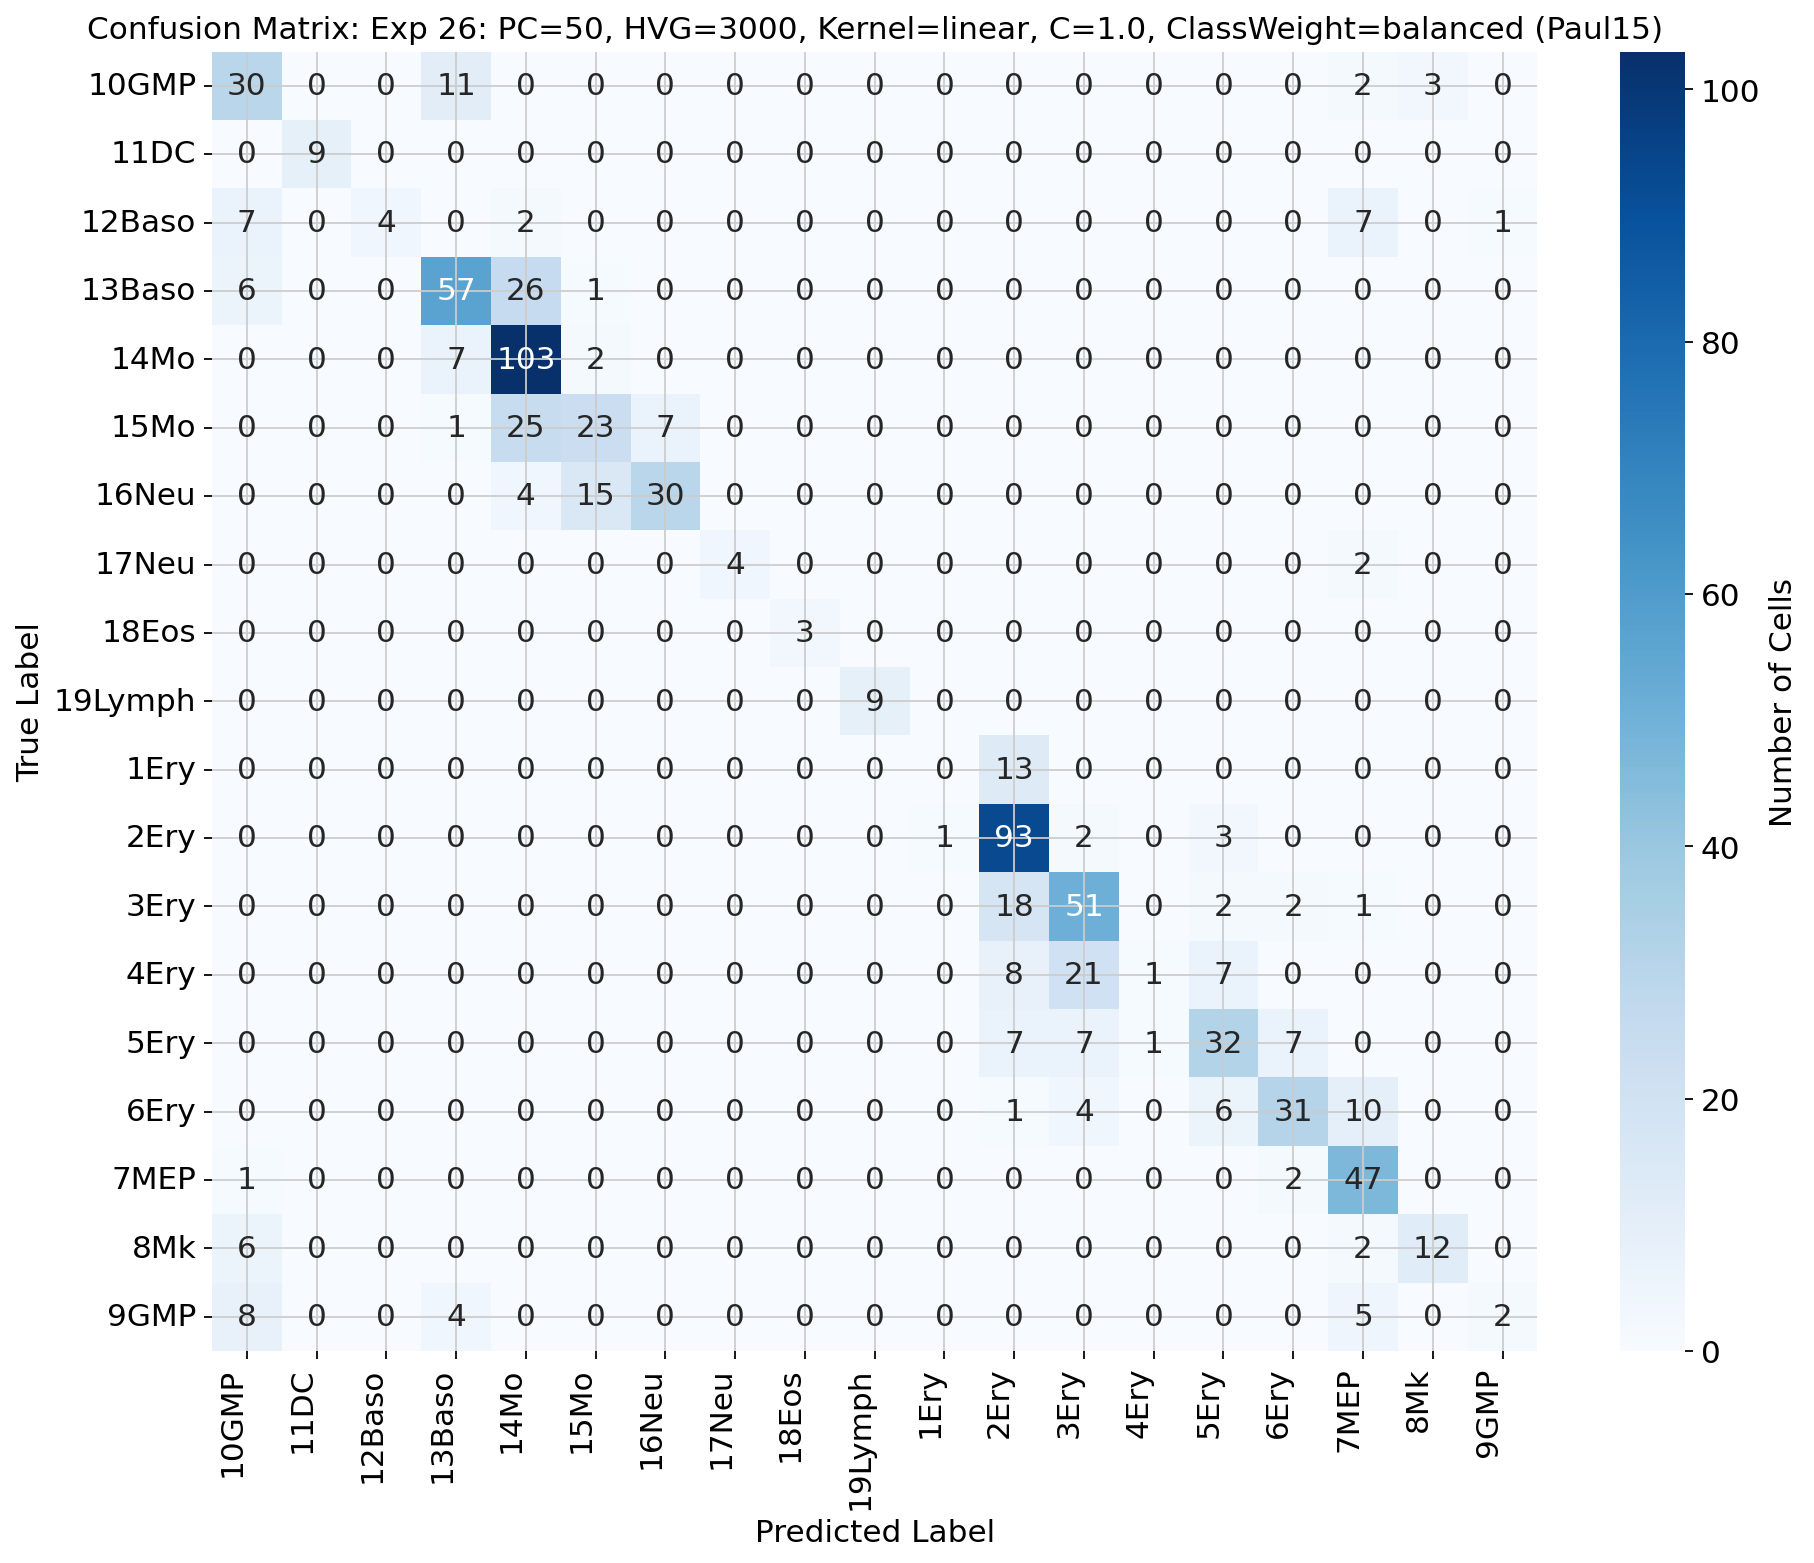


Starting Exp 27: PC=50, HVG=3000, Kernel=linear, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 27: PC=50, HVG=3000, Kernel=linear, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying ini

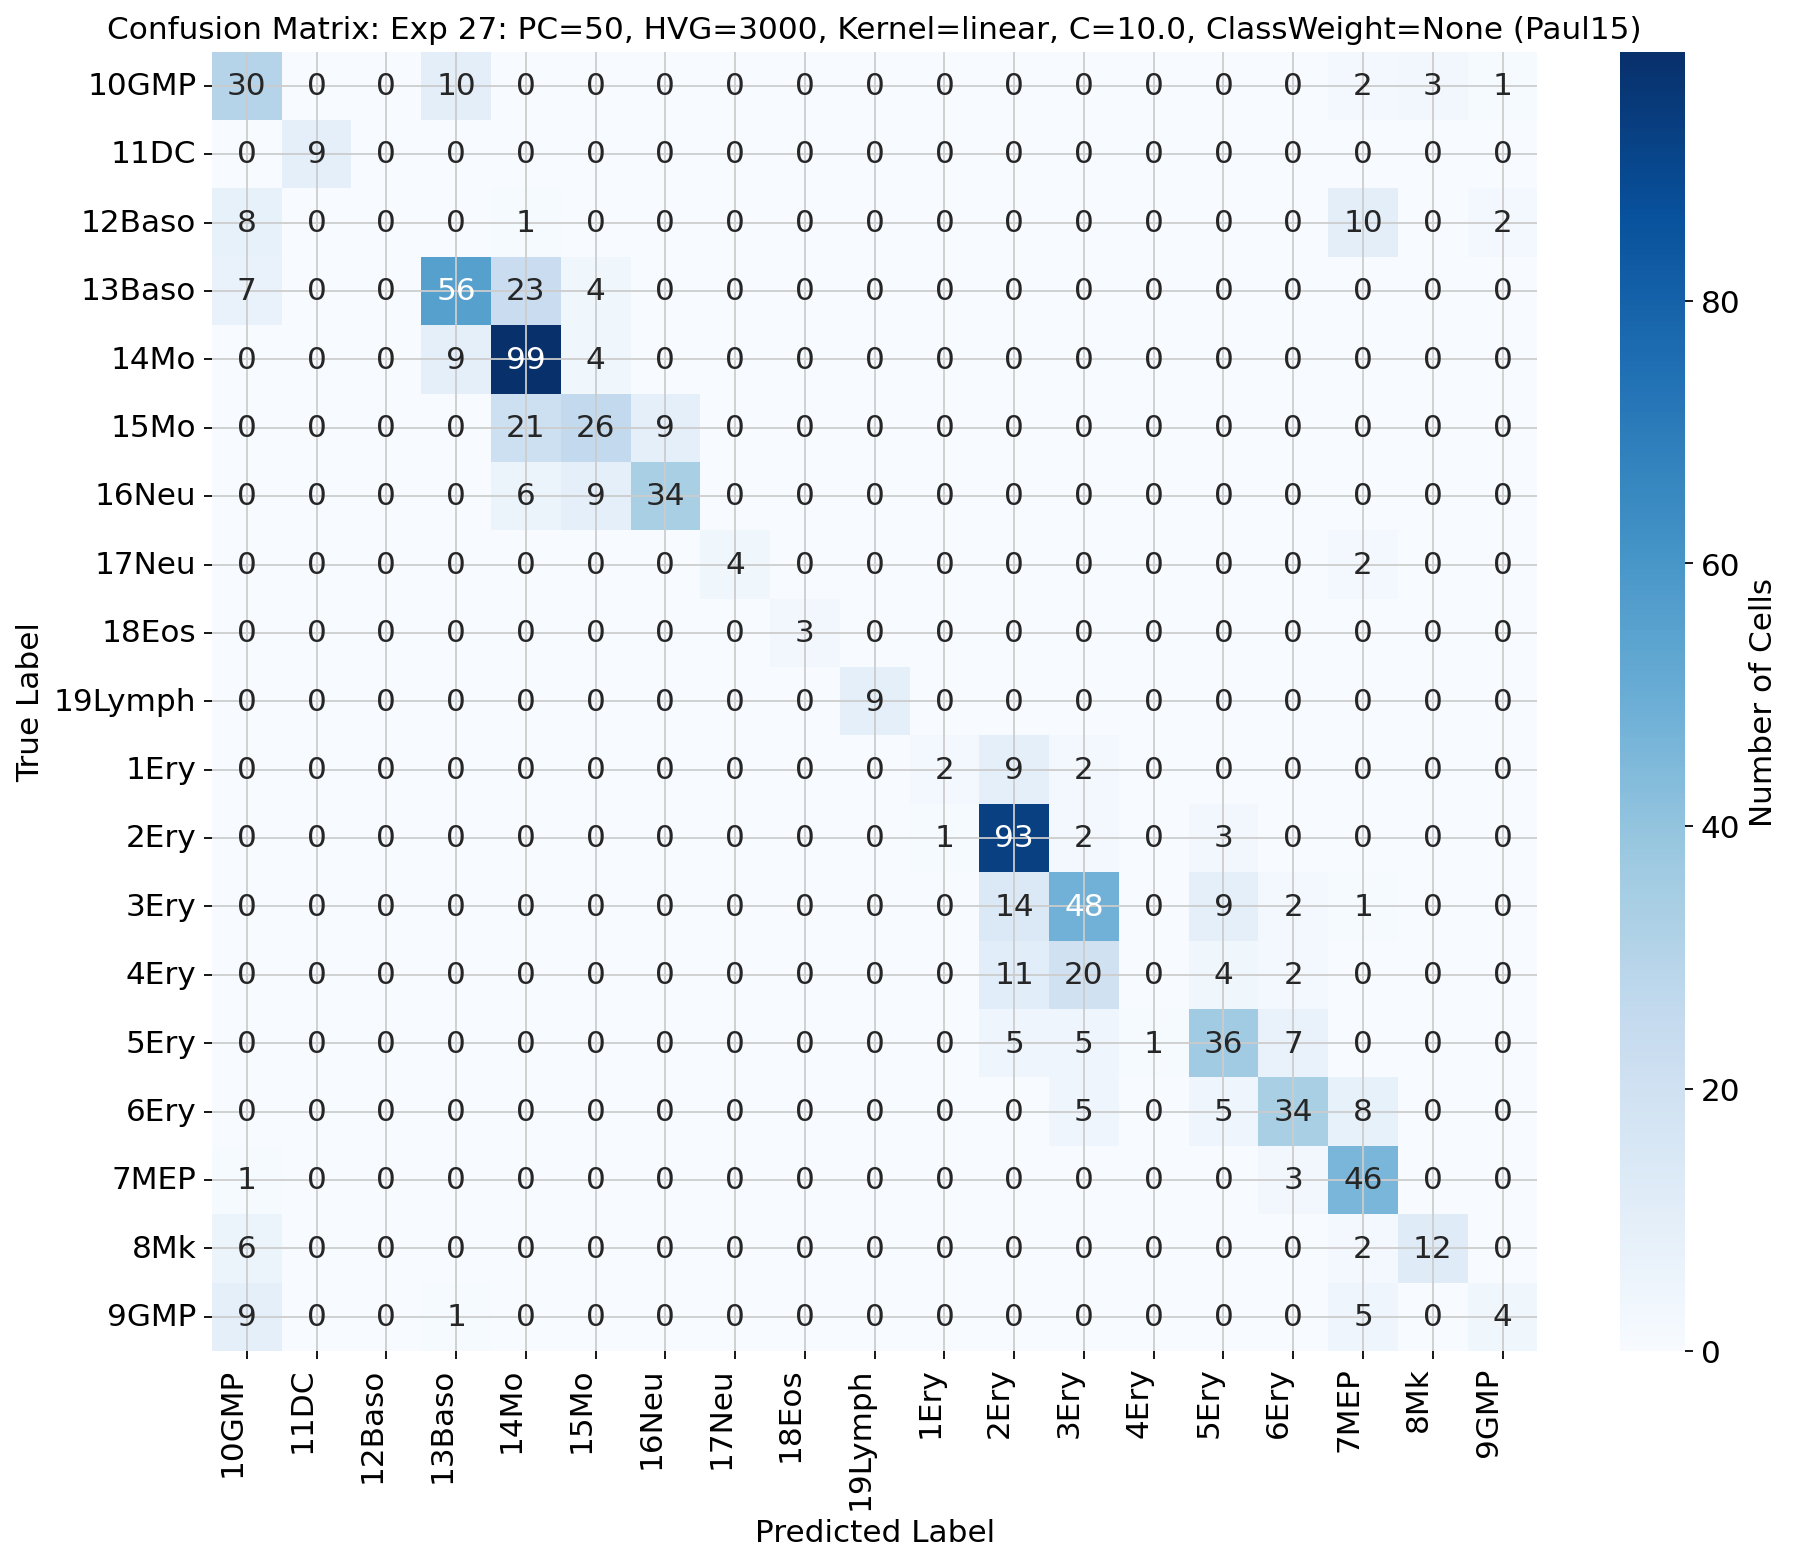


Starting Exp 28: PC=50, HVG=3000, Kernel=linear, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 28: PC=50, HVG=3000, Kernel=linear, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='linear', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...


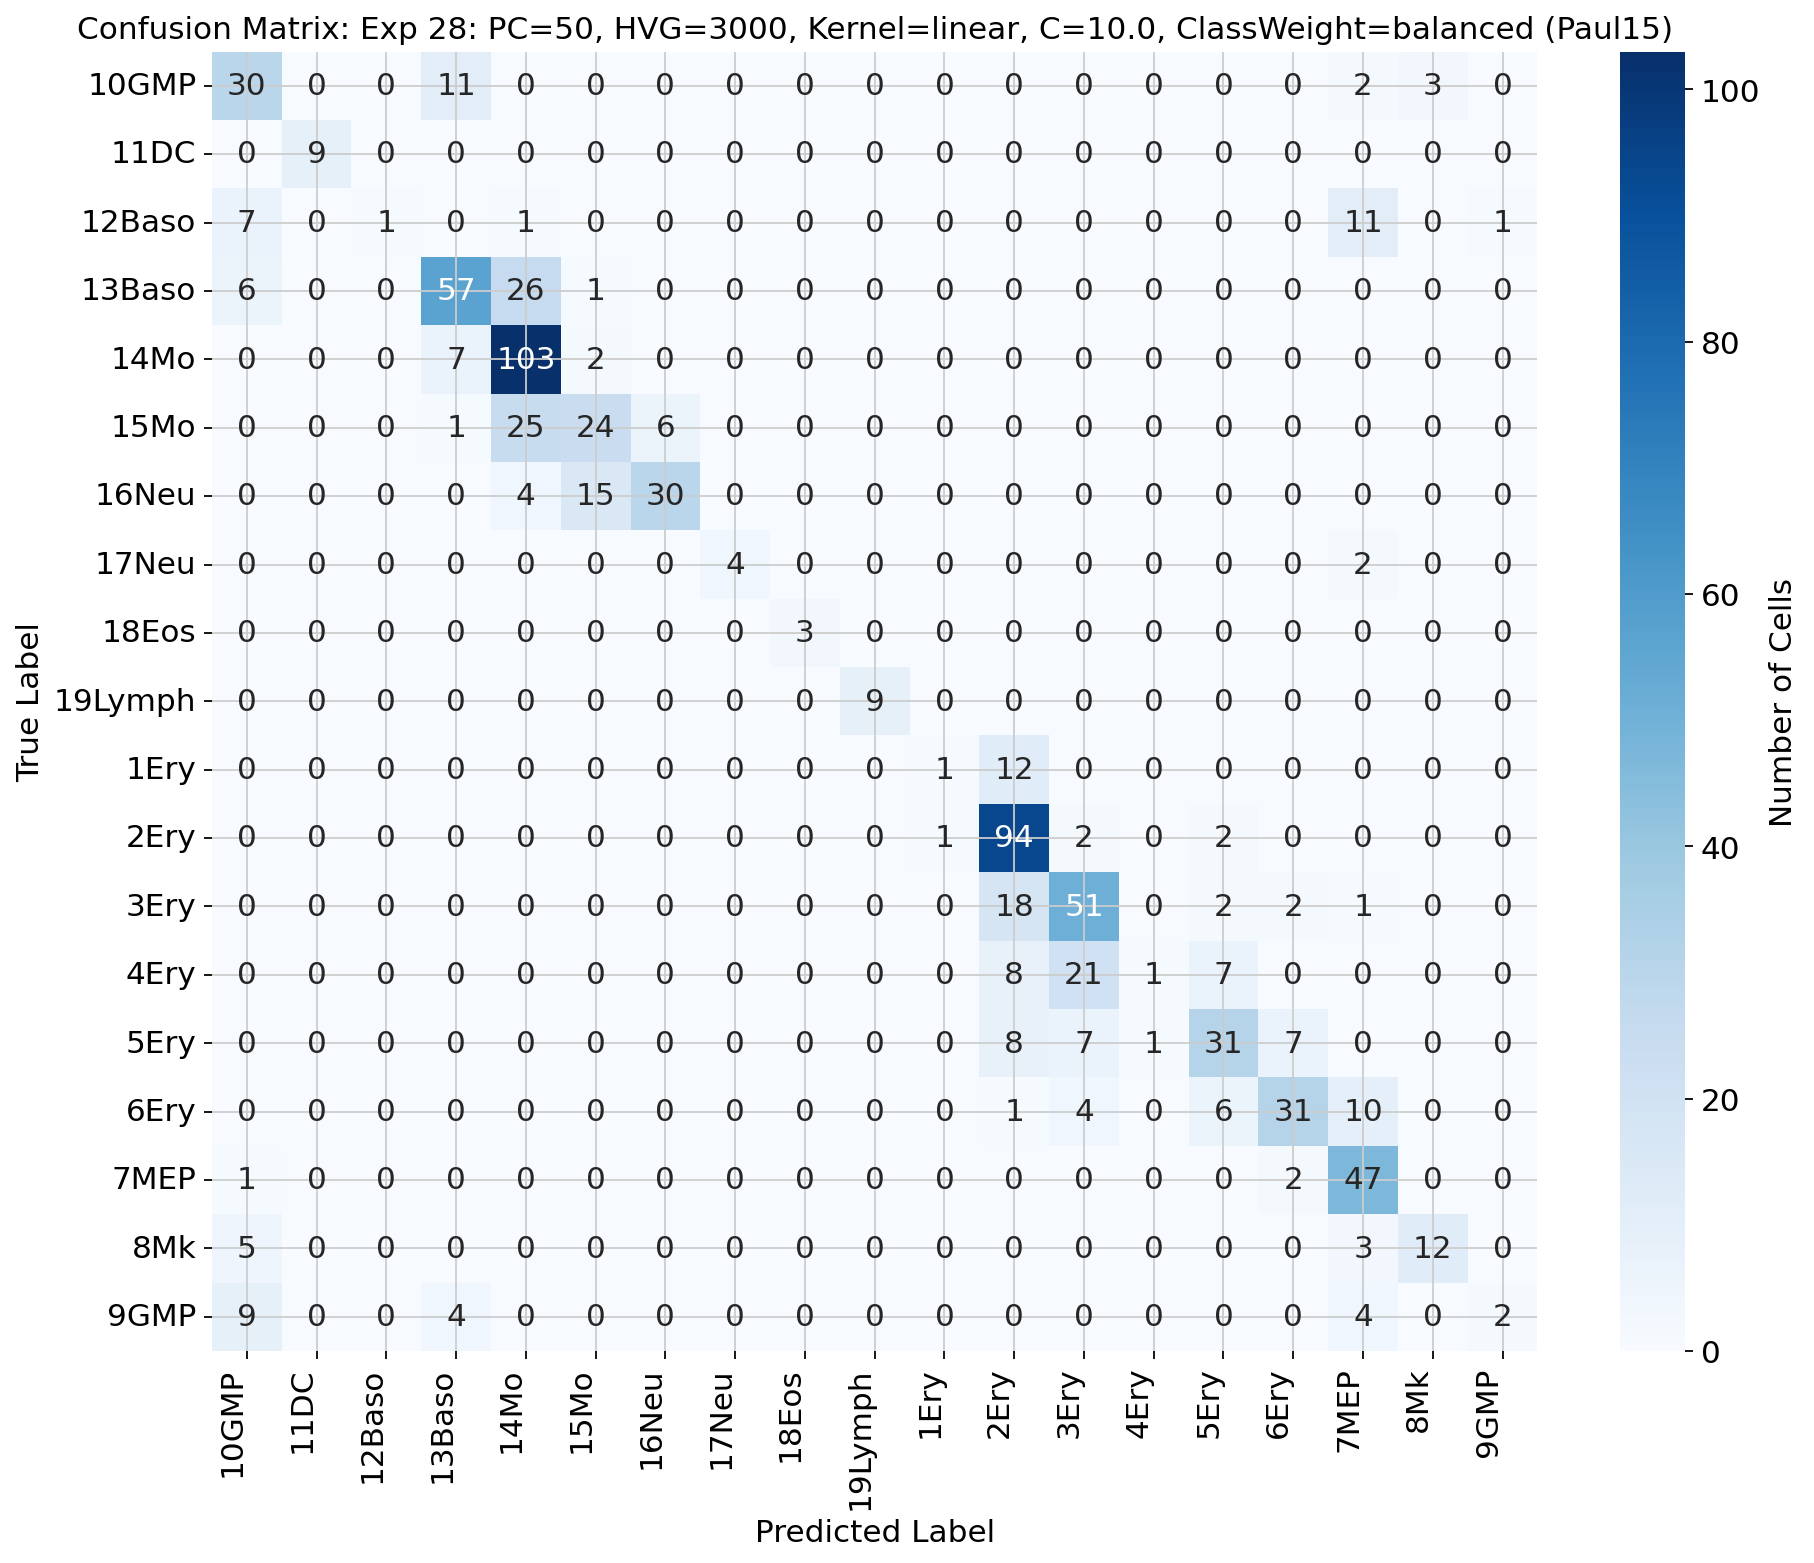


Starting Exp 29: PC=50, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 29: PC=50, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preproc

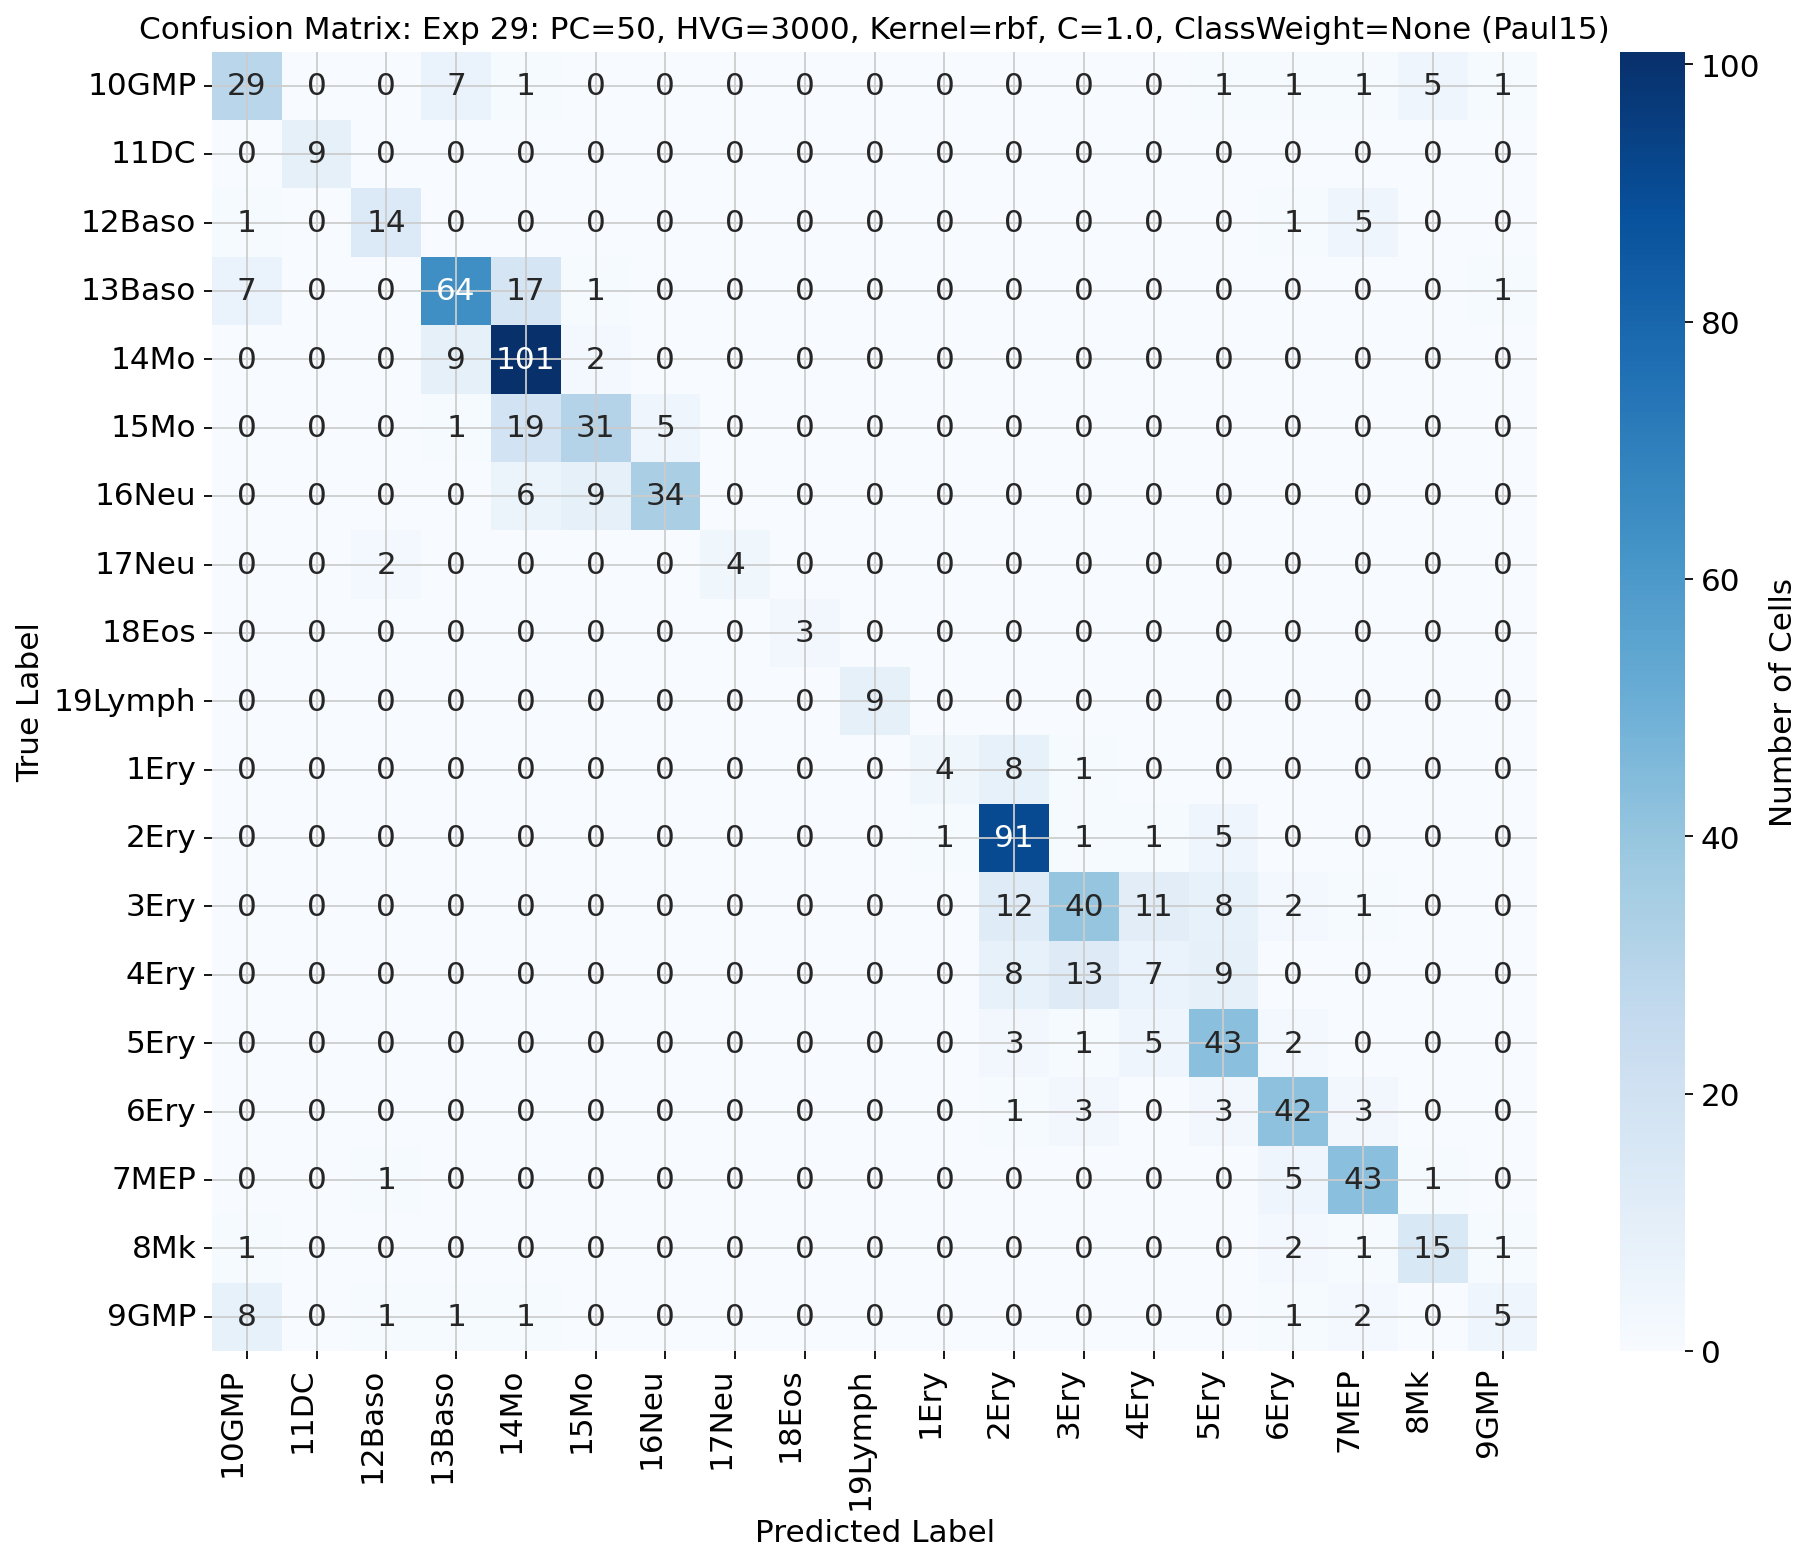


Starting Exp 30: PC=50, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 30: PC=50, HVG=3000, Kernel=rbf, C=1.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=1.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying ini

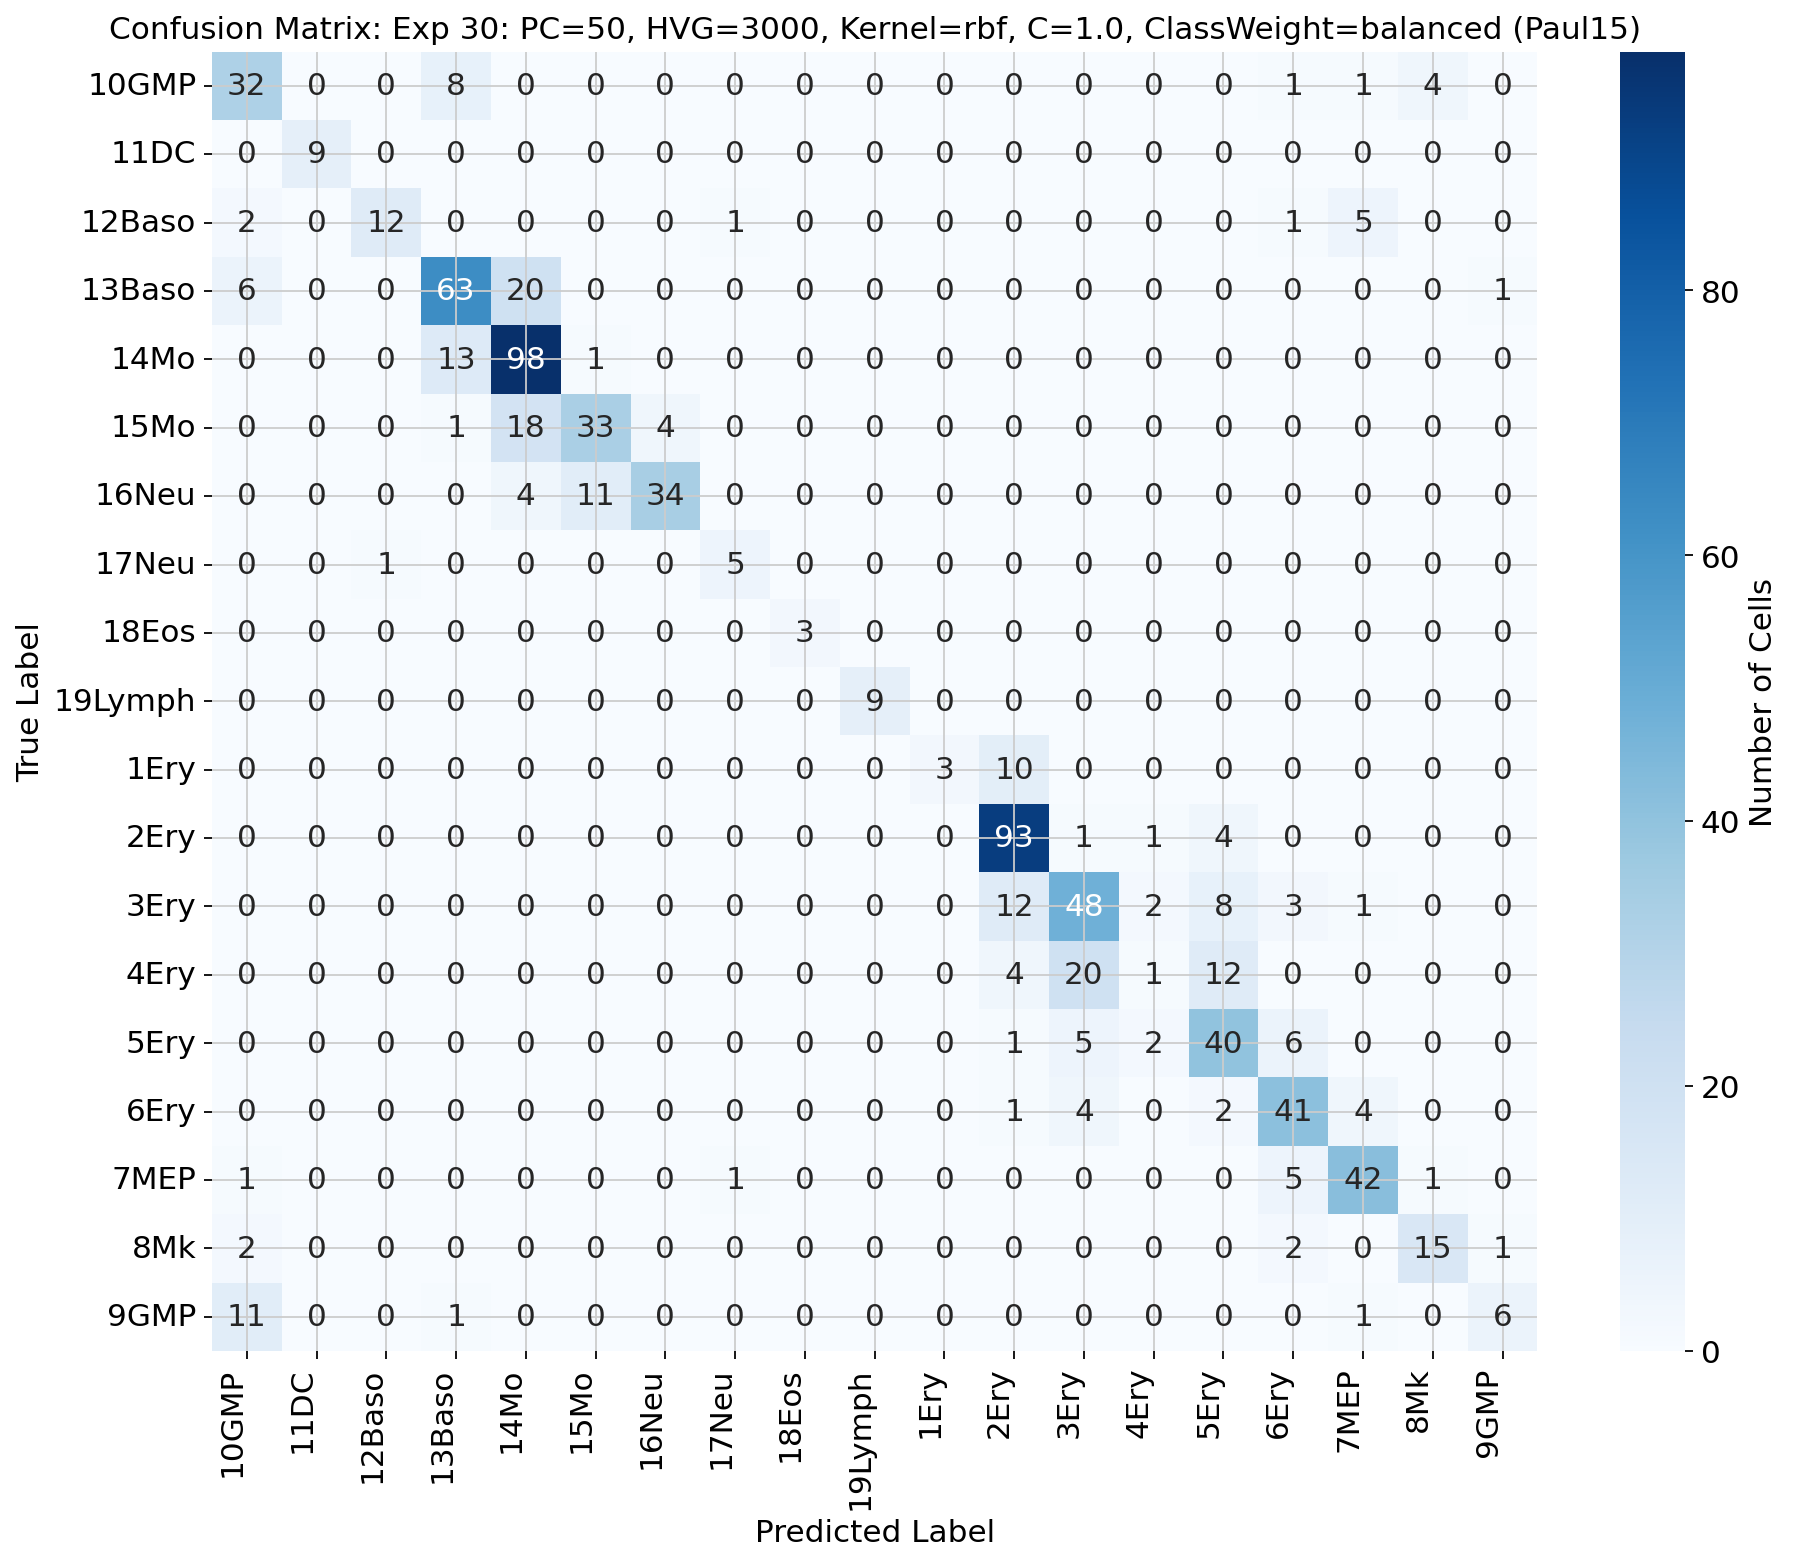


Starting Exp 31: PC=50, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=None

  RUNNING EXPERIMENT: Exp 31: PC=50, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=None
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial prep

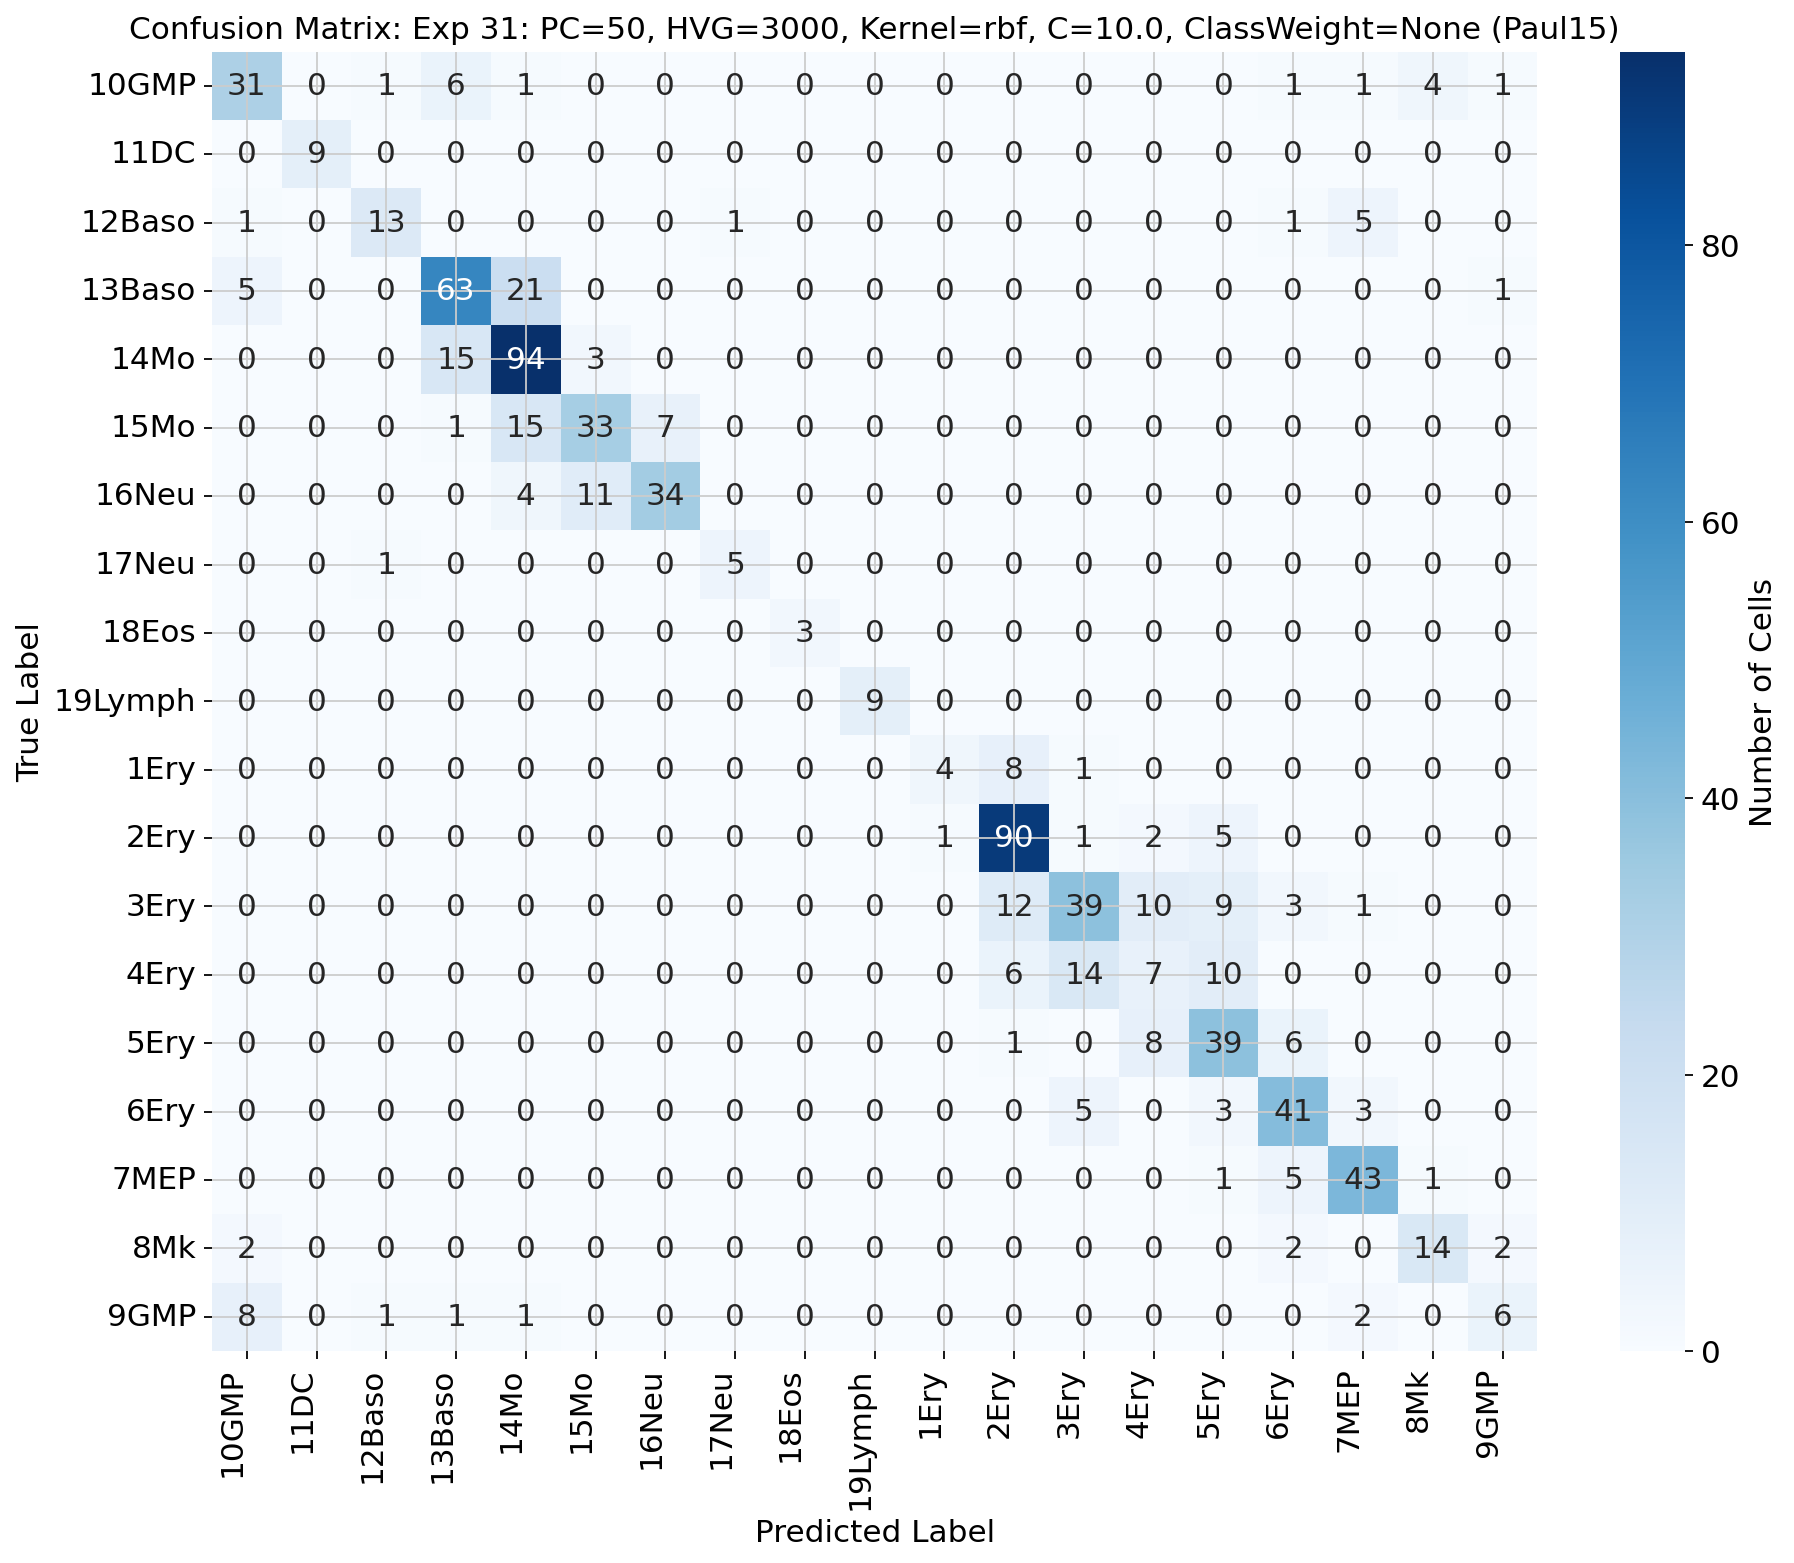


Starting Exp 32: PC=50, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=balanced

  RUNNING EXPERIMENT: Exp 32: PC=50, HVG=3000, Kernel=rbf, C=10.0, ClassWeight=balanced
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 50 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='balanced'...
Training finished.
--- ScPred Training Complete ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying 

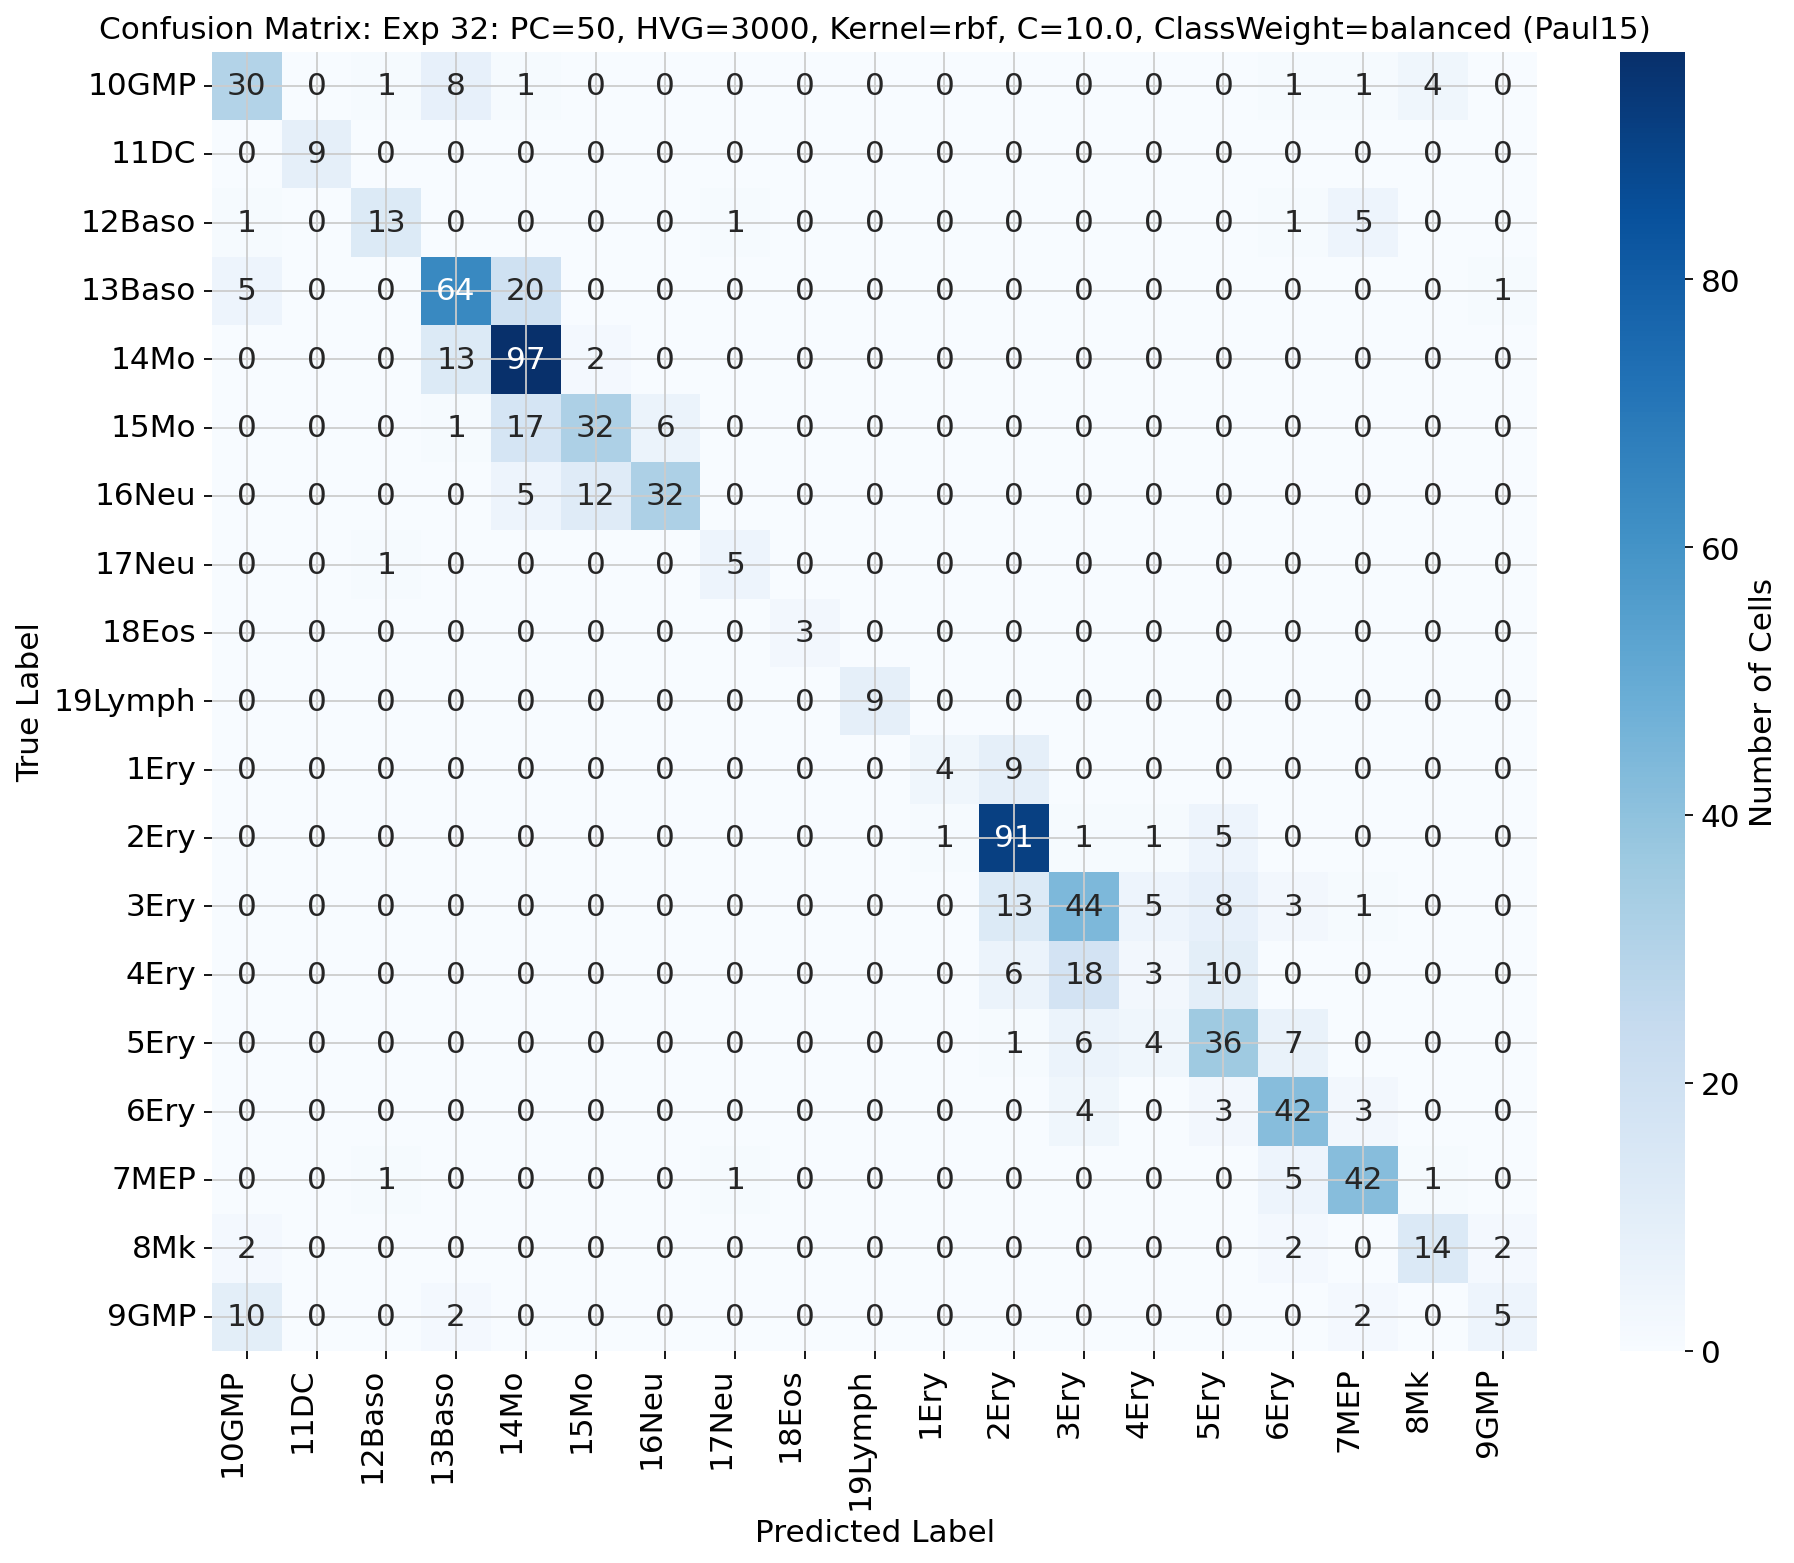

In [5]:
# --- 4. Run Comparative Experiments (Minimal Grid Search for Paul15) ---
print("\n\n--- Step 4: Running Comparative Analyses on paul15 (Minimal Grid) ---")

# Define a minimal parameter grid for Paul15, considering its complexity
# Paul15 often benefits from more PCs/HVGs due to more cell types.
param_grid = {
    'n_components': [30, 50], # Increased max PC value for Paul15
    'hvg_n_top_genes': [2000, 3000], # Increased max HVG for Paul15
    'svm_kernel': ['linear', 'rbf'], 
    'svm_c': [1.0, 10.0],
    'svm_class_weight': [None, 'balanced']
}

experiment_counter = 0
results_list_paul15 = []

# Iterate over all combinations of parameters
for n_comp, hvg_n, kernel, c_val, class_weight in product(
    param_grid['n_components'],
    param_grid['hvg_n_top_genes'],
    param_grid['svm_kernel'],
    param_grid['svm_c'],
    param_grid['svm_class_weight']
):
    experiment_counter += 1
    exp_name = (f"Exp {experiment_counter}: PC={n_comp}, HVG={hvg_n}, "
                f"Kernel={kernel}, C={c_val}, ClassWeight={class_weight}")
    
    svm_specific_params = {
        'svm_kernel': kernel, 
        'svm_c': c_val, 
        'svm_random_state': RANDOM_STATE, 
        'svm_class_weight': class_weight
    }

    print(f"\nStarting {exp_name}")
    try:
        result = run_scpred_experiment(
            experiment_name=exp_name, 
            ref_data=ref_adata_raw.copy(), 
            query_data=query_adata_raw.copy(), 
            n_components=n_comp, 
            hvg_n_top_genes=hvg_n, 
            hvg_flavor='seurat',
            svm_params=svm_specific_params,
            prediction_threshold=0.0 # This notebook is for no-threshold analysis
        )
        results_list_paul15.append(result)
    except Exception as e:
        print(f"!!! Error running experiment {exp_name}: {e}")
        print("Skipping this combination and continuing...")


In [6]:
# --- 5. Summarize Results ---
print("\n\n" + "="*50)
print("  FINAL RESULTS SUMMARY (paul15)")
print("="*50)

if results_list_paul15:
    results_df_paul15 = pd.DataFrame(results_list_paul15)
    if 'Balanced Accuracy' in results_df_paul15.columns:
        results_df_paul15_sorted = results_df_paul15.sort_values(by='Balanced Accuracy', ascending=False)
        print("\nTop 10 Experiments by Balanced Accuracy:")
        print(results_df_paul15_sorted.head(10).to_markdown(index=False)) # Display all if < 10, or adjust .head()
    else:
        print("No 'Balanced Accuracy' column found in results. Displaying all results.")
        print(results_df_paul15.to_markdown(index=False))
else:
    print("No successful experiments to summarize.")

print("\n--- Analysis Complete ---")




  FINAL RESULTS SUMMARY (paul15)

Top 10 Experiments by Balanced Accuracy:
| Experiment                                                        |   n_components |   hvg_n_top_genes | hvg_flavor   | svm_kernel   |   svm_c | svm_class_weight   |   Overall Accuracy |   Balanced Accuracy |      MCC | ROC AUC Scores                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
|:------------------------------------------------------------------|---------------:|------------------:|:-------------|:-------------|--------:|:-------------------|-------------------:|---------------